# <font color="steelblue">Métodos de boosting</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 08/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

## <font color="steelblue">Configuración del cuaderno</font>

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost catboost
!pip install shap
!pip install imbalanced-learn
!pip install mlxtend --upgrade --no-deps

import numpy as np
import pandas as pd
import math, random, time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *      # split_sample, preprocesar_datos
from auto_ML import *          # reports_clas, matriz_confusion, validar_modelo, curva_aprendizaje

# Modelos de boosting
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.datasets import make_moons, make_classification
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             accuracy_score, f1_score, balanced_accuracy_score, recall_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from scipy.special import expit          # función logística (sigmoide)
import shap
RNG = 123

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4


# <font color="steelblue">Introducción</font>

Los **modelos de conjunto** (*ensemble*) parten de una idea tan sencilla como poderosa: en lugar de confiar la predicción a un único modelo, combinan las decisiones de **muchos modelos simples** para obtener uno cuyo rendimiento supera al de cualquiera de ellos por separado. Es la traslación al aprendizaje automático de la conocida «sabiduría de la multitud»: agregada de forma adecuada, la opinión de muchos suele ser más certera y robusta que la de un único experto. Dentro de esta estrategia general conviven dos grandes familias, que se distinguen tanto por la forma en que entrenan los modelos como por el tipo de error que persiguen reducir.

La primera es el ***bagging***, objeto del cuaderno dedicado a los bosques aleatorios. En ella, los modelos se entrenan **en paralelo y de manera independiente**, cada uno sobre una muestra *bootstrap* distinta de los datos, y sus predicciones se **promedian**. Su propósito es **reducir la varianza** de modelos que, siendo individualmente inestables —como los árboles profundos—, se vuelven mucho más estables al agregarse.

La segunda familia es el ***boosting***, que abordamos en este cuaderno y que adopta una filosofía radicalmente distinta. Aquí los modelos se entrenan **en secuencia**, de modo que **cada uno se construye para corregir los errores cometidos por los anteriores**. Su objetivo no es tanto reducir la varianza como reducir el **sesgo**, edificando un modelo **fuerte** (*strong learner*) a partir de la combinación de numerosos modelos **débiles** (*weak learners*), habitualmente árboles poco profundos que, por sí solos, apenas superarían al azar.

La intuición que subyace al boosting es la de ir «dando un empujón» sucesivo al modelo. Se comienza con un modelo débil, se examinan sus errores y se añade un nuevo modelo que se concentra precisamente en **aquello que el anterior resolvió mal**; repitiendo este proceso, cada incorporación mejora un poco más el conjunto. El modelo final es, en consecuencia, una **suma ponderada** de los modelos débiles construidos a lo largo de las iteraciones:

$$G_M(x)=\sum_{m=1}^{M}\alpha_m\,g_m(x),$$

donde cada $g_m$ es un modelo débil y $\alpha_m$ el peso con que contribuye al resultado.

Este modo de proceder tiene consecuencias que conviene tener presentes desde el inicio. A diferencia del bagging, el boosting **no es paralelizable** entre iteraciones, ya que cada modelo necesita conocer los errores del precedente para poder entrenarse. A cambio, cuando se ajusta con cuidado, suele proporcionar predicciones **algo más precisas**; sin embargo, esa mayor capacidad lo hace también **más propenso al sobreajuste** y le exige controlar **un número mayor de hiperparámetros**, por lo que su puesta a punto resulta más delicada.

A lo largo de este cuaderno desarrollamos la **teoría matemática** de los principales algoritmos de boosting empleados en clasificación, acompañando cada uno de un **ejemplo sencillo** que ilustra su funcionamiento, y los aplicamos después a tres problemas reales —**cáncer de mama, abulones y potabilidad del agua**—. En todas las aplicaciones incorporamos, además, el análisis de **explicabilidad mediante valores de Shapley (SHAP)**, en coherencia con el enfoque adoptado en los cuadernos anteriores.

# <font color="steelblue">1. El descenso de gradiente</font>

Antes de abordar los algoritmos de boosting propiamente dichos, es necesario detenerse en la herramienta de optimización sobre la que casi todos ellos se sustentan: el **descenso de gradiente**. Se trata de un método general para **minimizar una función de pérdida** (o coste) $L(\theta)$, es decir, una función que cuantifica lo mal que un modelo, gobernado por unos parámetros $\theta$, se ajusta a los datos. Entrenar un modelo consiste, en esencia, en encontrar los valores de $\theta$ que hacen esa pérdida lo más pequeña posible; el descenso de gradiente es el procedimiento que permite lograrlo de forma sistemática.

## <font color="steelblue">1.1. Idea general</font>

Conviene imaginar la función de pérdida como una **superficie con valles y montañas** situada sobre el espacio de los parámetros: cada punto de esa superficie representa una configuración posible del modelo, y su altura, el error asociado. Minimizar la pérdida equivale, entonces, a **descender hasta el fondo de un valle**.

La brújula que indica hacia dónde movernos es el **gradiente**. Dado un valor del parámetro $\theta$, el gradiente $\nabla L(\theta)$ —el vector formado por las derivadas parciales de la pérdida— apunta en la dirección de **máximo crecimiento** de la función; por consiguiente, para **minimizar** debemos avanzar en la **dirección opuesta**, la de máxima pendiente de bajada. Sobre esta observación se construye un algoritmo iterativo:

1. Partir de un valor inicial $\theta_0$.
2. Calcular el gradiente en el punto actual, $\nabla L(\theta_t)$.
3. Actualizar el parámetro dando un paso en sentido contrario al gradiente, cuya longitud se regula mediante la **tasa de aprendizaje** $\lambda>0$:
$$\theta_{t+1} = \theta_t - \lambda\,\nabla L(\theta_t).$$
4. Repetir el proceso hasta que las actualizaciones apenas modifiquen el parámetro, momento en que se aplica el **criterio de parada**.

El papel de la tasa de aprendizaje $\lambda$ es determinante, pues fija el **tamaño del paso**. Si es demasiado grande, el algoritmo puede sobrepasar el mínimo una y otra vez, **oscilando** en torno a él o incluso **divergiendo**; si es demasiado pequeña, el descenso será correcto pero **extremadamente lento**. Conviene además tener presente una limitación de fondo: el método solo garantiza alcanzar **mínimos locales**, de manera que, cuando la función de pérdida no es convexa, puede quedar atrapado en un valle relativo sin llegar al mínimo global.

## <font color="steelblue">1.2. La función de coste como suma sobre los datos</font>

En el contexto del aprendizaje supervisado, la función de pérdida tiene una forma particular: se calcula como la **media de una pérdida individual** $\ell$ —el error cometido en una sola observación— sobre las $N$ observaciones del conjunto de entrenamiento:

$$L(\theta) = \frac{1}{N}\sum_{i=1}^{N}\ell\big(y_i,\, f_\theta(x_i)\big).$$

Puesto que la derivada de una suma es la suma de las derivadas, el gradiente hereda esa misma estructura y se expresa igualmente como una **media de gradientes individuales**, uno por observación:

$$\nabla L(\theta) = \frac{1}{N}\sum_{i=1}^{N}\nabla_\theta\,\ell\big(y_i, f_\theta(x_i)\big).$$

Esta expresión encierra una consecuencia práctica de la mayor importancia: el **coste de calcular el gradiente crece con el número de observaciones $N$**, ya que exige recorrer todo el conjunto de datos. Con volúmenes de datos grandes, evaluar esa suma completa en cada iteración puede resultar prohibitivo. De la forma en que se decida **aproximar** dicha suma en cada paso surgen las **tres variantes** del descenso de gradiente que se describen a continuación, que se diferencian esencialmente en **cuántas observaciones** utilizan para estimar el gradiente.

## <font color="steelblue">1.3. Descenso de gradiente por lotes (*batch*)</font>

La primera variante, el descenso **por lotes**, es la más fiel a la definición: emplea **todas** las $N$ observaciones en **cada** iteración para calcular el gradiente exacto,

$$\theta_{t+1} = \theta_t - \lambda\,\frac{1}{N}\sum_{i=1}^{N}\nabla_\theta\,\ell\big(y_i, f_\theta(x_i)\big).$$

Su principal **ventaja** es que, al basarse en el gradiente exacto, la trayectoria de descenso es **suave y estable** y converge de manera fiable hacia el mínimo. Su **inconveniente**, sin embargo, es que cada paso recorre la totalidad del conjunto de datos, lo que lo vuelve **lento y costoso en memoria** cuando el volumen de datos es elevado.

> *Analogía:* planificar cada paso de la bajada al valle estudiando **todo el mapa** antes de moverse: muy preciso, pero lentísimo.

## <font color="steelblue">1.4. Descenso de gradiente estocástico (*SGD*)</font>

En el extremo opuesto se sitúa el descenso **estocástico**, que en cada iteración utiliza **una única observación** $(x_i, y_i)$ elegida al azar:

$$\theta_{t+1} = \theta_t - \lambda\,\nabla_\theta\,\ell\big(y_i, f_\theta(x_i)\big),\qquad i\ \text{aleatorio}.$$

El gradiente calculado a partir de una sola observación constituye un **estimador ruidoso**, aunque **insesgado**, del gradiente verdadero: no coincide con él en cada paso, pero acierta en promedio. Su **ventaja** es que cada iteración resulta **muy barata**, lo que permite avanzar con gran rapidez; además, el ruido introducido puede ayudar a **escapar de mínimos locales**, motivo por el cual es especialmente adecuado para conjuntos de datos enormes. Su **inconveniente** es que la trayectoria se vuelve **errática** y la pérdida **oscila** notablemente en lugar de descender de forma monótona, de modo que al algoritmo le cuesta **converger con precisión** al mínimo, en cuyo entorno tiende a fluctuar.

> *Analogía:* bajar la montaña con una linterna que solo ilumina un metro: no ves todo el terreno, pero avanzas rápido a pasos pequeños y algo titubeantes.

## <font color="steelblue">1.5. Descenso de gradiente por mini-lotes (*mini-batch*)</font>

Entre ambos extremos se encuentra el descenso por **mini-lotes**, que constituye el punto intermedio y la opción más empleada en la práctica. En lugar de usar una sola observación o todas ellas, divide el conjunto de entrenamiento en pequeños **lotes** $B_t$ de tamaño $n_b$ —habitualmente 32, 64 o 128 observaciones— y estima el gradiente, en cada paso, a partir de uno de esos lotes:

$$\theta_{t+1} = \theta_t - \lambda\,\frac{1}{n_b}\sum_{j\in B_t}\nabla_\theta\,\ell\big(y_j, f_\theta(x_j)\big).$$

De este modo, combina lo mejor de las dos variantes anteriores: al promediar varios gradientes gana en **estabilidad** —el ruido es menor que en el descenso estocástico— y, al no recorrer todos los datos en cada paso, conserva buena parte de su **velocidad**. A ello se añade una ventaja computacional: el procesamiento de cada lote es **paralelizable**, razón por la cual esta variante se ha convertido en el estándar del entrenamiento de las redes neuronales profundas.

> *Analogía:* bajar la montaña con un **grupo de amigos**, cada uno con su linterna, decidiendo el siguiente paso por consenso: rápido y razonablemente seguro.

En este contexto se emplea con frecuencia un término que conviene fijar: una pasada completa por todos los lotes, hasta haber utilizado la totalidad de los datos una vez, se denomina **época** (*epoch*).













## <font color="steelblue">1.6. Del gradiente al boosting</font>

Llegados a este punto, cabe preguntarse qué relación guarda todo lo anterior con el boosting, y la respuesta encierra la idea central de este cuaderno. El boosting no es sino la aplicación del descenso de gradiente, pero llevado a un terreno distinto: en lugar de ajustar un vector de parámetros numéricos, opera **en el espacio de las funciones**. Bajo esta óptica, los «parámetros» que se van ajustando son los propios **modelos débiles** $g_m$; el papel del «gradiente» lo desempeñan los **residuos** —el gradiente negativo de la pérdida del modelo acumulado hasta ese momento—, que señalan las observaciones en las que el conjunto aún yerra; y la tasa de aprendizaje se traduce en el **peso** con que cada nuevo modelo se incorpora. La actualización adopta así la forma

$$G_m(x)=G_{m-1}(x)+\alpha_m\,g_m(x),$$

en la que cada modelo débil $g_m$ **apunta hacia donde el conjunto todavía se equivoca**, del mismo modo que, en el descenso clásico, cada paso se dirigía hacia donde la pérdida podía reducirse. Esta correspondencia entre parámetros y funciones se resume en la siguiente tabla:

| Descenso de gradiente clásico | Boosting (en el espacio de funciones) |
|---|---|
| Parámetro $\theta$ | Modelo acumulado $G_m$ |
| Gradiente $\nabla L(\theta)$ | Residuos (gradiente negativo de la pérdida) |
| Tasa de aprendizaje $\lambda$ | Peso $\alpha_m$ de cada modelo débil |
| Paso $\theta_{t+1}=\theta_t-\lambda\nabla L$ | $G_m = G_{m-1} + \alpha_m\,g_m$ |

La distinción entre las tres variantes estudiadas reaparece también en los algoritmos de boosting, según cuántos datos empleen para calcular los residuos en cada iteración. La mayoría de ellos —**AdaBoost**, **Gradient Boosting**, **XGBoost** o **LightGBM**— operan **por lotes**, es decir, calculan los residuos o gradientes utilizando **todo** el conjunto de entrenamiento en cada paso. Frente a ellos, el ***Stochastic Gradient Boosting*** ajusta cada árbol sobre una **submuestra aleatoria** de los datos (controlada por el parámetro `subsample`<1), y el muestreo **GOSS** de LightGBM constituye igualmente una forma de submuestreo, en este caso selectivo; ambos recogen la filosofía **estocástica** y de **mini-lotes**, con la que reducen la varianza, aceleran el entrenamiento y permiten, además, estimar el error *out-of-bag*.

# <font color="steelblue">2. Algoritmos de boosting</font>

Revisamos los algoritmos de boosting más usados para clasificación, con su **formulación matemática**, sus **hiperparámetros** y un **ejemplo sencillo** que los ilustra. Para los ejemplos usamos un conjunto de juguete en 2D (dos lunas solapadas).

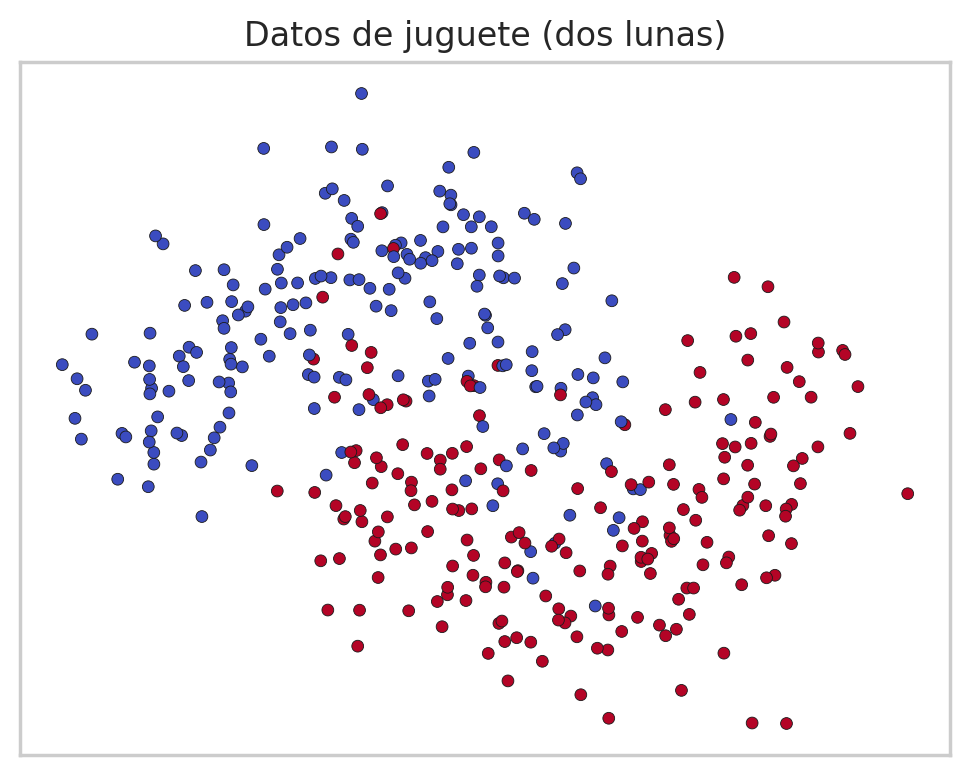

In [2]:
Xj, yj = make_moons(n_samples=400, noise=0.30, random_state=0)
Xj_tr, Xj_te, yj_tr, yj_te = train_test_split(Xj, yj, test_size=0.3, random_state=42)
plt.figure(figsize=(6, 4.5))
plt.scatter(Xj[:, 0], Xj[:, 1], c=yj, cmap='coolwarm', s=18, edgecolor='k', linewidth=.3)
plt.title('Datos de juguete (dos lunas)'); plt.xticks([]); plt.yticks([]); plt.show()

## <font color="steelblue">2.1. AdaBoost (*Adaptive Boosting*)</font>

AdaBoost fue el **primer** algoritmo de boosting que alcanzó difusión, y sigue siendo el más adecuado para introducir la idea, pues materializa de la forma más transparente el principio de «corregir lo que el modelo anterior hizo mal». Su mecanismo se resume en una intuición sencilla: en cada ronda se **reponderan las observaciones**, otorgando más importancia a aquellas que han sido mal clasificadas hasta el momento, de modo que el siguiente modelo débil se vea **obligado a concentrarse en los casos difíciles**. El calificativo *adaptive* alude precisamente a esa capacidad de ir **adaptando** el foco de atención sobre los datos a lo largo de las iteraciones.

Aunque el algoritmo se formuló originalmente de manera heurística, más tarde se demostró que equivale a un **modelo aditivo por etapas** (*forward stagewise additive modeling*): un modelo que se construye **sumando términos uno a uno**, sin retocar los ya incorporados, y que en cada etapa añade el que más reduce una determinada pérdida. En el caso de AdaBoost, esa función es la **pérdida exponencial**,

$$L(y, G) = \sum_{i=1}^{N} \exp\!\big(-y_i\,G(x_i)\big),\qquad y_i\in\{-1,+1\}.$$

Merece la pena detenerse en su significado. El producto $y_i\,G(x_i)$, conocido como **margen**, es positivo cuando la predicción y la etiqueta real coinciden en signo (acierto) y negativo cuando discrepan (error). Al estar el margen dentro de una exponencial con signo negativo, la pérdida **penaliza de forma muy severa los errores** —crece exponencialmente cuanto más equivocada y segura es una predicción— y recompensa los aciertos. Minimizarla equivale, por tanto, a empujar al modelo a clasificar correctamente y con holgura el mayor número posible de observaciones.

**Algoritmo (clasificación binaria con clases $\pm 1$):**

1. Inicializar los pesos de las $N$ observaciones de forma **uniforme**, $\;w_i^{(1)} = \tfrac{1}{N}$, de manera que en la primera ronda todas cuenten por igual.
2. Para $m = 1,\dots,M$:
   * Entrenar un modelo débil $g_m$ (habitualmente un *stump*, un árbol de una sola división) **teniendo en cuenta los pesos** $w_i^{(m)}$, de modo que se esfuerce especialmente en las observaciones más ponderadas.
   * Calcular su **error ponderado**, es decir, la proporción de peso que recae sobre las observaciones mal clasificadas:
   $$err_m=\frac{\sum_{i} w_i^{(m)}\,\mathbb{1}(y_i\neq g_m(x_i))}{\sum_{i} w_i^{(m)}}.$$
   * Determinar el **peso del propio modelo** —la fuerza de su voto en la decisión final—:
   $$\alpha_m=\lambda\,\log\!\frac{1-err_m}{err_m}.$$
   La lógica de esta fórmula es la que cabría esperar: un modelo con **error pequeño** obtiene un $\alpha_m$ **grande** y, por tanto, mucha influencia, mientras que un modelo apenas mejor que el azar ($err_m\approx 0{,}5$) recibe un peso próximo a cero. Así, cada modelo débil **vota en proporción a su acierto**.
   * **Actualizar los pesos** de las observaciones de cara a la siguiente ronda:
   $$w_i^{(m+1)} = w_i^{(m)}\,\exp\!\big(-\alpha_m\,y_i\,g_m(x_i)\big),$$
   y **normalizarlos** después para que vuelvan a sumar 1. El término $y_i\,g_m(x_i)$ vale $+1$ en los aciertos y $-1$ en los errores, de manera que esta actualización **aumenta** el peso de las observaciones **mal clasificadas** y **reduce** el de las bien clasificadas. Es el corazón del método: la ronda siguiente heredará un problema en el que los casos difíciles pesan más.
3. Construir el **modelo final** como un **voto ponderado** de todos los modelos débiles, y predecir según el **signo** del resultado:
$$G_M(x)=\sum_{m=1}^{M}\alpha_m\,g_m(x),\qquad \hat y = \operatorname{sign}\big(G_M(x)\big).$$
Cada modelo contribuye con su predicción, ponderada por el peso $\alpha_m$ que se ganó según su acierto, y la clase final es aquella hacia la que se inclina la suma.

Este planteamiento se formula para **dos clases**. Cuando el problema tiene **más de dos**, scikit-learn recurre a la variante **SAMME**, que generaliza el cálculo de $\alpha_m$ incorporando un término $\log(K-1)$ (con $K$ el número de clases), así como a su versión probabilística **SAMME.R**, que emplea las probabilidades estimadas en lugar de las clasificaciones «duras» y suele converger en menos iteraciones.

**Hiperparámetros principales (`AdaBoostClassifier`).** El comportamiento del algoritmo se gobierna, fundamentalmente, mediante cuatro parámetros:

* **`n_estimators`** *(int, def. 50)* — el número $M$ de modelos débiles que se encadenan. Un valor mayor incrementa la **capacidad** del conjunto, pero también el **riesgo de sobreajuste**, especialmente cuando los datos contienen mucho ruido, pues AdaBoost tiende a insistir sobre observaciones difíciles que en realidad pueden ser atípicas.
* **`learning_rate`** *(float, def. 1.0)* — el factor $\lambda$ que **atenúa** la contribución $\alpha_m$ de cada modelo. Valores bajos hacen que el aprendizaje sea más **lento pero más robusto**, y existe una **compensación** con `n_estimators`: reducir la tasa de aprendizaje obliga, por lo general, a aumentar el número de estimadores para alcanzar un rendimiento equivalente.
* **`estimator`** *(por defecto, un árbol de profundidad 1, es decir, un *stump*)* — el modelo base que se emplea como aprendiz débil. Es posible aumentar su profundidad, pero al hacerlo deja de ser «débil» y se pierde parte de la filosofía del boosting.
* **`algorithm`** — permite elegir entre `'SAMME'` (versión discreta, basada en las clases predichas) y `'SAMME.R'` (versión real, que utiliza probabilidades y suele converger antes).

**Ejemplo sencillo.** Para observar cómo el conjunto va mejorando a medida que incorpora modelos débiles, utilizaremos el método `staged_predict`, que permite recuperar la predicción del conjunto en cada etapa intermedia. Con él representaremos la evolución de la exactitud, tanto en entrenamiento como en test, **conforme se añaden estimadores**, lo que ilustra el efecto acumulativo del boosting y ayuda a apreciar en qué momento aparecen los primeros síntomas de sobreajuste.

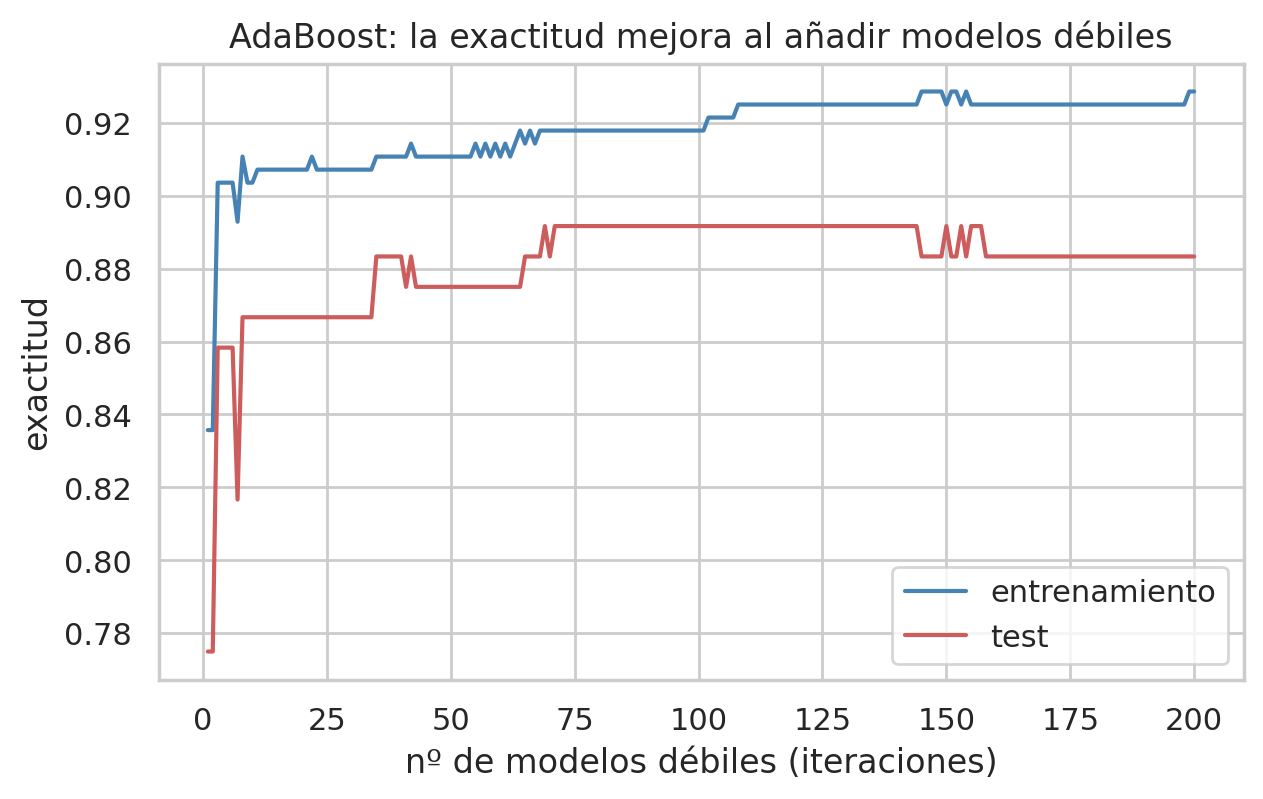

In [3]:
ada = AdaBoostClassifier(n_estimators=200, random_state=RNG).fit(Xj_tr, yj_tr)
acc_tr = [accuracy_score(yj_tr, p) for p in ada.staged_predict(Xj_tr)]
acc_te = [accuracy_score(yj_te, p) for p in ada.staged_predict(Xj_te)]
plt.figure(figsize=(7, 4))
plt.plot(range(1, 201), acc_tr, label='entrenamiento', color='steelblue')
plt.plot(range(1, 201), acc_te, label='test', color='indianred')
plt.xlabel('nº de modelos débiles (iteraciones)'); plt.ylabel('exactitud')
plt.title('AdaBoost: la exactitud mejora al añadir modelos débiles'); plt.legend(); plt.show()

Con **un solo** modelo débil la exactitud es baja, pero **cada nuevo modelo corrige** parte de los errores del conjunto y la exactitud **sube rápidamente** hasta estabilizarse. Es la esencia del boosting: muchos modelos débiles → uno fuerte.

## <font color="steelblue">2.2. Gradient Boosting</font>

El *Gradient Boosting* (potenciación del gradiente) **generaliza** la idea de AdaBoost y la dota de un fundamento más general y flexible. En lugar de reponderar las observaciones, reinterpreta la construcción del modelo como un **descenso de gradiente aplicado sobre una función de pérdida** $L$ **derivable** —en clasificación, la **log-loss** o *deviance*, que penaliza las probabilidades asignadas con seguridad a la clase equivocada—. Con ello, el mecanismo de «corregir los errores del anterior» deja de estar ligado a un esquema de pesos y pasa a apoyarse directamente en el cálculo diferencial, lo que permite emplear una amplia variedad de funciones de pérdida y abordar tanto la clasificación como la regresión bajo un mismo marco.

La estrategia de construcción sigue siendo **aditiva y por etapas**, idéntica en espíritu a la de AdaBoost: el modelo se edifica sumando términos uno a uno,

$$G_m(x)=G_{m-1}(x)+\nu\,g_m(x),$$

donde $g_m$ es el árbol incorporado en la etapa $m$ y $\nu$ la **tasa de aprendizaje**, que regula cuánto se avanza en cada paso. La diferencia esencial, como veremos, reside en **cómo se decide qué debe aprender cada nuevo árbol**.

**Algoritmo (boosting de gradiente):**

1. Inicializar el modelo con una **predicción constante**, la que minimiza la pérdida global sin usar todavía ninguna variable:
$$G_0(x)=\arg\min_c \sum_i L(y_i, c),$$
que en el caso binario coincide con la *log-odds* de la proporción de positivos, es decir, el mejor punto de partida «a ciegas».
2. Para $m=1,\dots,M$:
   * Calcular los **pseudo-residuos**, definidos como el **gradiente negativo** de la pérdida respecto a la predicción actual:
$$r_{im} = -\left[\frac{\partial L\big(y_i, G(x_i)\big)}{\partial G(x_i)}\right]_{G=G_{m-1}}.$$
   Este vector indica, para cada observación, **en qué dirección y con qué intensidad** conviene modificar la predicción para reducir la pérdida; es, literalmente, la señal que marca «hacia dónde bajar». En la clasificación binaria con log-loss, donde $G$ representa la *log-odds* y $p_i=\sigma(G(x_i))$ es la probabilidad predicha, este residuo adopta una forma notablemente simple e interpretable,
$$r_{im}=y_i-p_i,$$
esto es, la **diferencia entre lo observado y lo predicho**: será grande allí donde el modelo se equivoca con seguridad y próximo a cero donde ya acierta.
   * **Ajustar un árbol** $g_m$ que aprenda a **predecir esos pseudo-residuos**. De este modo, el árbol no intenta clasificar directamente, sino **modelar el error del conjunto**: aprende dónde y cuánto falla la predicción acumulada.
   * Determinar el **valor óptimo de cada hoja** $j$ del árbol mediante una minimización de la pérdida (un paso de *line search* que ajusta la magnitud exacta de la corrección):
$$\gamma_{jm}=\arg\min_\gamma \sum_{x_i\in R_{jm}} L\big(y_i, G_{m-1}(x_i)+\gamma\big).$$
   * **Actualizar** el modelo incorporando el nuevo árbol, atenuado por la tasa de aprendizaje:
$$G_m(x)=G_{m-1}(x)+\nu\sum_j \gamma_{jm}\,\mathbb{1}(x\in R_{jm}).$$
3. Obtener la predicción final aplicando sobre $G_M(x)$ la **función logística** (en el caso binario) o la **softmax** (en el multiclase), que transforman la puntuación acumulada en probabilidades.

Esta reformulación revela con claridad la diferencia de fondo con AdaBoost. Aquel solo disponía de una información binaria —**si** cada observación se había clasificado bien o mal— y reaccionaba subiendo el peso de los errores; el *Gradient Boosting*, en cambio, utiliza las **derivadas** de la pérdida para conocer **cuánto y en qué dirección** debe corregirse cada predicción, lo que constituye una guía mucho más rica y precisa. Sobre esta base se define además la variante **Stochastic Gradient Boosting**, que ajusta cada árbol empleando únicamente una **submuestra aleatoria** de los datos (parámetro `subsample`<1); con ello introduce el componente **estocástico** o de **mini-lote** descrito al comienzo del capítulo, reduce la varianza del modelo y habilita una estimación del error de tipo *out-of-bag*.

**Hiperparámetros principales (`GradientBoostingClassifier`).** Su ajuste es más delicado que el de un bosque aleatorio, pues varios parámetros interactúan entre sí:

* **`n_estimators`** *(def. 100)* — el número de árboles o etapas del proceso. A diferencia del bagging, aumentarlo **sí puede conducir al sobreajuste**, ya que cada árbol se añade para reducir aún más el error de entrenamiento.
* **`learning_rate`** $\nu$ *(def. 0.1)* — el factor que **atenúa** la contribución de cada árbol. Mantiene una **compensación** intensa con `n_estimators`: una tasa de aprendizaje baja obliga a emplear más árboles, pero suele traducirse en una **mejor generalización**. Esta pareja de parámetros es la que más condiciona el rendimiento del modelo.
* **`max_depth`** *(def. 3)* — la profundidad de cada árbol, que determina la **complejidad** y el grado de **interacciones** entre variables que el modelo puede capturar. Se mantiene deliberadamente pequeña para que cada árbol siga siendo un aprendiz **débil**.
* **`subsample`** *(def. 1.0)* — la fracción de observaciones empleada en cada árbol; un valor inferior a 1 activa el **Stochastic Gradient Boosting**, con la consiguiente reducción de varianza.
* **`min_samples_leaf`** y **`max_features`** — regularizan, respectivamente, el tamaño mínimo de las hojas y la aleatoriedad en la selección de variables de cada árbol.
* **`loss`** — la función de pérdida, que para clasificación es `'log_loss'`.

**Ejemplo sencillo.** Para ilustrar el papel central de la tasa de aprendizaje, compararemos la evolución de la exactitud en test, iteración a iteración, para **dos valores distintos de `learning_rate`**, lo que permite apreciar el compromiso entre velocidad de aprendizaje y calidad de la generalización.

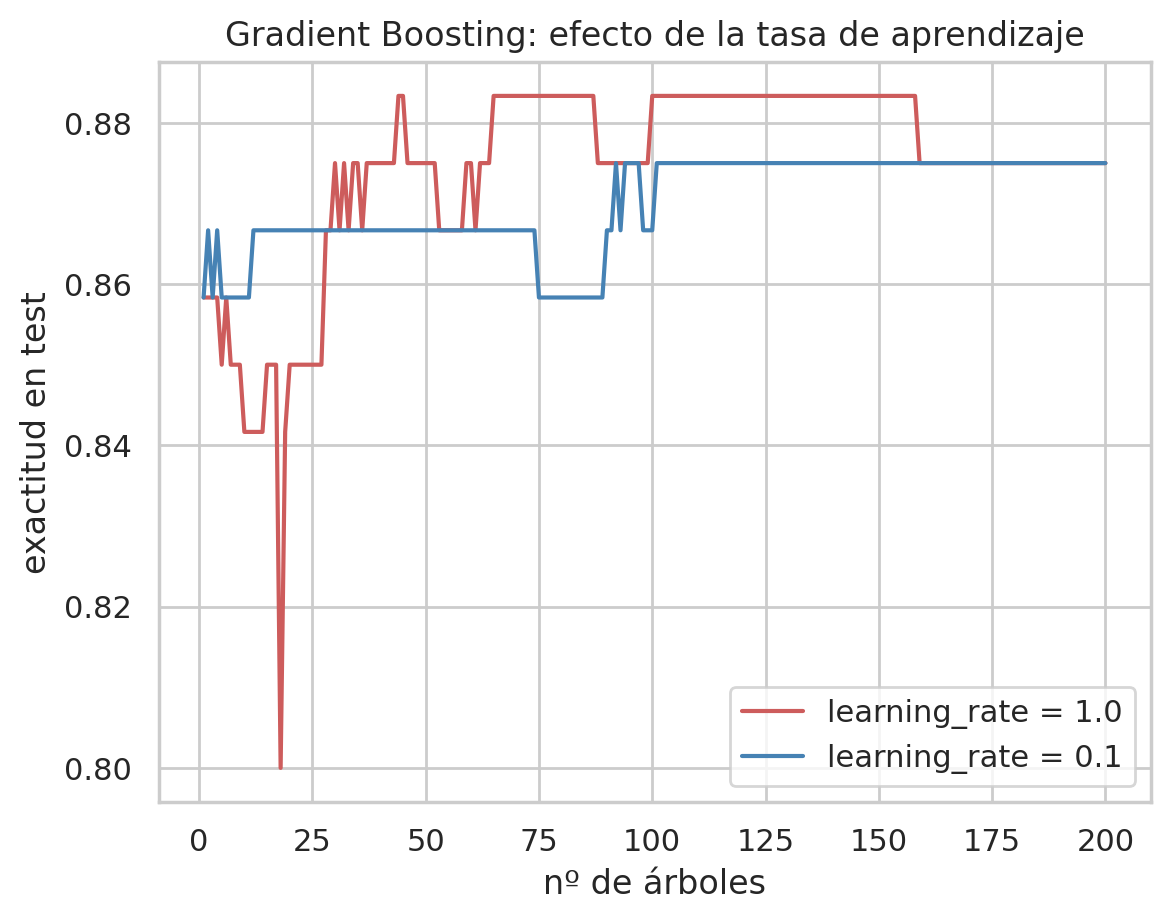

In [4]:
for lr, col in [(1.0, 'indianred'), (0.1, 'steelblue')]:
    gb = GradientBoostingClassifier(n_estimators=200, learning_rate=lr, max_depth=2,
                                    random_state=RNG).fit(Xj_tr, yj_tr)
    acc = [accuracy_score(yj_te, p) for p in gb.staged_predict(Xj_te)]
    plt.plot(range(1, 201), acc, label=f'learning_rate = {lr}', color=col)
plt.xlabel('nº de árboles'); plt.ylabel('exactitud en test')
plt.title('Gradient Boosting: efecto de la tasa de aprendizaje'); plt.legend(); plt.show()

Con tasa **alta** (roja) el modelo alcanza buena exactitud **enseguida** pero de forma más inestable; con tasa **baja** (azul) progresa **más despacio** y suave, generalizando mejor con suficientes árboles. Ajustar `learning_rate` y `n_estimators` **a la vez** es clave.

## <font color="steelblue">2.3. Histogram-based Gradient Boosting</font>

El `HistGradientBoostingClassifier` constituye la implementación **moderna y de alto rendimiento** del *Gradient Boosting* en scikit-learn, inspirada directamente en LightGBM. Conviene subrayar que **no altera la teoría** expuesta en el apartado anterior —sigue tratándose de un descenso de gradiente aditivo que construye árboles sobre los residuos—, sino que la **implementa de manera mucho más eficiente**. El *Gradient Boosting* clásico, en efecto, adolece de un problema de escalabilidad: hallar el mejor punto de corte de cada variable exige, en cada división, examinar todos sus valores posibles, lo que lo vuelve lento con conjuntos de datos grandes. Las optimizaciones que introduce esta variante van dirigidas precisamente a superar esa limitación, y son esencialmente tres.

La primera es la **discretización en histogramas**. Antes de comenzar el entrenamiento, los valores de cada variable continua se agrupan en un número reducido de intervalos o *bins* (controlado por `max_bins`, hasta un máximo de 255). Gracias a ello, la búsqueda del mejor punto de corte deja de recorrer todos los valores distintos de la variable y se limita a los **bordes de esos intervalos**, con lo que su coste se reduce de un orden $O(N)$ —proporcional al número de observaciones— a un orden $O(\text{n\_bins})$, mucho menor y **constante**. Aquí reside la principal fuente de su notable **velocidad**. Cabe preguntarse si esta simplificación no degrada la calidad del modelo; en la práctica, la pérdida de precisión es mínima, pues unos pocos cientos de intervalos bastan para localizar cortes prácticamente tan buenos como los exactos, y la ligera «rugosidad» que introduce actúa incluso como una suave **regularización**.

La segunda optimización es el uso de una **aproximación de segundo orden**, de tipo Newton. Mientras que el *Gradient Boosting* clásico se guía únicamente por el **gradiente** $g_i=\partial L/\partial G$ —la primera derivada de la pérdida, que indica la dirección de descenso—, esta implementación incorpora además la **segunda derivada** o **hessiano** $h_i=\partial^2 L/\partial G^2$, que mide la **curvatura** de la pérdida. Intuitivamente, conocer la curvatura permite calibrar mejor el tamaño del paso: en zonas donde la pérdida se curva bruscamente conviene avanzar con cautela, y donde es más plana, con mayor decisión. Esta información se emplea tanto para **evaluar la calidad de las divisiones** como para **fijar el valor óptimo de cada hoja**, lo que se traduce en una convergencia **más rápida y estable**. Es el mismo fundamento en que se apoyan XGBoost y LightGBM, que se describen más adelante.

La tercera característica es el **tratamiento nativo de los valores ausentes** (`NaN`). En lugar de exigir una imputación previa, el algoritmo aprende, en cada división, **hacia qué rama** —izquierda o derecha— resulta más conveniente enviar las observaciones cuyo valor se desconoce, decisión que toma de forma que se minimice la pérdida. De este modo, la ausencia de un dato pasa a tratarse como una información más que el modelo aprovecha, en vez de como un obstáculo que haya que resolver de antemano.

**Hiperparámetros principales (`HistGradientBoostingClassifier`).** Su configuración presenta algunas particularidades respecto al *Gradient Boosting* clásico, derivadas de que aquí el crecimiento de los árboles se rige por el número de hojas (*leaf-wise*) más que por la profundidad:

* **`learning_rate`** *(def. 0.1)* — la tasa de aprendizaje, con el mismo papel y la misma compensación con el número de iteraciones que en el apartado anterior.
* **`max_iter`** *(def. 100)* — el número de árboles o iteraciones; es el equivalente a `n_estimators` en esta implementación.
* **`max_leaf_nodes`** *(def. 31)* — el número máximo de hojas por árbol y el **principal mecanismo de control de la complejidad** del modelo, ya que estos árboles crecen priorizando las divisiones más provechosas (crecimiento *leaf-wise*) en lugar de expandirse nivel a nivel.
* **`max_depth`** *(def. None)* — la profundidad máxima, que actúa como alternativa o complemento del parámetro anterior.
* **`min_samples_leaf`** *(def. 20)* — el número mínimo de observaciones que debe contener cada hoja, con efecto **regularizador**.
* **`l2_regularization`** *(def. 0)* — una penalización de tipo **L2** aplicada sobre los valores de las hojas que, al desincentivar valores extremos, ayuda a **controlar el sobreajuste**.
* **`max_bins`** *(def. 255)* — el número de intervalos del histograma; aumentarlo mejora la precisión de los cortes a costa de un mayor tiempo de cómputo.
* **`early_stopping`** — un mecanismo de **parada temprana** que interrumpe el entrenamiento cuando una métrica evaluada sobre un conjunto de validación deja de mejorar, evitando así iteraciones inútiles y el sobreajuste.

**Ejemplo sencillo.** Para ilustrar la que quizá sea su característica más distintiva —la capacidad de **entrenar con valores ausentes sin necesidad de imputarlos**—, introduciremos deliberadamente valores `NaN` en los datos y ajustaremos el modelo directamente sobre ellos, comprobando que el proceso se desarrolla sin contratiempos.

In [5]:
Xj_nan = Xj_tr.copy()
rng = np.random.RandomState(0)
mask = rng.rand(*Xj_nan.shape) < 0.15          # 15% de valores puestos a NaN
Xj_nan[mask] = np.nan
print(f'Valores ausentes introducidos: {int(np.isnan(Xj_nan).sum())}')
hist_demo = HistGradientBoostingClassifier(random_state=RNG).fit(Xj_nan, yj_tr)   # ¡sin imputar!
print(f'Exactitud en test (entrenando con NaN): {accuracy_score(yj_te, hist_demo.predict(Xj_te)):.3f}')

Valores ausentes introducidos: 88
Exactitud en test (entrenando con NaN): 0.875


El modelo se entrena **sin error pese a los `NaN`**: internamente decide, en cada división, hacia qué rama mandar las observaciones con valor ausente. Los algoritmos clásicos (`AdaBoost`, `GradientBoosting`) **fallarían** con estos datos sin imputar previamente.

## <font color="steelblue">2.4. XGBoost (*Extreme Gradient Boosting*)</font>

`XGBoost` es una librería externa, ajena a scikit-learn, que implementa el *Gradient Boosting* de forma especialmente **optimizada y regularizada**, y que durante años ha sido el algoritmo de referencia en numerosas competiciones de ciencia de datos. Su contribución teórica más relevante consiste en replantear el problema que resuelve cada iteración: en lugar de limitarse a ajustar un árbol a los residuos, **minimiza una función objetivo que combina el ajuste a los datos con una penalización explícita de la complejidad del árbol**, y lo hace apoyándose en una aproximación **de segundo orden** de la pérdida. Ambas ideas —regularización y uso del hessiano— son las que explican tanto su precisión como su resistencia al sobreajuste.

En la iteración $m$, al incorporar el árbol $g_m$, XGBoost minimiza la siguiente función objetivo:

$$\text{Obj}^{(m)} = \sum_{i=1}^{N} L\big(y_i,\, G_{m-1}(x_i)+g_m(x_i)\big) \;+\; \Omega(g_m),\qquad \Omega(g)=\gamma\,T + \tfrac{1}{2}\lambda\sum_{j=1}^{T} w_j^2.$$

El primer sumando es la **pérdida** habitual, que mide el ajuste a los datos; la novedad reside en el segundo, el término de **regularización** $\Omega(g)$, que penaliza la complejidad del propio árbol. Este término tiene, a su vez, dos componentes con significados distintos: $\gamma\,T$ penaliza el **número de hojas** $T$ —desincentivando árboles innecesariamente frondosos—, mientras que $\tfrac{1}{2}\lambda\sum_j w_j^2$ es una penalización de tipo **L2** que castiga las hojas con **valores $w_j$ grandes**, evitando que el modelo confíe en exceso en correcciones extremas. Con ello, XGBoost incorpora la regularización **dentro** de la propia función que optimiza, en lugar de imponerla externamente mediante restricciones sobre el árbol.

Para minimizar ese objetivo de forma eficiente, XGBoost no trabaja con la pérdida exacta, sino con su **desarrollo de Taylor de segundo orden** en torno a la predicción actual $G_{m-1}$. Esta aproximación utiliza dos cantidades por observación: el **gradiente** $g_i=\partial_G L$, que como ya vimos indica la dirección de corrección, y el **hessiano** $h_i=\partial^2_G L$, que aporta la **curvatura** de la pérdida y permite dimensionar mejor cada paso. La ventaja de esta formulación es que convierte un problema de optimización complejo en uno **cuadrático**, que admite solución cerrada. De él se obtienen dos resultados de gran valor práctico: el **valor óptimo de cada hoja** y la **ganancia asociada a una posible división**,

$$w_j^{*}=-\frac{\sum_{i\in I_j} g_i}{\sum_{i\in I_j} h_i + \lambda},\qquad
\text{Gain}=\tfrac{1}{2}\!\left[\frac{(\sum_{L} g_i)^2}{\sum_{L} h_i+\lambda}+\frac{(\sum_{R} g_i)^2}{\sum_{R} h_i+\lambda}-\frac{(\sum g_i)^2}{\sum h_i+\lambda}\right]-\gamma.$$

La primera expresión indica cuál es el mejor valor que puede asignarse a una hoja en función de los gradientes y hessianos de las observaciones que caen en ella; obsérvese cómo el parámetro $\lambda$ aparece en el denominador **encogiendo** ese valor hacia cero, lo que constituye el efecto regularizador de la penalización L2. La segunda mide la **mejora** que aporta partir un nodo en dos ramas (izquierda $L$ y derecha $R$) frente a dejarlo sin dividir: los dos primeros términos representan la calidad de los nodos hijos y el tercero, la del nodo original. La consecuencia más elegante de esta fórmula es que el árbol **solo lleva a cabo una división cuando $\text{Gain}>0$**; como $\gamma$ se resta al final, actúa como un umbral que **poda automáticamente** las divisiones cuya mejora no compensa el coste de añadir una hoja. La regularización deja así de ser un añadido y pasa a formar parte del propio criterio de crecimiento del árbol.

A estas aportaciones teóricas, XGBoost suma una implementación muy cuidada desde el punto de vista computacional: es **paralelizable**, emplea **histogramas aproximados** para acelerar la búsqueda de cortes —en la línea de la variante basada en histogramas— y **gestiona los valores ausentes (`NaN`) de forma nativa**, aprendiendo hacia qué rama dirigirlos. Como detalle de uso, conviene recordar que requiere que la variable respuesta esté **codificada como enteros** (0, 1, …).

**Hiperparámetros principales (`XGBClassifier`).** Su elevado número de parámetros, reflejo de su flexibilidad, puede agruparse según su función:

* **`n_estimators`** — el número de árboles del conjunto.
* **`learning_rate`** (denominado internamente `eta`, def. 0.3) — la tasa de aprendizaje, con la habitual compensación frente al número de árboles.
* **`max_depth`** *(def. 6)* — la profundidad máxima de cada árbol, que regula la complejidad y las interacciones capturadas.
* **`gamma`** (también `min_split_loss`) — la ganancia mínima exigida para aceptar una división; se corresponde con el $\gamma$ de las fórmulas anteriores y opera como mecanismo de **poda**: cuanto mayor es, más conservador resulta el modelo.
* **`reg_lambda`** (regularización **L2**, def. 1) y **`reg_alpha`** (regularización **L1**, def. 0) — las penalizaciones sobre los valores de las hojas; la L2 los encoge suavemente y la L1 puede llevarlos exactamente a cero.
* **`min_child_weight`** — la suma mínima de hessianos que debe reunir una hoja para conservarse, otro control de **regularización** que impide crear hojas con muy poco respaldo.
* **`subsample`** y **`colsample_bytree`** — las fracciones de **observaciones** y de **variables**, respectivamente, empleadas en cada árbol; al introducir aleatoriedad, decorrelacionan los árboles y **reducen el sobreajuste**, en la línea del *Stochastic Gradient Boosting* y de los bosques aleatorios.

**Ejemplo sencillo.** Para poner de manifiesto el papel de la **regularización**, compararemos un modelo XGBoost con su configuración por defecto frente a otro **fuertemente regularizado**, en el que se elevan los valores de `gamma` y `reg_lambda`, observando cómo esta segunda versión produce un modelo más simple y menos propenso a memorizar los datos de entrenamiento.

In [6]:
for nombre, params in [('XGBoost por defecto', {}),
                       ('XGBoost regularizado', {'gamma': 2.0, 'reg_lambda': 5.0, 'max_depth': 2})]:
    xgb = XGBClassifier(n_estimators=200, random_state=RNG, verbosity=0, **params).fit(Xj_tr, yj_tr)
    tr = accuracy_score(yj_tr, xgb.predict(Xj_tr)); te = accuracy_score(yj_te, xgb.predict(Xj_te))
    print(f'{nombre:24s} train={tr:.3f}  test={te:.3f}  desfase={tr-te:.3f}')

XGBoost por defecto      train=1.000  test=0.867  desfase=0.133
XGBoost regularizado     train=0.914  test=0.867  desfase=0.048


El modelo **por defecto** ajusta casi perfectamente el entrenamiento (desfase mayor = más sobreajuste); el **regularizado**, al penalizar la complejidad ($\gamma$, $\lambda$) y limitar la profundidad, **reduce el desfase** train-test. La regularización explícita es lo que distingue a XGBoost del Gradient Boosting clásico.

## <font color="steelblue">2.5. LightGBM</font>

`LightGBM`, desarrollado por Microsoft, parte del mismo fundamento teórico que XGBoost —la **función objetivo regularizada con aproximación de segundo orden**, basada en gradientes y hessianos y con la penalización $\gamma T + \tfrac12\lambda\|w\|^2$—, de modo que ambos comparten la maquinaria matemática descrita en el apartado anterior. Su aportación no está, por tanto, en la teoría del boosting, sino en un conjunto de técnicas orientadas a la **eficiencia**, que lo convierten en el algoritmo **más rápido y escalable** de la familia, especialmente valioso cuando el número de observaciones o de variables es muy elevado. Estas técnicas son esencialmente tres.

La primera es la forma de **hacer crecer los árboles**. Mientras que la mayoría de las implementaciones expanden el árbol **nivel a nivel** (*level-wise*), completando cada profundidad antes de pasar a la siguiente, LightGBM lo hace **hoja a hoja** (*leaf-wise*): en cada paso selecciona, de entre todas las hojas disponibles, aquella cuya división produciría la **mayor ganancia**, es decir, la mayor reducción de la pérdida. El resultado son árboles **asimétricos y a menudo profundos**, que concentran el esfuerzo allí donde más se mejora y que, en consecuencia, alcanzan **menos error con menos árboles**. Esta mayor eficacia tiene, no obstante, una contrapartida: al no estar limitado por niveles, un árbol *leaf-wise* puede crecer en exceso y **sobreajustar** con facilidad, por lo que resulta imprescindible acotar su tamaño mediante el parámetro `num_leaves`.

La segunda innovación es el muestreo **GOSS** (*Gradient-based One-Side Sampling*), una manera inteligente de reducir el número de observaciones empleadas en cada iteración sin sacrificar precisión. La idea de partida es que **las observaciones con gradiente grande son las más informativas**, pues corresponden a los casos que el modelo aún ajusta peor y en los que, por tanto, queda más por aprender. GOSS aprovecha esta observación conservando **todas** las observaciones de gradiente elevado y **submuestreando aleatoriamente** solo una fracción de las de gradiente pequeño —aquellas que el modelo ya predice bien—. Ahora bien, descartar parte de estas últimas alteraría la estimación de la ganancia; para corregirlo, GOSS **reescala el peso** de las observaciones submuestreadas por un factor $\tfrac{1-a}{b}$ (donde $a$ y $b$ son las fracciones muestreadas de cada grupo), de manera que la distribución de los datos se mantenga y la estimación siga siendo **insesgada**. Se trata, en definitiva, de una forma de muestreo **dirigido** —un mini-lote que prioriza lo informativo— que acelera el entrenamiento sin apenas coste en calidad.

La tercera técnica es el **agrupamiento de variables exclusivas**, o EFB (*Exclusive Feature Bundling*), pensado para datos de **alta dimensión y dispersos**, como los que resultan de una codificación *one-hot*. En esos casos, muchas variables son **mutuamente excluyentes**, en el sentido de que rara vez toman un valor no nulo a la vez. EFB detecta esos grupos de variables y las combina en un único «paquete», reduciendo así el número efectivo de variables que hay que examinar en cada división **sin pérdida de información**, puesto que sus valores no nulos no colisionan. El efecto es una aceleración adicional en presencia de muchas variables dispersas.

A estas tres ideas, LightGBM añade el uso de **histogramas** para la búsqueda de cortes —al igual que la variante basada en histogramas de scikit-learn— y el **tratamiento nativo de los valores ausentes** (`NaN`), sin necesidad de imputación previa.

**Hiperparámetros principales (`LGBMClassifier`).** Su configuración es similar a la de XGBoost, con la particularidad de que el control de la complejidad gira en torno al número de hojas:

* **`n_estimators`** y **`learning_rate`** — el número de árboles y la tasa de aprendizaje, con el mismo significado y compensación mutua que en los algoritmos anteriores.
* **`num_leaves`** *(def. 31)* — el número máximo de hojas por árbol y el **parámetro de complejidad más importante** en el crecimiento *hoja a hoja*. Como regla práctica, conviene mantener $\text{num\_leaves} \lesssim 2^{\text{max\_depth}}$ para no incurrir en sobreajuste.
* **`max_depth`** — la profundidad máxima, que actúa como límite adicional (sin límite por defecto).
* **`min_child_samples`** (equivalente a `min_data_in_leaf`) — el número mínimo de observaciones por hoja, con papel **regularizador**.
* **`feature_fraction`** y **`bagging_fraction`** — las fracciones de **variables** y de **observaciones**, respectivamente, empleadas en cada árbol, que introducen aleatoriedad y reducen el sobreajuste.
* **`reg_lambda`** (**L2**) y **`reg_alpha`** (**L1**) — las penalizaciones sobre los valores de las hojas.
* **`boosting_type`** — el tipo de boosting: `'gbdt'` (el estándar), `'dart'` (que incorpora *dropout* al estilo de las redes neuronales) o `'goss'` (que activa el muestreo descrito).

**Ejemplo sencillo.** Para ilustrar el papel central de la complejidad en el crecimiento *hoja a hoja*, mostraremos el efecto del parámetro **`num_leaves`**, comprobando cómo un valor demasiado alto conduce a árboles excesivamente flexibles que tienden a memorizar los datos de entrenamiento.

In [7]:
for nl in [2, 8, 64]:
    lgbm = LGBMClassifier(n_estimators=200, num_leaves=nl, random_state=RNG, verbosity=-1).fit(Xj_tr, yj_tr)
    tr = accuracy_score(yj_tr, lgbm.predict(Xj_tr)); te = accuracy_score(yj_te, lgbm.predict(Xj_te))
    print(f'num_leaves={nl:3d}  train={tr:.3f}  test={te:.3f}  desfase={tr-te:.3f}')

num_leaves=  2  train=0.918  test=0.900  desfase=0.018
num_leaves=  8  train=1.000  test=0.883  desfase=0.117
num_leaves= 64  train=1.000  test=0.867  desfase=0.133


Al aumentar `num_leaves`, el modelo gana capacidad y el **train** sube hacia 1.0, pero el **desfase** con el test crece: el crecimiento *hoja a hoja* es muy potente y **sobreajusta** si no se limita el número de hojas. Es el hiperparámetro más importante a regular en LightGBM.

## <font color="steelblue">2.6. CatBoost</font>

`CatBoost`, desarrollado por Yandex, es la última de las grandes librerías externas de *gradient boosting* de **segundo orden**. Comparte con XGBoost y LightGBM el mismo marco teórico —la función objetivo regularizada basada en gradientes y hessianos—, pero se distingue por tres aportaciones propias, orientadas sobre todo a **combatir un tipo sutil de sobreajuste** y a **tratar con naturalidad las variables categóricas**, ámbito en el que destaca sobre sus competidores.

La primera y más característica es el **boosting ordenado** (*ordered boosting*), que corrige un problema poco evidente del *Gradient Boosting* clásico. Recordemos que, en cada iteración, el algoritmo calcula el residuo de cada observación empleando el modelo acumulado hasta ese momento; sin embargo, ese modelo **ya ha sido entrenado utilizando esa misma observación**, de modo que el residuo que se obtiene está «contaminado» por la propia etiqueta que se pretende predecir. Este fenómeno, conocido como **desplazamiento de la predicción** (*prediction shift*), introduce un sesgo que favorece el sobreajuste, tanto más acusado cuanto menor es el conjunto de datos. CatBoost lo evita mediante una idea tomada de la validación: fija una **permutación aleatoria** de las observaciones y, para estimar el residuo de la observación $i$, emplea un modelo entrenado **únicamente con las observaciones que la preceden** en dicha permutación. De este modo, ninguna observación interviene en el cálculo de su propio residuo, que resulta así **insesgado**, y el sobreajuste se reduce de forma apreciable.

La segunda innovación es el uso de **árboles simétricos** u *oblivious*. En estos árboles, **todos los nodos de un mismo nivel aplican exactamente la misma condición de corte** —la misma variable y el mismo umbral—, de manera que la estructura queda completamente determinada por una única secuencia de decisiones, una por nivel. Esta restricción, en apariencia limitante, tiene dos consecuencias beneficiosas. Por un lado, produce árboles **equilibrados y poco flexibles** que, al no poder adaptarse en exceso a los datos, actúan como una forma implícita de **regularización**. Por otro, permite una **predicción extraordinariamente rápida**, ya que la ruta de cada observación puede codificarse de manera muy eficiente. Es, en cierto sentido, la filosofía opuesta a la de LightGBM: donde este busca la máxima flexibilidad con árboles asimétricos, CatBoost apuesta por la simetría y la estabilidad.

La tercera aportación es la **codificación nativa de las variables categóricas**, que constituye su ventaja más reconocida. En lugar de recurrir a la codificación *one-hot* —que multiplica la dimensionalidad cuando hay categorías con muchos niveles—, CatBoost sustituye cada categoría por un **estadístico de destino ordenado** (*ordered target statistic*): a grandes rasgos, reemplaza la categoría por la **media de la variable respuesta** observada para ese mismo valor. El riesgo evidente de esta técnica es la **fuga de información**, pues usar la respuesta de una observación para codificar su propia entrada equivaldría a «hacer trampa». CatBoost lo soluciona con la misma estrategia que en el boosting ordenado: calcula ese promedio empleando **solo las observaciones previas** de la permutación, evitando así que la etiqueta de un caso influya en su propia codificación. Estas variables se declaran mediante el parámetro `cat_features`, y es aquí donde el algoritmo brilla especialmente en conjuntos con abundantes variables categóricas. Como el resto de librerías modernas, maneja además los valores ausentes (`NaN`) de forma nativa.

**Hiperparámetros principales (`CatBoostClassifier`).** Su configuración presenta algunas particularidades de nomenclatura respecto a las librerías anteriores:

* **`iterations`** *(def. 1000)* — el número de árboles, equivalente al `n_estimators` de los demás algoritmos.
* **`learning_rate`** — la tasa de aprendizaje que, a diferencia de los otros, CatBoost **estima automáticamente** por defecto en función del tamaño del problema.
* **`depth`** *(def. 6)* — la profundidad de los árboles simétricos y **principal control de la complejidad**; dado que estos árboles son equilibrados, suele mantenerse en valores moderados ($\le 10$).
* **`l2_leaf_reg`** *(def. 3)* — la penalización de tipo **L2** aplicada sobre los valores de las hojas.
* **`cat_features`** — los índices o nombres de las columnas categóricas, que activan la codificación nativa sin necesidad de *one-hot*.
* **`border_count`** — el número de cortes con que se discretizan las variables numéricas en la construcción de los histogramas.
* **`random_strength`** y **`bagging_temperature`** — dos parámetros que introducen **aleatoriedad** adicional en el proceso con fines de regularización.

**Ejemplo sencillo.** Para ilustrar el papel de la complejidad en los árboles simétricos, mostraremos el efecto del parámetro **`depth`** sobre el ajuste del modelo, observando cómo profundidades mayores incrementan la capacidad del conjunto a costa de un mayor riesgo de sobreajuste.

In [8]:
for d in [2, 6, 10]:
    cat = CatBoostClassifier(depth=d, iterations=200, random_state=RNG, verbose=0).fit(Xj_tr, yj_tr)
    tr = accuracy_score(yj_tr, cat.predict(Xj_tr)); te = accuracy_score(yj_te, cat.predict(Xj_te))
    print(f'depth={d:2d}  train={tr:.3f}  test={te:.3f}  desfase={tr-te:.3f}')

depth= 2  train=0.914  test=0.883  desfase=0.031
depth= 6  train=0.929  test=0.900  desfase=0.029
depth=10  train=0.964  test=0.892  desfase=0.073


Al aumentar `depth`, los árboles simétricos ganan capacidad: el **train** sube y el **desfase** train-test **crece** (sobreajuste). Una profundidad intermedia (~6, el valor por defecto) suele ofrecer el mejor equilibrio.

## <font color="steelblue">2.7. Comparativa de los algoritmos</font>

| Característica | AdaBoost | Gradient Boosting | HistGB | XGBoost | LightGBM | CatBoost |
|---|---|---|---|---|---|---|
| Mecanismo | repondera observaciones | gradiente (1er orden) | gradiente (2º orden) + histogramas | gradiente (2º orden) + regularización | gradiente (2º orden) + *leaf-wise* | gradiente (2º orden) + **boosting ordenado** |
| Crecimiento del árbol | *stumps* | nivel a nivel | nivel a nivel (histog.) | nivel a nivel (histog.) | **hoja a hoja** | **simétrico (*oblivious*)** |
| Regularización explícita | no | no | L2 | **L1 + L2 + $\gamma$** | **L1 + L2** | **L2 + orden** |
| Maneja `NaN` nativo | no | no | **sí** | **sí** | **sí** | **sí** |
| Velocidad / escalabilidad | baja | media | alta | alta | **muy alta** | alta |
| Librería | scikit-learn | scikit-learn | scikit-learn | `xgboost` | `lightgbm` | `catboost` |

Todos toman como modelo débil **árboles de decisión**. Además, **CatBoost** destaca cuando hay **muchas variables categóricas** (las codifica de forma nativa) y con **conjuntos pequeños** (el boosting ordenado reduce el sobreajuste). En la práctica, los basados en histogramas y segundo orden (HistGB, XGBoost, LightGBM y CatBoost) son los preferidos por su **velocidad** y rendimiento; un buen ajuste de hiperparámetros suele igualarlos.

# <font color="steelblue">3. Importancia de predictores y explicabilidad (SHAP)</font>

Los algoritmos de boosting comparten con los bosques aleatorios una limitación esencial: al ser **conjuntos formados por decenas o cientos de árboles**, dejan de ser directamente interpretables. Ninguno de ellos puede leerse «a mano» como un árbol único, de manera que, para comprender en qué se basan sus predicciones, es preciso recurrir a las mismas herramientas de explicabilidad estudiadas anteriormente. Conviene, por ello, retomarlas brevemente antes de aplicarlas sobre los modelos de este capítulo.

Disponemos, en primer lugar, de las dos medidas de **importancia global** ya conocidas. La **importancia por impureza**, accesible a través del atributo `feature_importances_` cuando el modelo la expone, resume cuánto contribuye cada variable a reducir la impureza a lo largo de los árboles; y la **importancia por permutación** (`permutation_importance`) mide cuánto empeora el rendimiento al inutilizar una variable. Ambas resultan útiles como primera aproximación, pero arrastran las **limitaciones** ya comentadas —en particular, el reparto poco fiable de la relevancia entre **variables correlacionadas**—, por lo que conviene interpretarlas con cautela.

La herramienta de referencia son, por tanto, los **valores de Shapley (SHAP)**, que reparten de forma **justa** la contribución de cada variable a cada predicción sobre una base teórica sólida procedente de la teoría de juegos. Su gran ventaja es que ofrecen a la vez una explicación **global** y **local**, coherentes entre sí, y que para los modelos basados en árboles pueden calcularse de manera **exacta y eficiente** mediante el algoritmo **TreeSHAP**, disponible en `shap.TreeExplainer`. Todo ello es común a lo visto con los bosques aleatorios; existe, sin embargo, una diferencia técnica que conviene tener muy presente.

> **Diferencia importante con el bosque aleatorio.** En los modelos de boosting, TreeSHAP explica por defecto la salida en **escala log-*odds*** —el *margin* aditivo que el modelo construye sumando árboles—, y **no** directamente la probabilidad. La razón es que el boosting opera de forma natural sobre esa escala aditiva, sobre la que se cumple exactamente la propiedad de aditividad de los valores de Shapley:
> $$\text{base} + \sum_j \phi_j = \text{decision\_function}(x)\ \text{(log-odds)},\qquad P(\text{clase}) = \text{sigmoide}(\text{log-odds}).$$
> Es decir, la suma del valor base y de todas las contribuciones $\phi_j$ reconstruye la puntuación log-*odds* de la observación, que después la función sigmoide transforma en probabilidad. Esta particularidad **no altera la interpretación**, sino únicamente la escala en que se expresan las contribuciones: el **signo** de cada $\phi_j$ sigue indicando la **dirección** del efecto —a favor o en contra de la clase— y su **magnitud**, la **intensidad** del empuje. En cuanto a la forma de los resultados, en los problemas **binarios** los valores SHAP tienen dimensión `(n, variables)`, mientras que en los **multiclase** adoptan la forma `(n, variables, n_clases)`, con un bloque de contribuciones por clase.

Las representaciones gráficas son, asimismo, las mismas que ya conocemos, y cada una responde a una de las dos lecturas —global o local— de los valores de Shapley: el **gráfico de barras**, que resume la importancia global como la media del valor absoluto $|\phi|$; el **gráfico de enjambre** (*beeswarm*), que añade la dirección y el valor de cada variable; el **gráfico de cascada** (*waterfall*), que descompone una predicción individual variable a variable; y el **gráfico de dependencia** (*scatter*), que revela la forma del efecto de una variable y sus posibles interacciones. Todas ellas se generarán e interpretarán sobre los datos reales en los ejemplos de aplicación que siguen.

# <font color="steelblue">4. Aplicaciones (clasificación)</font>

Aplicamos los algoritmos de boosting a tres problemas reales: **cáncer de mama**, **abulones** y **potabilidad del agua**. Como los modelos de boosting se basan en **árboles**, **no requieren estandarización** (igual que el bosque aleatorio); cargaremos los datos **sin limpiar** y haremos solo el preprocesado imprescindible. Algunos modelos (HistGB, XGBoost, LightGBM) manejan los `NaN` de forma nativa, pero, para que la **comparación sea homogénea** (AdaBoost y Gradient Boosting clásico **no** admiten ausentes), imputaremos la mediana cuando haga falta.

Definimos primero las **utilidades** que reutilizaremos: comparar todos los modelos de boosting (con el desfase entrenamiento-test = **sobreajuste**), **un optimizador de hiperparámetros para cada algoritmo** (cada uno con su propia rejilla de búsqueda amplia, por validación cruzada con F1 ponderada), y mostrar el *waterfall* de varias observaciones identificándolas. En cada ejemplo optimizaremos el algoritmo que **haya resultado mejor** en la comparación, que **no siempre es el mismo**.

In [9]:
def comparar_boosting(Xtr, ytr, Xte, yte):
    # Entrena los 5 algoritmos de boosting y compara F1 en train y test (el desfase mide sobreajuste).
    # XGBoost y LightGBM requieren la respuesta codificada como enteros -> usamos LabelEncoder para todos.
    le = LabelEncoder(); ytr_e = le.fit_transform(ytr); yte_e = le.transform(yte)
    modelos = {'AdaBoost':            AdaBoostClassifier(random_state=RNG),
               'Gradient Boosting':   GradientBoostingClassifier(random_state=RNG),
               'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RNG),
               'XGBoost':             XGBClassifier(random_state=RNG, verbosity=0),
               'LightGBM':            LGBMClassifier(random_state=RNG, verbosity=-1),
               'CatBoost':            CatBoostClassifier(random_state=RNG, verbose=0)}
    filas = {}
    for nombre, m in modelos.items():
        m.fit(Xtr, ytr_e)
        f1tr = f1_score(ytr_e, m.predict(Xtr), average='weighted')
        f1te = f1_score(yte_e, m.predict(Xte), average='weighted')
        filas[nombre] = {'F1 train': round(f1tr, 3), 'F1 test': round(f1te, 3),
                         'desfase (train-test)': round(f1tr - f1te, 3)}
    return pd.DataFrame(filas).T

def _buscar(modelo, malla, Xtr, ytr):
    # Búsqueda en rejilla por validación cruzada (F1 ponderada), común a todos los optimizadores
    gs = GridSearchCV(modelo, malla, scoring='f1_weighted', cv=5, n_jobs=-1).fit(Xtr, ytr)
    return gs.best_estimator_, gs.best_params_, gs.best_score_

def optimizar_adaboost(Xtr, ytr):
    malla = {'n_estimators': [100, 200, 400],
             'learning_rate': [0.05, 0.1, 0.5, 1.0],
             'estimator': [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2),
                           DecisionTreeClassifier(max_depth=3)]}
    return _buscar(AdaBoostClassifier(random_state=RNG), malla, Xtr, ytr)

def optimizar_gb(Xtr, ytr):
    malla = {'n_estimators': [100, 200, 300],
             'learning_rate': [0.01, 0.05, 0.1],
             'max_depth': [2, 3, 4],
             'subsample': [0.8, 1.0]}
    return _buscar(GradientBoostingClassifier(random_state=RNG), malla, Xtr, ytr)

def optimizar_histgb(Xtr, ytr):
    malla = {'learning_rate': [0.01, 0.05, 0.1],
             'max_leaf_nodes': [15, 31, 63],
             'l2_regularization': [0.0, 1.0, 5.0],
             'max_iter': [200, 400]}
    return _buscar(HistGradientBoostingClassifier(random_state=RNG), malla, Xtr, ytr)

def optimizar_xgboost(Xtr, ytr):
    ytr = LabelEncoder().fit_transform(ytr)      # XGBoost exige la respuesta codificada como enteros
    malla = {'n_estimators': [200, 400],
             'learning_rate': [0.01, 0.05, 0.1],
             'max_depth': [3, 5, 7],
             'subsample': [0.8, 1.0],
             'reg_lambda': [1.0, 5.0]}
    return _buscar(XGBClassifier(random_state=RNG, verbosity=0), malla, Xtr, ytr)

def optimizar_lightgbm(Xtr, ytr):
    malla = {'n_estimators': [200, 400],
             'learning_rate': [0.01, 0.05, 0.1],
             'num_leaves': [15, 31, 63],
             'subsample': [0.8, 1.0],
             'reg_lambda': [0.0, 1.0]}
    return _buscar(LGBMClassifier(random_state=RNG, verbosity=-1), malla, Xtr, ytr)

def optimizar_catboost(Xtr, ytr):
    malla = {'iterations': [200, 400],
             'learning_rate': [0.03, 0.1],
             'depth': [4, 6, 8],
             'l2_leaf_reg': [1, 3, 5]}
    return _buscar(CatBoostClassifier(random_state=RNG, verbose=0), malla, Xtr, ytr)

def waterfalls_muestras(expl_clase, proba, y_reset, n=4):
    # Waterfall de n observaciones que cubren el rango de probabilidad, identificando cada una
    indices = [int(np.argmin(np.abs(proba - objetivo))) for objetivo in np.linspace(proba.min(), proba.max(), n)]
    for k, i in enumerate(indices):
        print(f'>>> Muestra {k+1}: fila {i}  |  clase real = {y_reset.iloc[i]}  |  '
              f'probabilidad predicha de la clase analizada = {proba[i]:.2f}')
        shap.plots.waterfall(expl_clase[i])

def comparar_equilibrado(Xtr, ytr, Xte, yte, pos_label):
    # Compara HistGB sin equilibrar frente a class_weight, SMOTE y NearMiss.
    # SMOTE y NearMiss SOLO se aplican al conjunto de entrenamiento (nunca al test).
    estrategias = {
        'Sin equilibrar':         (Xtr, ytr, HistGradientBoostingClassifier(random_state=RNG)),
        'class_weight=balanced':  (Xtr, ytr, HistGradientBoostingClassifier(class_weight='balanced', random_state=RNG)),
        'SMOTE (sobremuestreo)':  (*SMOTE(random_state=RNG).fit_resample(Xtr, ytr), HistGradientBoostingClassifier(random_state=RNG)),
        'NearMiss (submuestreo)': (*NearMiss().fit_resample(Xtr, ytr), HistGradientBoostingClassifier(random_state=RNG)),
    }
    filas = {}
    for nombre, (Xt, yt, modelo) in estrategias.items():
        modelo.fit(Xt, yt); p = modelo.predict(Xte)
        filas[nombre] = {'exactitud': round(accuracy_score(yte, p), 3),
                         'exactitud balanceada': round(balanced_accuracy_score(yte, p), 3),
                         'F1 ponderada': round(f1_score(yte, p, average='weighted'), 3),
                         f'recall clase {pos_label}': round(recall_score(yte, p, pos_label=pos_label), 3)}
    return pd.DataFrame(filas).T

## <font color="steelblue">4.1. Cáncer de mama (con análisis SHAP)</font>

Clasificamos tumores como **benignos (B)** o **malignos (M)** a partir de 30 medidas. Cargamos `cancer.csv` **sin limpiar** y solo **eliminamos el identificador `id`**. **No estandarizamos** (árboles): mantenemos las variables en su escala original, lo que hará legibles las gráficas SHAP.

In [10]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer.csv'
cancer = pd.read_csv(url).drop(columns='id')
cancer['diagnosis'] = cancer['diagnosis'].astype('category')
print('Dimensiones:', cancer.shape, '| ausentes:', int(cancer.isna().sum().sum()))
tr, te = split_sample(cancer, 'diagnosis', 0.3, 0, True)
Xtr_c, ytr_c = tr.drop(columns='diagnosis'), tr['diagnosis']
Xte_c, yte_c = te.drop(columns='diagnosis'), te['diagnosis']

Dimensiones: (569, 31) | ausentes: 0
Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras


### Comparación de los algoritmos de boosting

In [11]:
comparar_boosting(Xtr_c, ytr_c, Xte_c, yte_c)

,F1 train,F1 test,desfase (train-test)
AdaBoost,1.0,0.942,0.058
Gradient Boosting,1.0,0.942,0.058
HistGradientBoosting,1.0,0.971,0.029
XGBoost,1.0,0.925,0.075
LightGBM,1.0,0.965,0.035
CatBoost,1.0,0.953,0.047


Todos clasifican **muy bien** (F1 test ≈ 0.94–0.97), con `HistGradientBoosting` y `LightGBM` a la cabeza. El **desfase train-test es pequeño**: pese a que el train es casi perfecto, el test se mantiene alto, así que **no hay sobreajuste preocupante**; el problema es genuinamente aprendible. Elegimos `HistGradientBoosting` para el análisis detallado.

### Optimización del modelo (`HistGradientBoosting`)

In [12]:
h_c, params_c, cv_c = optimizar_histgb(Xtr_c, ytr_c)
print('Mejores hiperparámetros:', params_c)
print(f'F1 (validación cruzada) = {cv_c:.3f}')
print(f'F1 train = {f1_score(ytr_c, h_c.predict(Xtr_c), average="weighted"):.3f} | '
      f'F1 test = {f1_score(yte_c, h_c.predict(Xte_c), average="weighted"):.3f}')

Mejores hiperparámetros: {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_iter': 400, 'max_leaf_nodes': 15}
F1 (validación cruzada) = 0.959
F1 train = 1.000 | F1 test = 0.959


La validación cruzada confirma un rendimiento alto (≈ 0.96) y coherente con el test: el modelo generaliza bien.

### Evaluación del modelo óptimo

In [13]:
reports_clas(h_c, Xtr_c, ytr_c, Xte_c, yte_c)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           B       1.00      1.00      1.00       250
           M       1.00      1.00      1.00       148

    accuracy                           1.00       398
   macro avg       1.00      1.00      1.00       398
weighted avg       1.00      1.00      1.00       398


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           B       0.97      0.96      0.97       107
           M       0.94      0.95      0.95        64

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



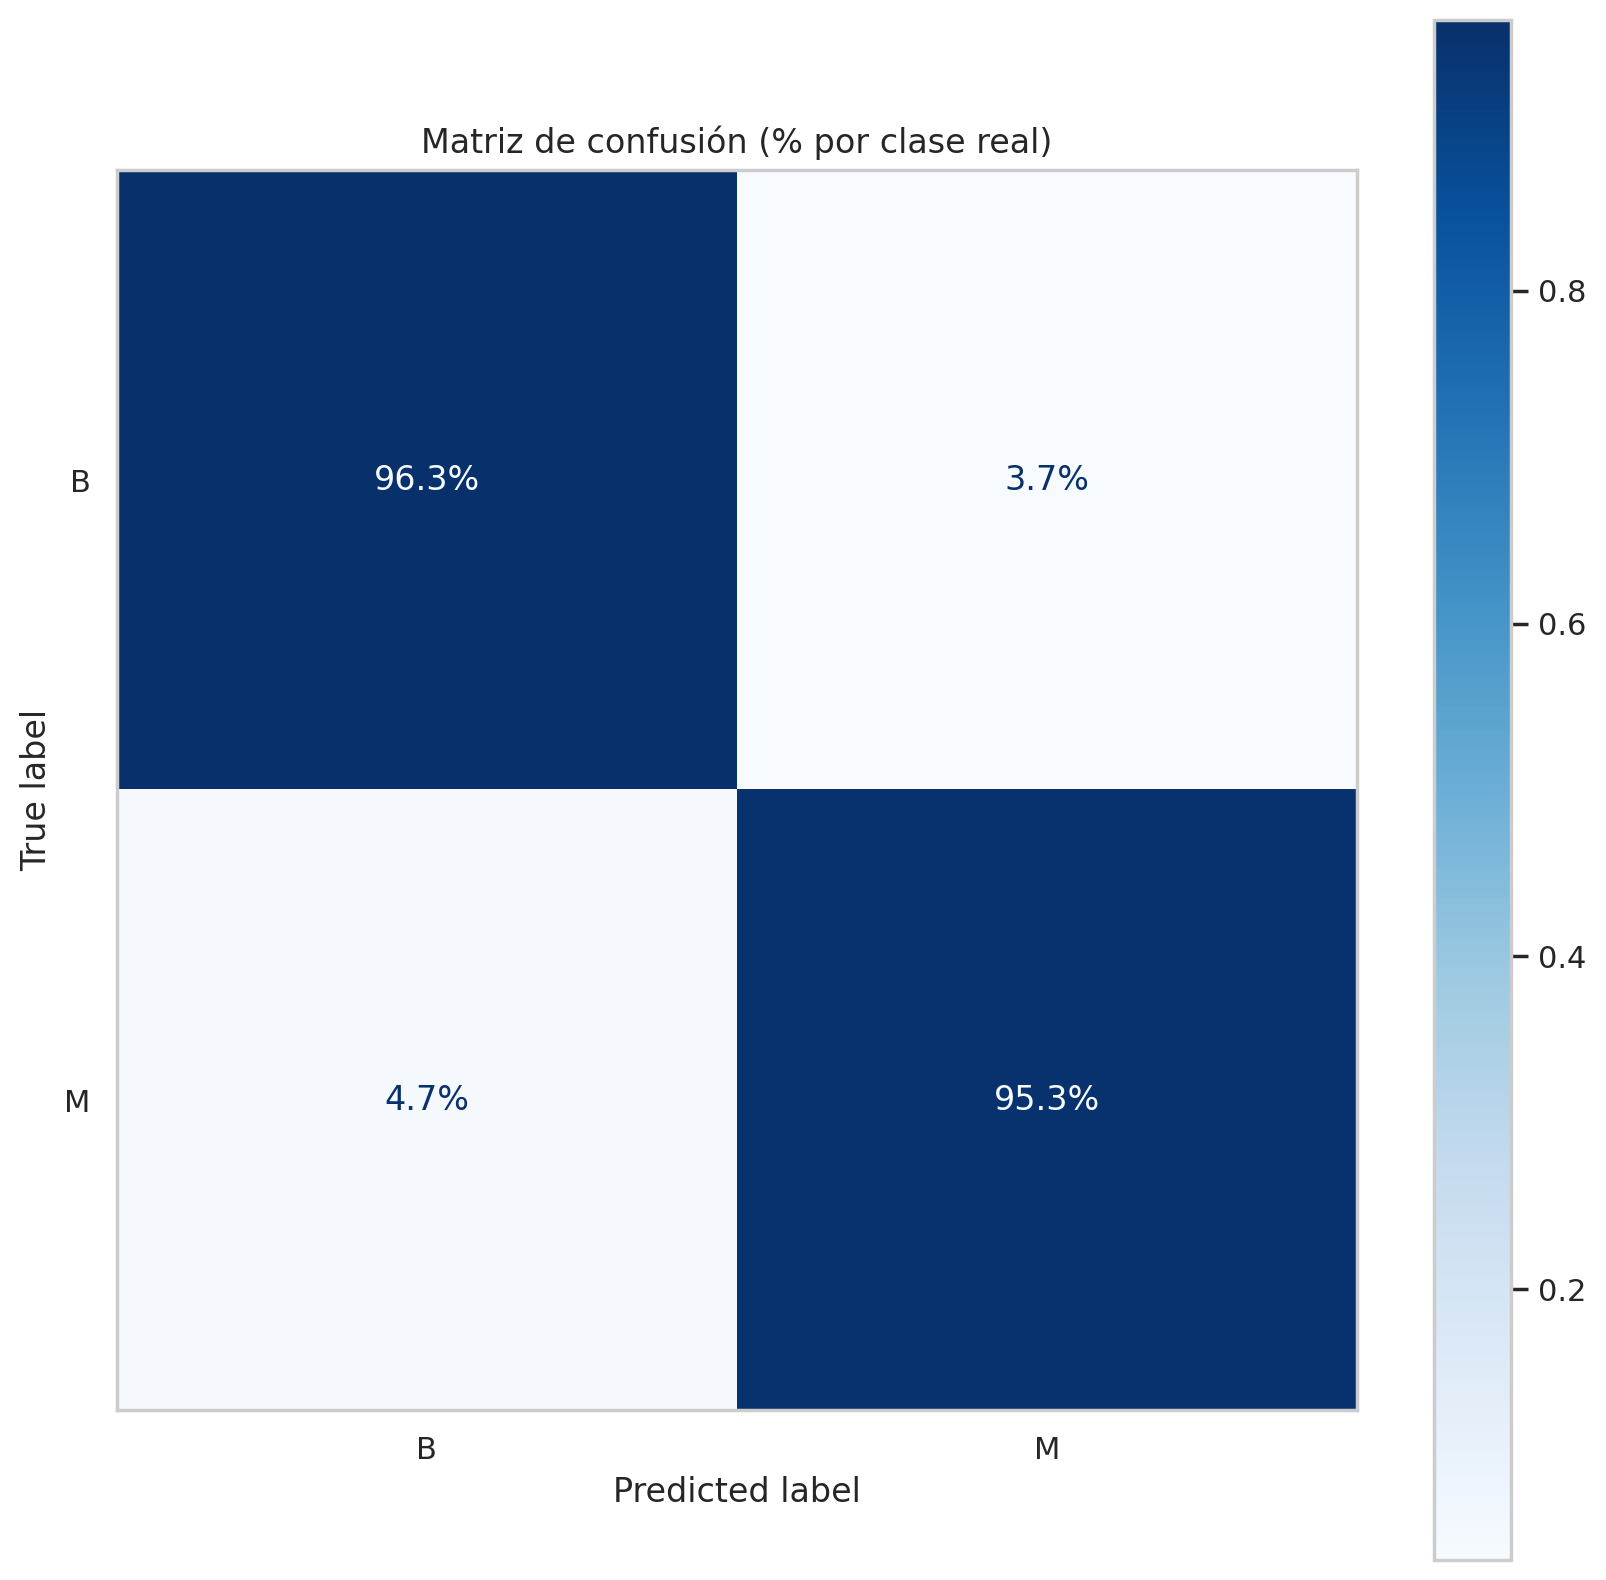

In [14]:
matriz_confusion(h_c, Xte_c, yte_c);

In [15]:
validar_modelo(h_c, Xtr_c, ytr_c, 'f1_weighted', 10);

Validacion cruzada (10 folds, score=f1_weighted): media = 0.967 +/- 0.030


Clasificación **muy buena y estable** (validación cruzada con poca dispersión); las curvas de aprendizaje convergen, sin desfase preocupante. Aunque la clase maligna es minoritaria (~37 %), **se detecta con alta sensibilidad** (su *recall* es alto en el informe anterior), por lo que **no es necesario aplicar técnicas de equilibrado** en este ejemplo.

### Importancia de los predictores (permutación)

`HistGradientBoosting` **no expone** la importancia por impureza (`feature_importances_`), así que usamos la **importancia por permutación** (sobre test) y, a continuación, SHAP.

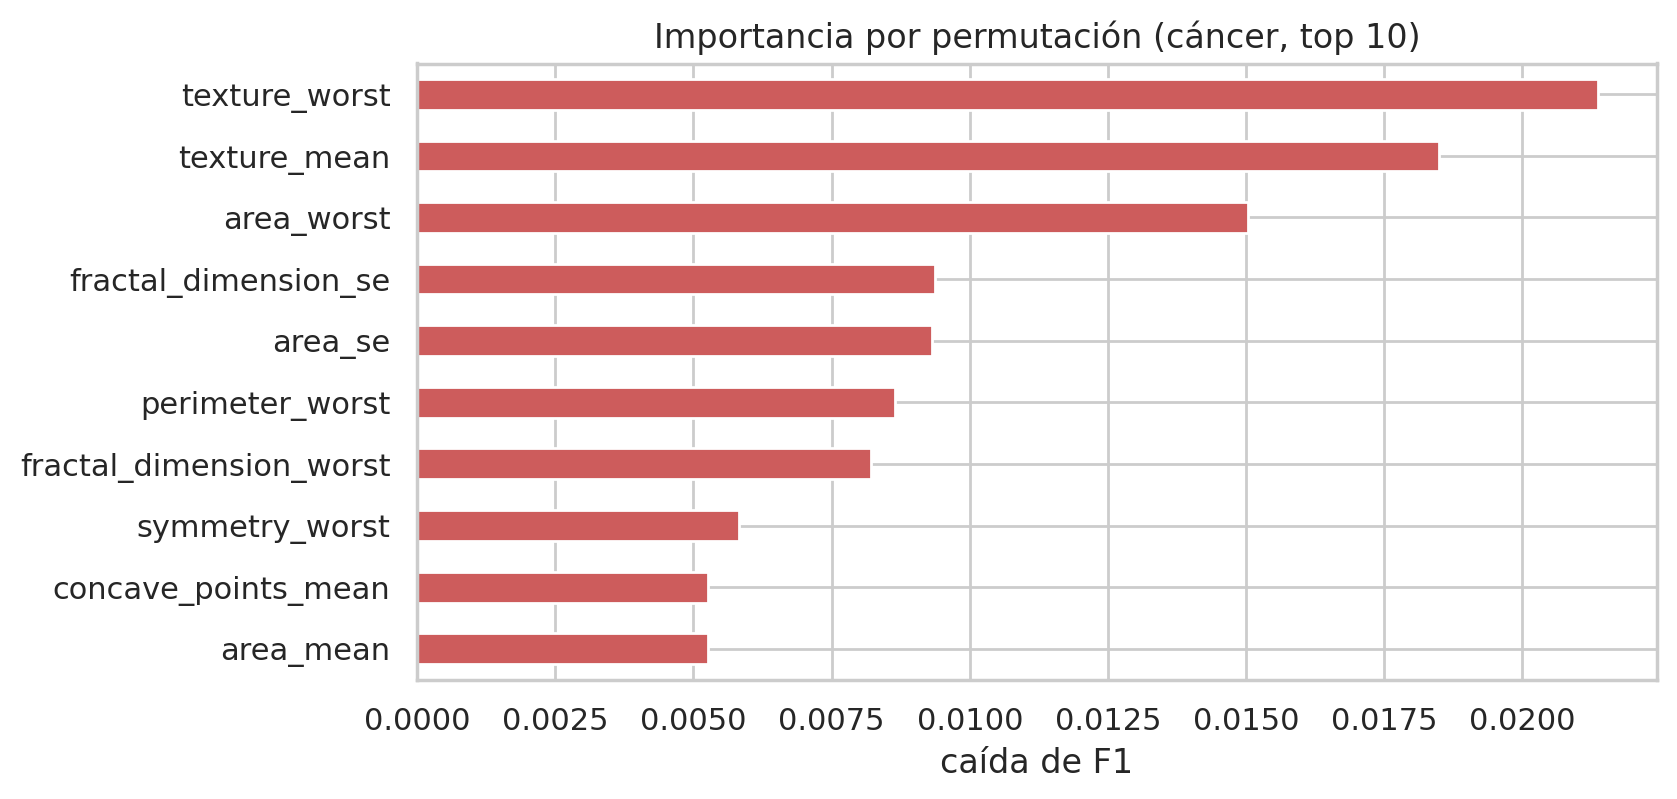

In [16]:
perm_c = permutation_importance(h_c, Xte_c, yte_c, n_repeats=10, random_state=0, scoring='f1_weighted')
imp_c = pd.Series(perm_c.importances_mean, index=Xte_c.columns).sort_values(ascending=False).head(10)
imp_c.plot.barh(figsize=(8, 4), color='indianred'); plt.gca().invert_yaxis()
plt.title('Importancia por permutación (cáncer, top 10)'); plt.xlabel('caída de F1'); plt.show()

Destacan variables del grupo *worst* (los peores valores del tumor). La permutación tiende a dar valores pequeños por la fuerte **correlación** entre variables (radio, perímetro, área…); SHAP repartirá mejor esa importancia.

### Explicabilidad con valores de Shapley (SHAP)

Aplicamos **TreeSHAP** al `HistGradientBoosting`. Recordemos que en boosting los valores SHAP están en escala **log-odds**: `base + Σφ = decision_function`, y la probabilidad se obtiene con la **sigmoide**. En binario la forma es `(n, variables)`.

In [17]:
Xs_c = Xte_c.reset_index(drop=True)
ys_c = yte_c.reset_index(drop=True)
shap_c = shap.TreeExplainer(h_c)(Xs_c)               # binario -> forma (n, variables), en log-odds
base = float(np.array(shap_c.base_values).ravel()[0])
i0 = int((h_c.predict_proba(Xs_c)[:, 1] > 0.5).argmax())     # un paciente predicho como maligno
margen = float(shap_c.values[i0].sum() + np.array(shap_c.base_values).ravel()[i0])
print('Forma de los valores SHAP:', np.array(shap_c.values).shape, '| valor base (log-odds):', round(base, 3))
print(f'Aditividad (fila {i0}): base + Σφ = {margen:.3f} = decision_function = '
      f'{h_c.decision_function(Xs_c.iloc[[i0]])[0]:.3f}')
print(f'  -> probabilidad = sigmoide({margen:.3f}) = {expit(margen):.3f}  |  predict_proba(M) = '
      f'{h_c.predict_proba(Xs_c.iloc[[i0]])[0,1]:.3f}')

Forma de los valores SHAP: (171, 30) | valor base (log-odds): -3.748
Aditividad (fila 3): base + Σφ = 16.253 = decision_function = 16.253
  -> probabilidad = sigmoide(16.253) = 1.000  |  predict_proba(M) = 1.000


Se cumple la **aditividad** en log-odds: el valor base más la suma de los valores SHAP reproduce **exactamente** la salida del modelo (`decision_function`), y aplicando la sigmoide se recupera la probabilidad de maligno. Cada variable empuja la log-odds hacia maligno (φ positivo) o hacia benigno (negativo).



#### Importancia global: gráfico de barras

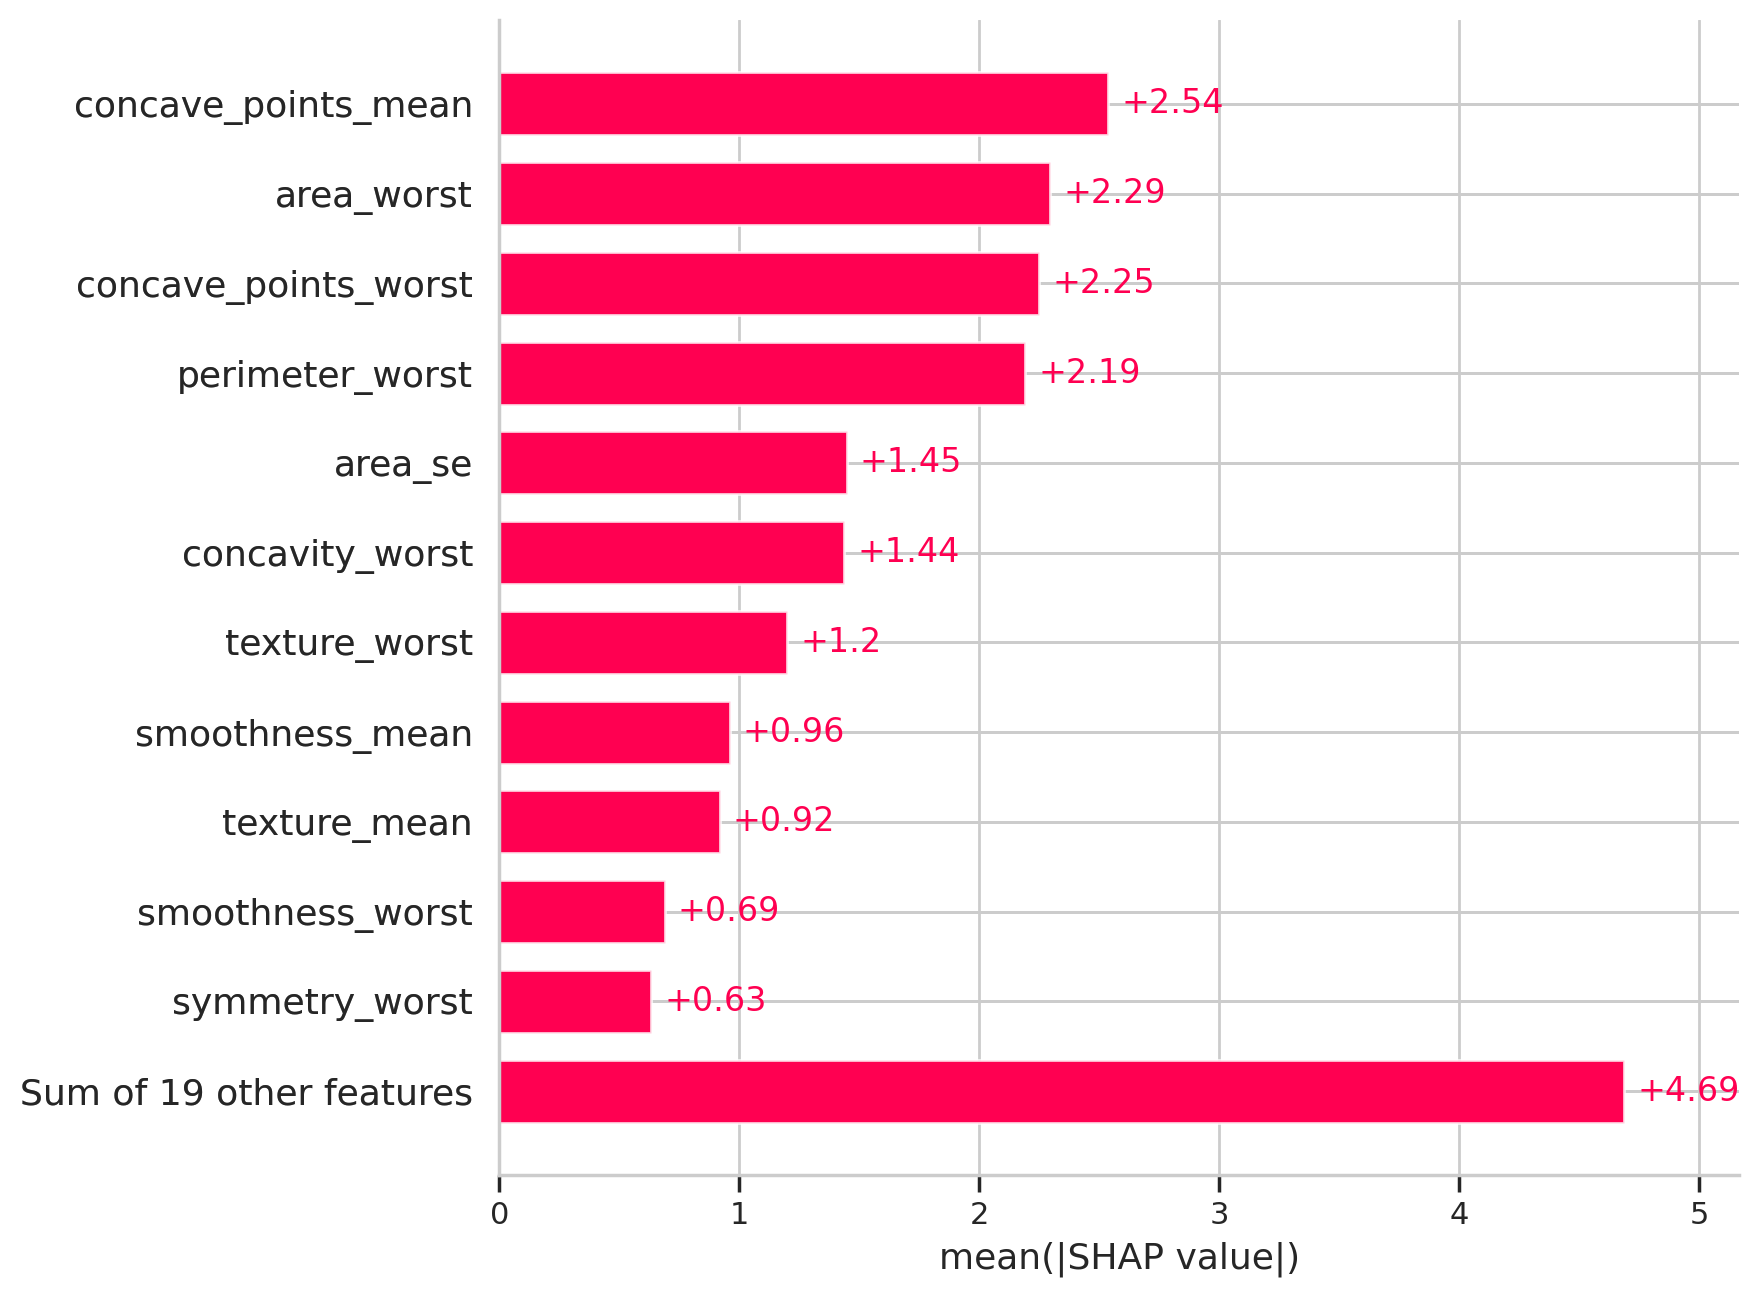

In [18]:
shap.plots.bar(shap_c, max_display=12)

Ordena las variables por su valor SHAP medio absoluto. Dominan las del grupo *worst* (`concave_points_worst`, `perimeter_worst`, `area_worst`…), repartiendo la importancia de forma justa entre las correlacionadas.



#### Efecto y dirección: gráfico de enjambre (*beeswarm*)

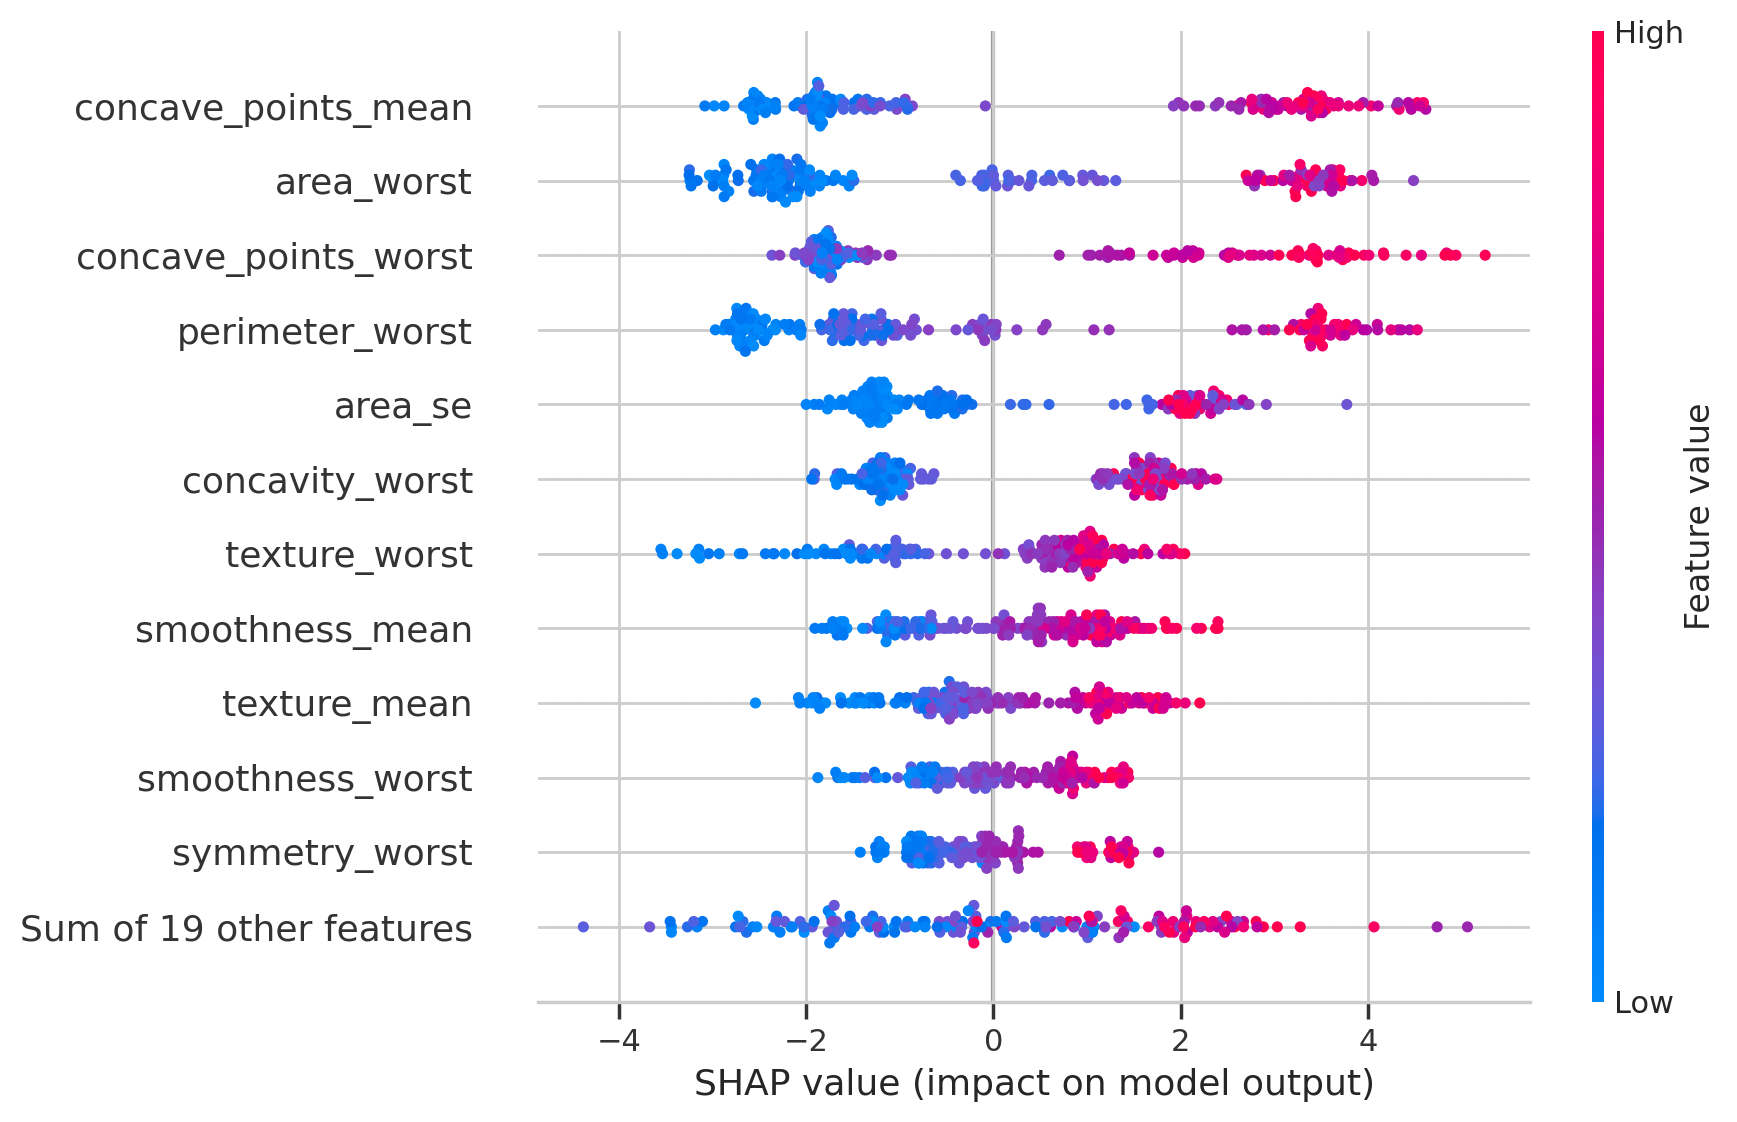

In [19]:
shap.plots.beeswarm(shap_c, max_display=12)

Para las variables *worst*, los **valores altos (rojo) están a la derecha** (empujan hacia **maligno**) y los bajos (azul) a la izquierda: tumores más grandes/irregulares → mayor log-odds de maligno, como cabía esperar.



#### Explicación local de 4 pacientes (*waterfall*)

Mostramos cuatro pacientes que cubren el rango de probabilidad (de claramente benigno a claramente maligno), indicando su fila, su diagnóstico real y su probabilidad predicha. Las barras parten del valor base (log-odds) y suman/restan hasta la log-odds final.

>>> Muestra 1: fila 18  |  clase real = B  |  probabilidad predicha de la clase analizada = 0.00


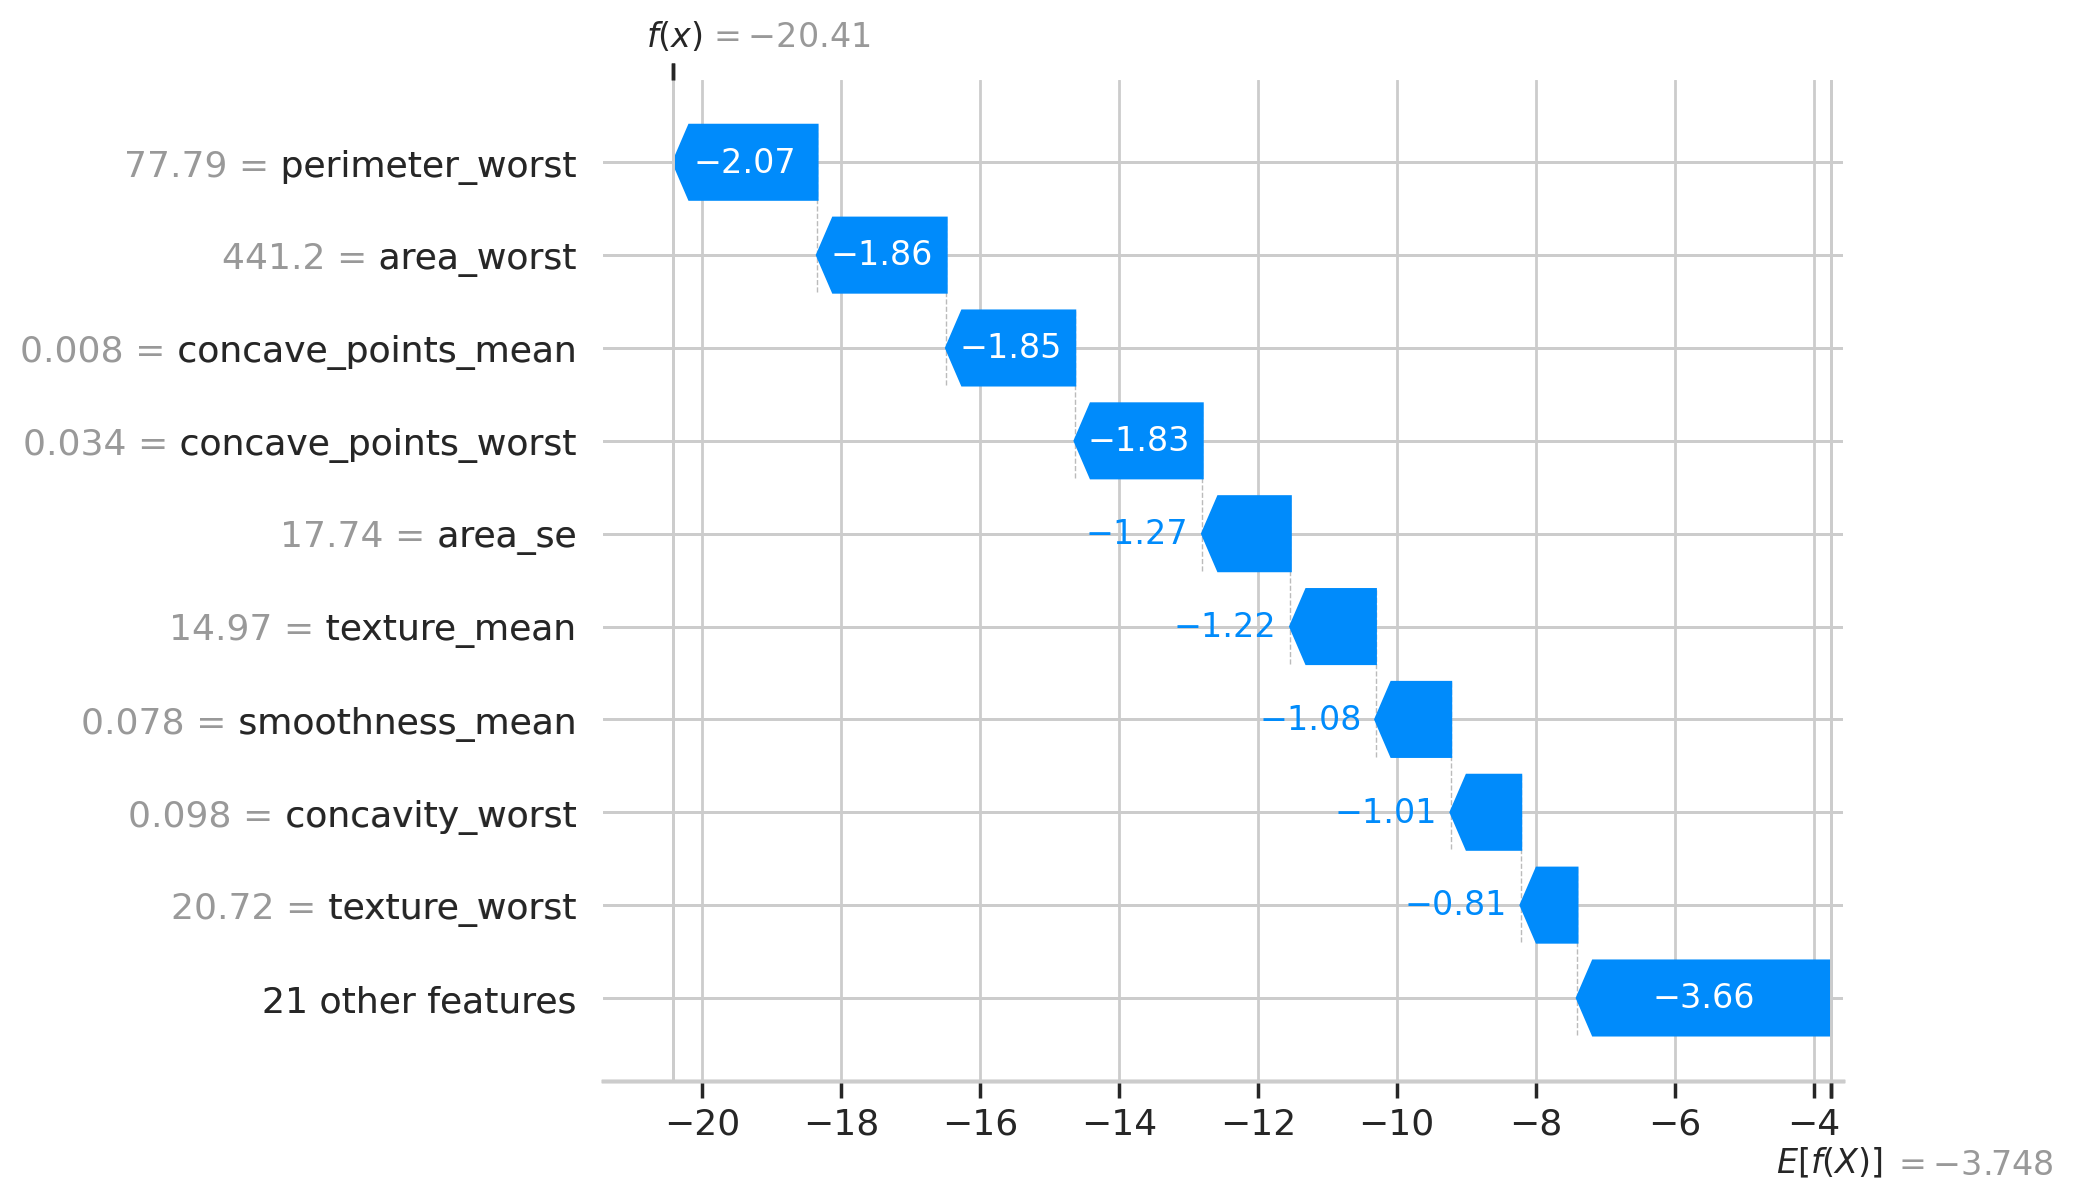

>>> Muestra 2: fila 94  |  clase real = B  |  probabilidad predicha de la clase analizada = 0.35


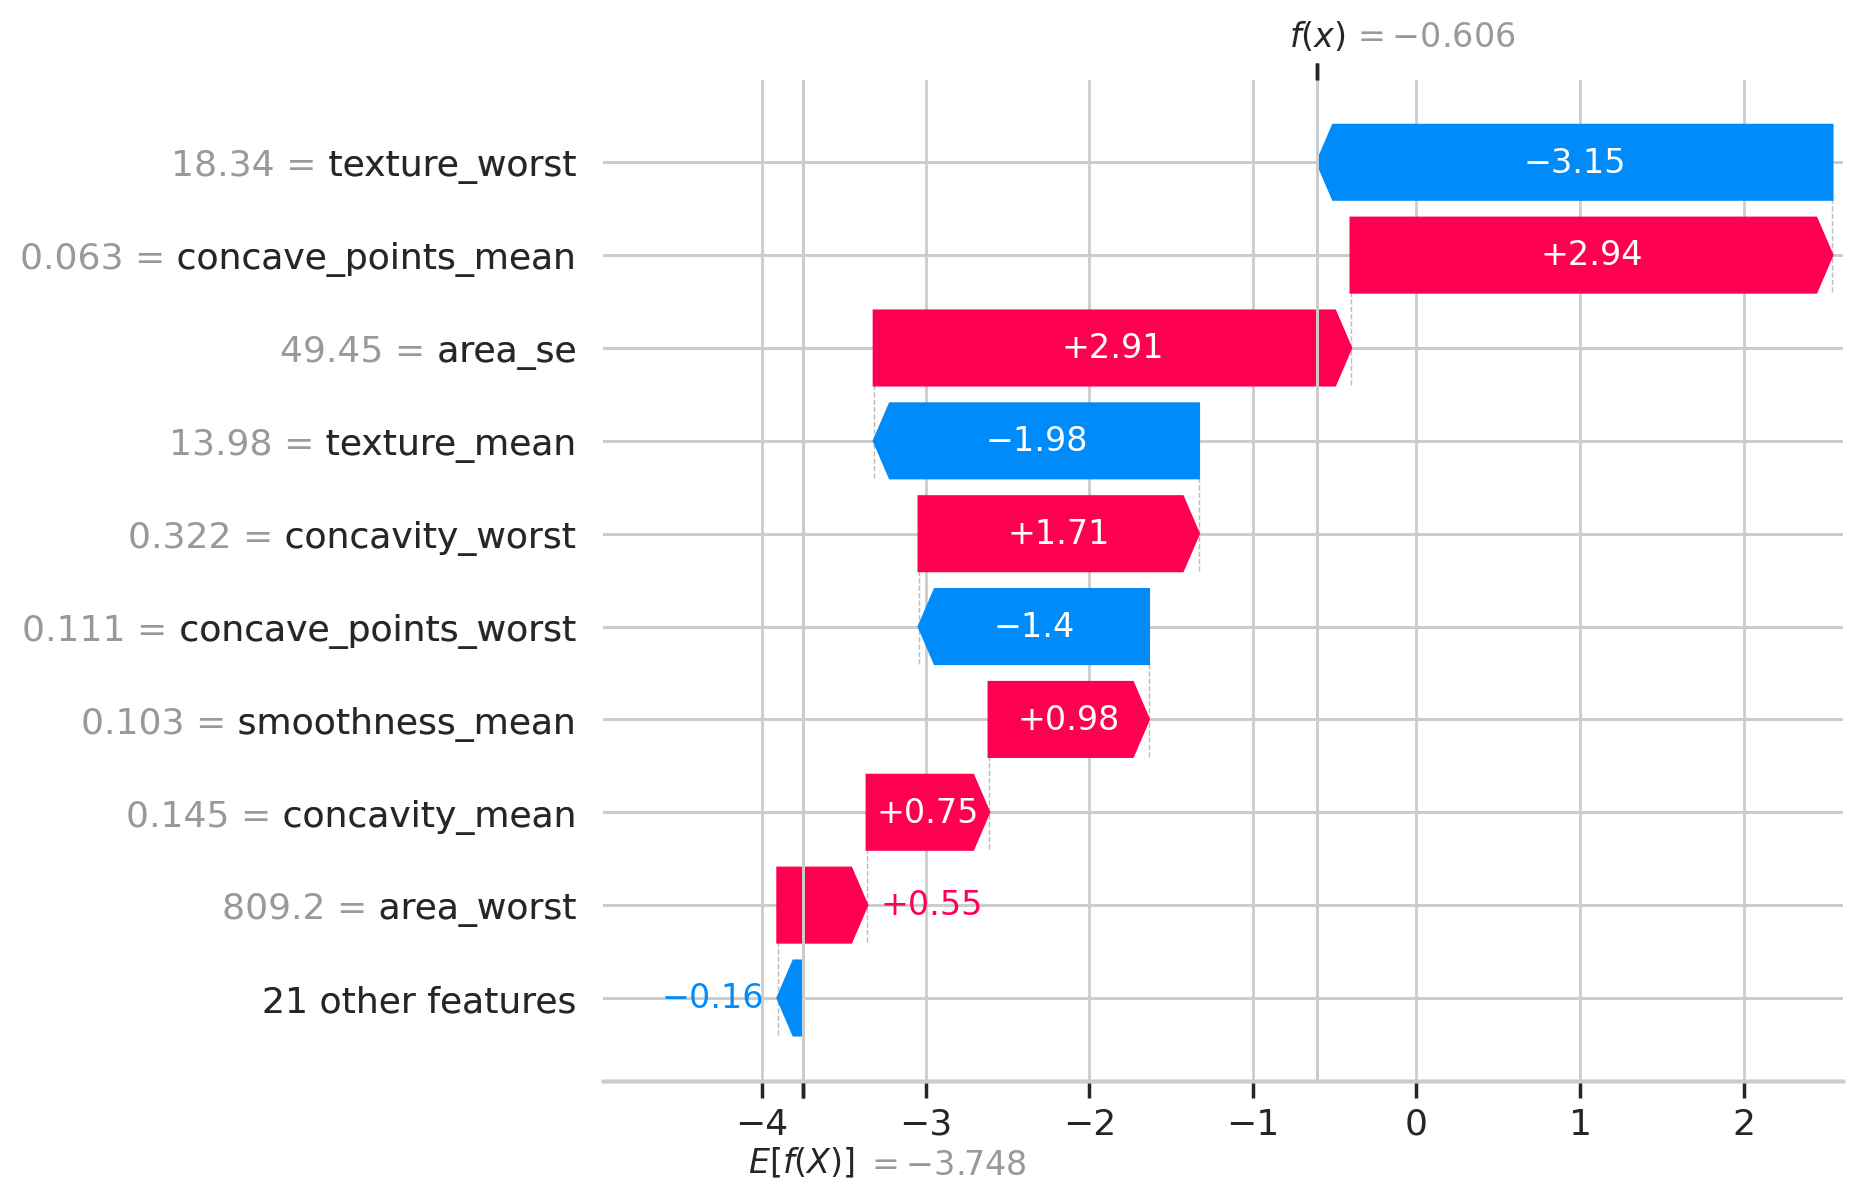

>>> Muestra 3: fila 138  |  clase real = B  |  probabilidad predicha de la clase analizada = 0.67


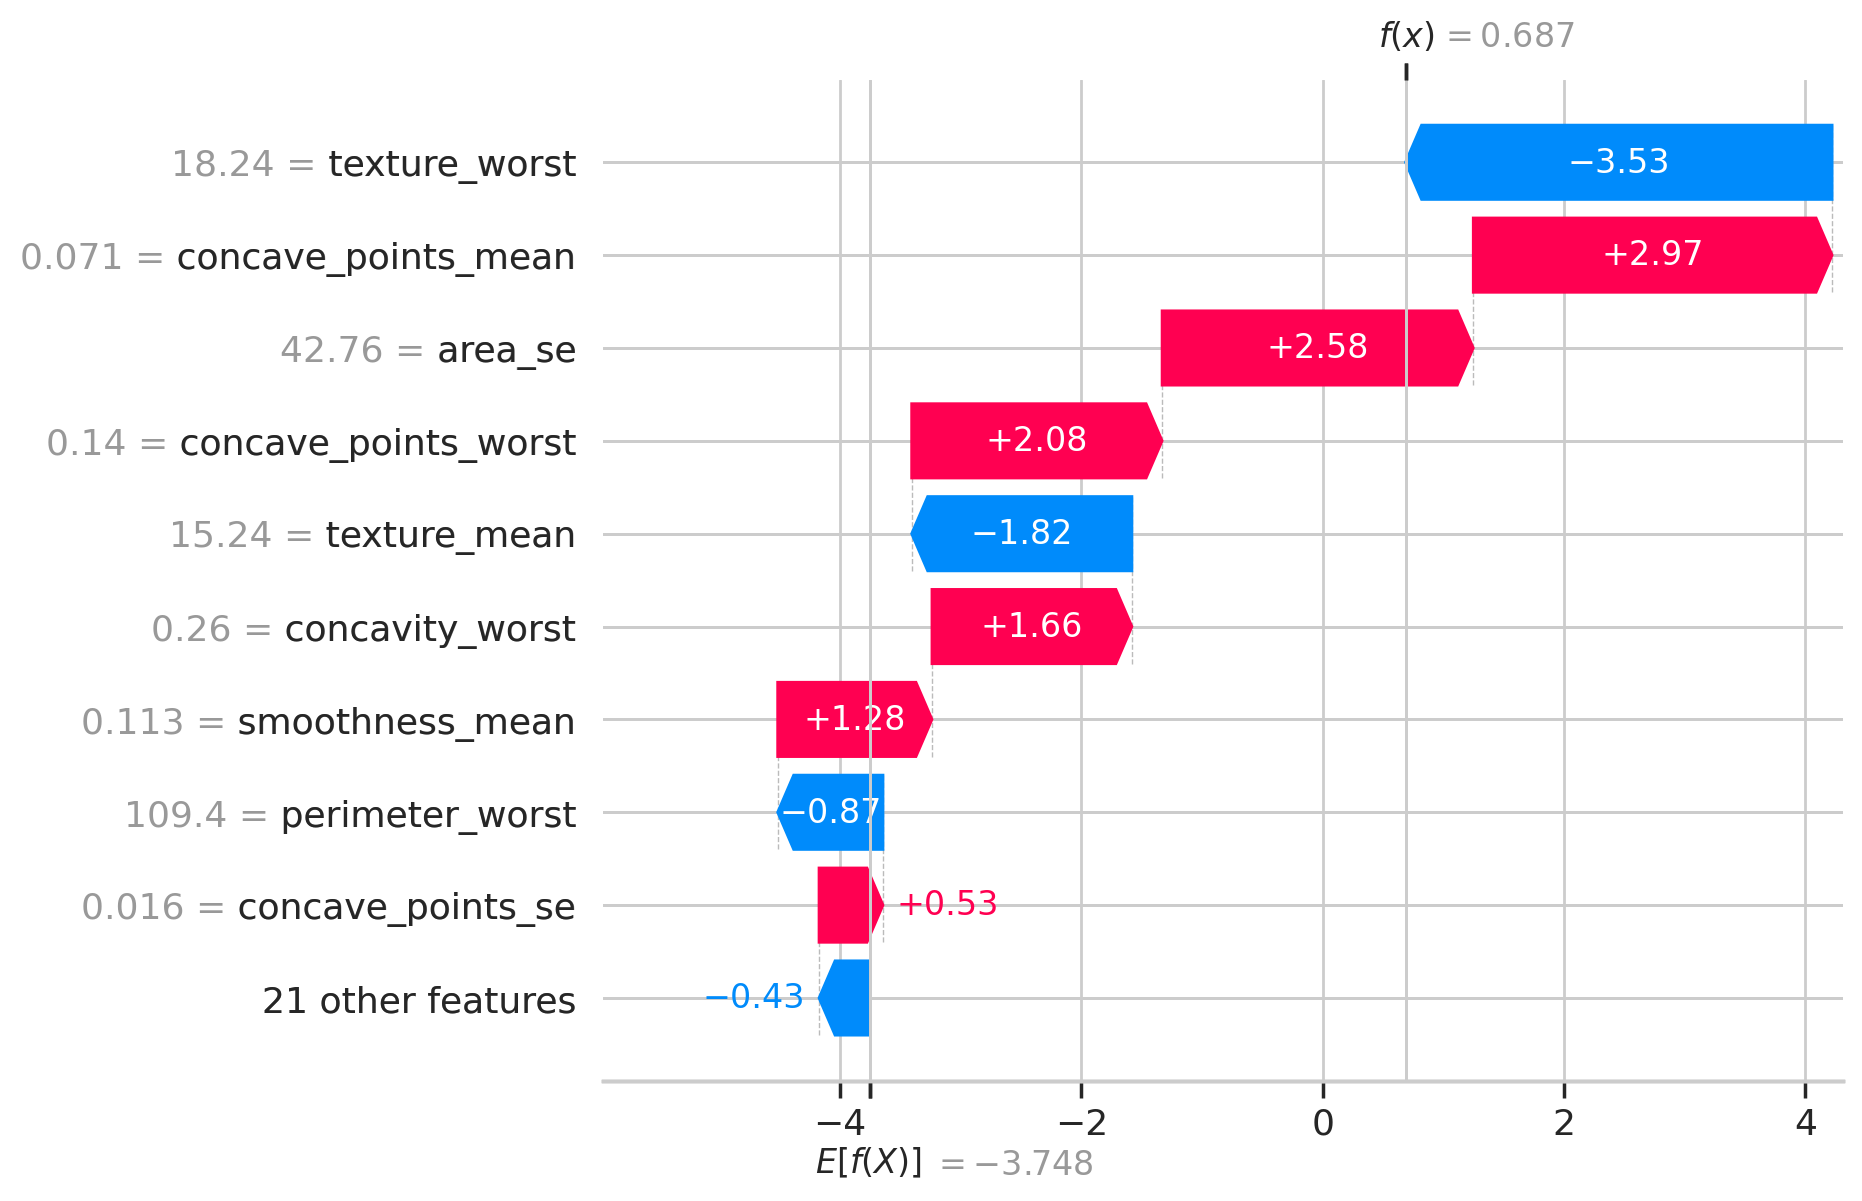

>>> Muestra 4: fila 169  |  clase real = M  |  probabilidad predicha de la clase analizada = 1.00


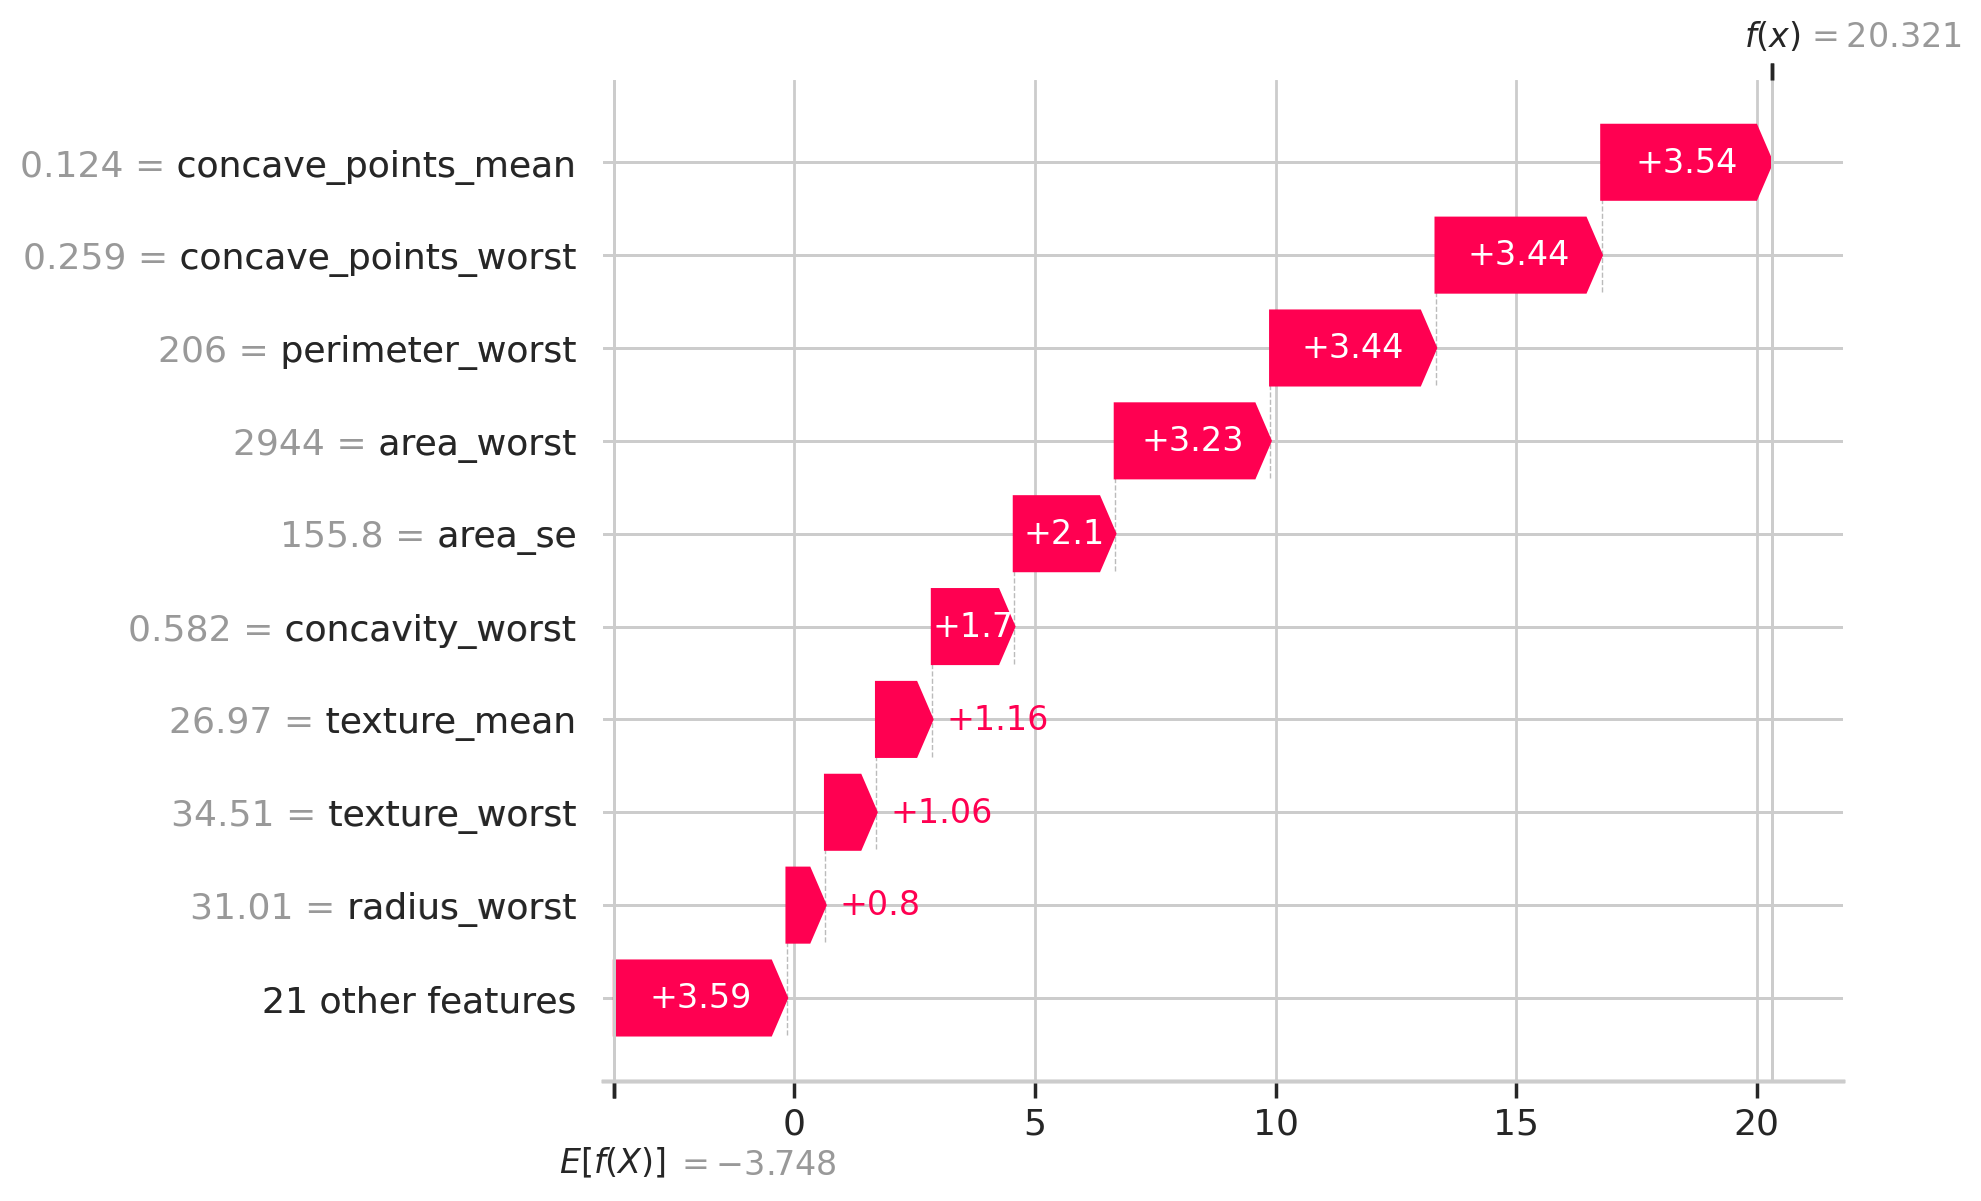

In [20]:
proba_M = h_c.predict_proba(Xs_c)[:, 1]
waterfalls_muestras(shap_c, proba_M, ys_c, n=4)

Se ve el contraste: en un paciente **benigno** casi todas las barras son **azules** (log-odds muy negativa → probabilidad ≈ 0); en uno **maligno**, dominan las **rojas** (log-odds alta → probabilidad ≈ 1); los casos **intermedios** mezclan empujes. Así se justifica, paciente a paciente, la decisión del modelo.



#### Forma del efecto: gráfico de dependencia (*scatter*)

Recordatorio de lectura: el **eje X** es el **valor real** de la variable y el **eje Y** su **valor SHAP** (log-odds); la nube muestra **cómo cambia el empuje de la variable según su valor**, y el color codifica la variable que más interactúa.

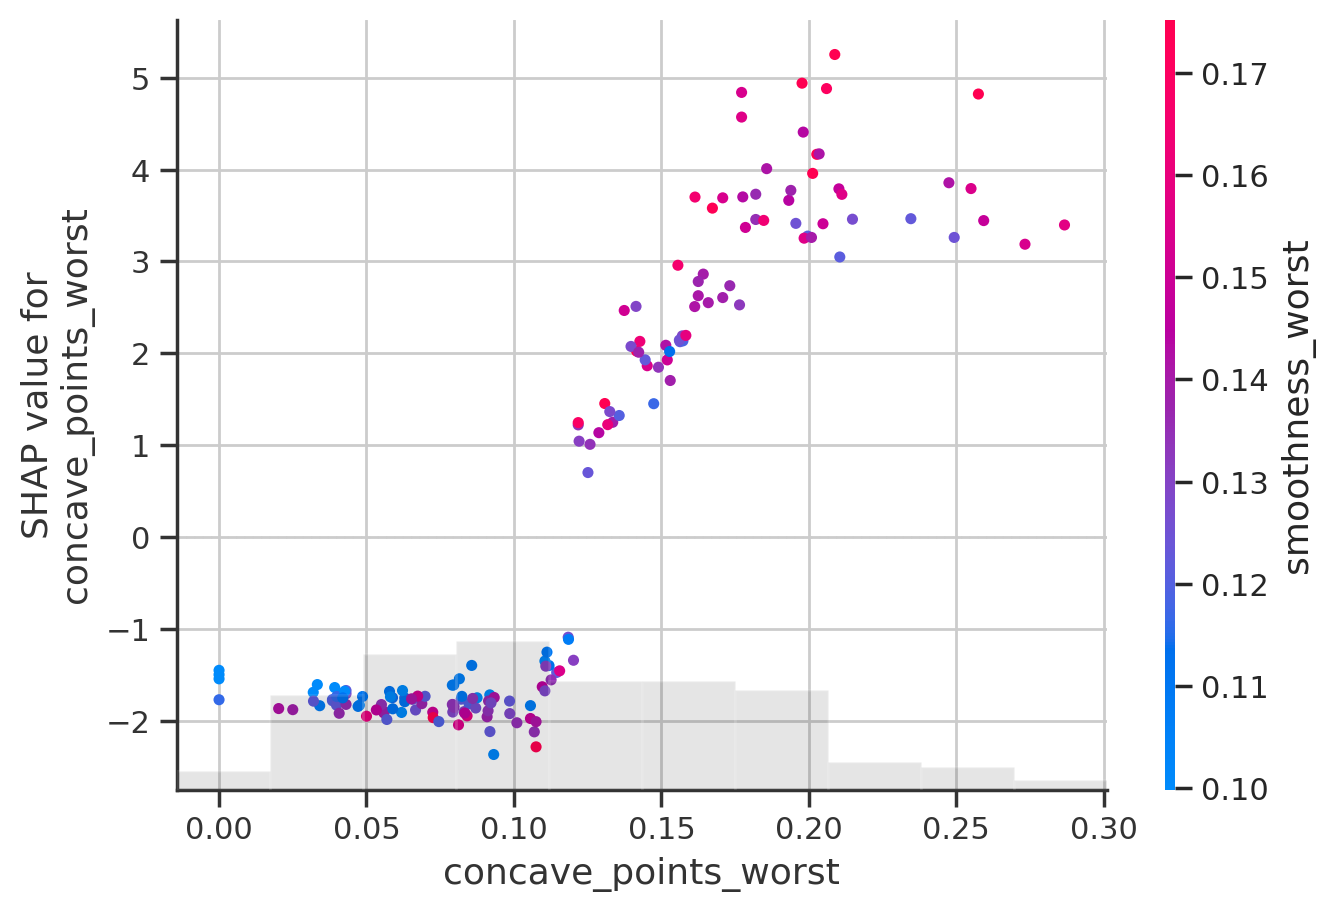

In [21]:
shap.plots.scatter(shap_c[:, 'concave_points_worst'], color=shap_c)

A partir de cierto **umbral** de `concave_points_worst` el valor SHAP **se dispara** hacia valores positivos: por encima de ese punto la variable empuja con fuerza hacia **maligno** (efecto **no lineal, de umbral**). El color revela posibles **interacciones** con otra variable.

## <font color="steelblue">4.2. Abulones (con análisis SHAP multiclase)</font>

Clasificamos el **sexo** del abulón (M/F/I) por medidas físicas. Cargamos `abalone.csv` **sin limpiar**; no tiene ausentes ni identificadores, y al ser todas las predictoras numéricas no hay categóricas que codificar. **No estandarizamos** (árboles).

In [22]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone.csv'
abalone = pd.read_csv(url); abalone['Sex'] = abalone['Sex'].astype('category')
print('Dimensiones:', abalone.shape)
tr, te = split_sample(abalone, 'Sex', 0.3, 0, True)
Xtr_a, ytr_a = tr.drop(columns='Sex'), tr['Sex']
Xte_a, yte_a = te.drop(columns='Sex'), te['Sex']

Dimensiones: (4177, 9)
Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras


### Comparación de los algoritmos de boosting

In [23]:
comparar_boosting(Xtr_a, ytr_a, Xte_a, yte_a)

,F1 train,F1 test,desfase (train-test)
AdaBoost,0.521,0.493,0.028
Gradient Boosting,0.717,0.523,0.194
HistGradientBoosting,0.958,0.535,0.423
XGBoost,0.977,0.524,0.453
LightGBM,0.916,0.522,0.393
CatBoost,0.918,0.546,0.372


Aquí ocurre lo contrario que en cáncer: todos **memorizan** mucho el entrenamiento (**F1 train** alto) pero el **test se queda en ≈ 0.52–0.54**, con un **desfase grande** = **sobreajuste**. Rinden todos parecido. Es un problema **intrínsecamente difícil**. Elegimos **CatBoost** (ligeramente el mejor aquí) para el análisis detallado.

### Optimización del modelo (`CatBoost`)

In [24]:
h_a, params_a, cv_a = optimizar_catboost(Xtr_a, ytr_a)
print('Mejores hiperparámetros:', params_a)
print(f'F1 (validación cruzada) = {cv_a:.3f}')
print(f'F1 train = {f1_score(ytr_a, h_a.predict(Xtr_a), average="weighted"):.3f} | '
      f'F1 test = {f1_score(yte_a, h_a.predict(Xte_a), average="weighted"):.3f}')

Mejores hiperparámetros: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
F1 (validación cruzada) = 0.547
F1 train = 0.640 | F1 test = 0.544


Aun optimizando, el test apenas supera **0.54**: como ya vimos con el bosque aleatorio, las medidas físicas **no separan** machos de hembras adultos, y ningún algoritmo de boosting puede arreglar esa limitación de los datos.

### Evaluación del modelo óptimo

In [25]:
reports_clas(h_a, Xtr_a, ytr_a, Xte_a, yte_a)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           F       0.64      0.52      0.58       915
           I       0.71      0.81      0.76       939
           M       0.58      0.60      0.59      1069

    accuracy                           0.64      2923
   macro avg       0.64      0.65      0.64      2923
weighted avg       0.64      0.64      0.64      2923


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           F       0.46      0.39      0.42       392
           I       0.71      0.79      0.75       403
           M       0.47      0.48      0.47       459

    accuracy                           0.55      1254
   macro avg       0.54      0.55      0.55      1254
weighted avg       0.54      0.55      0.54      1254



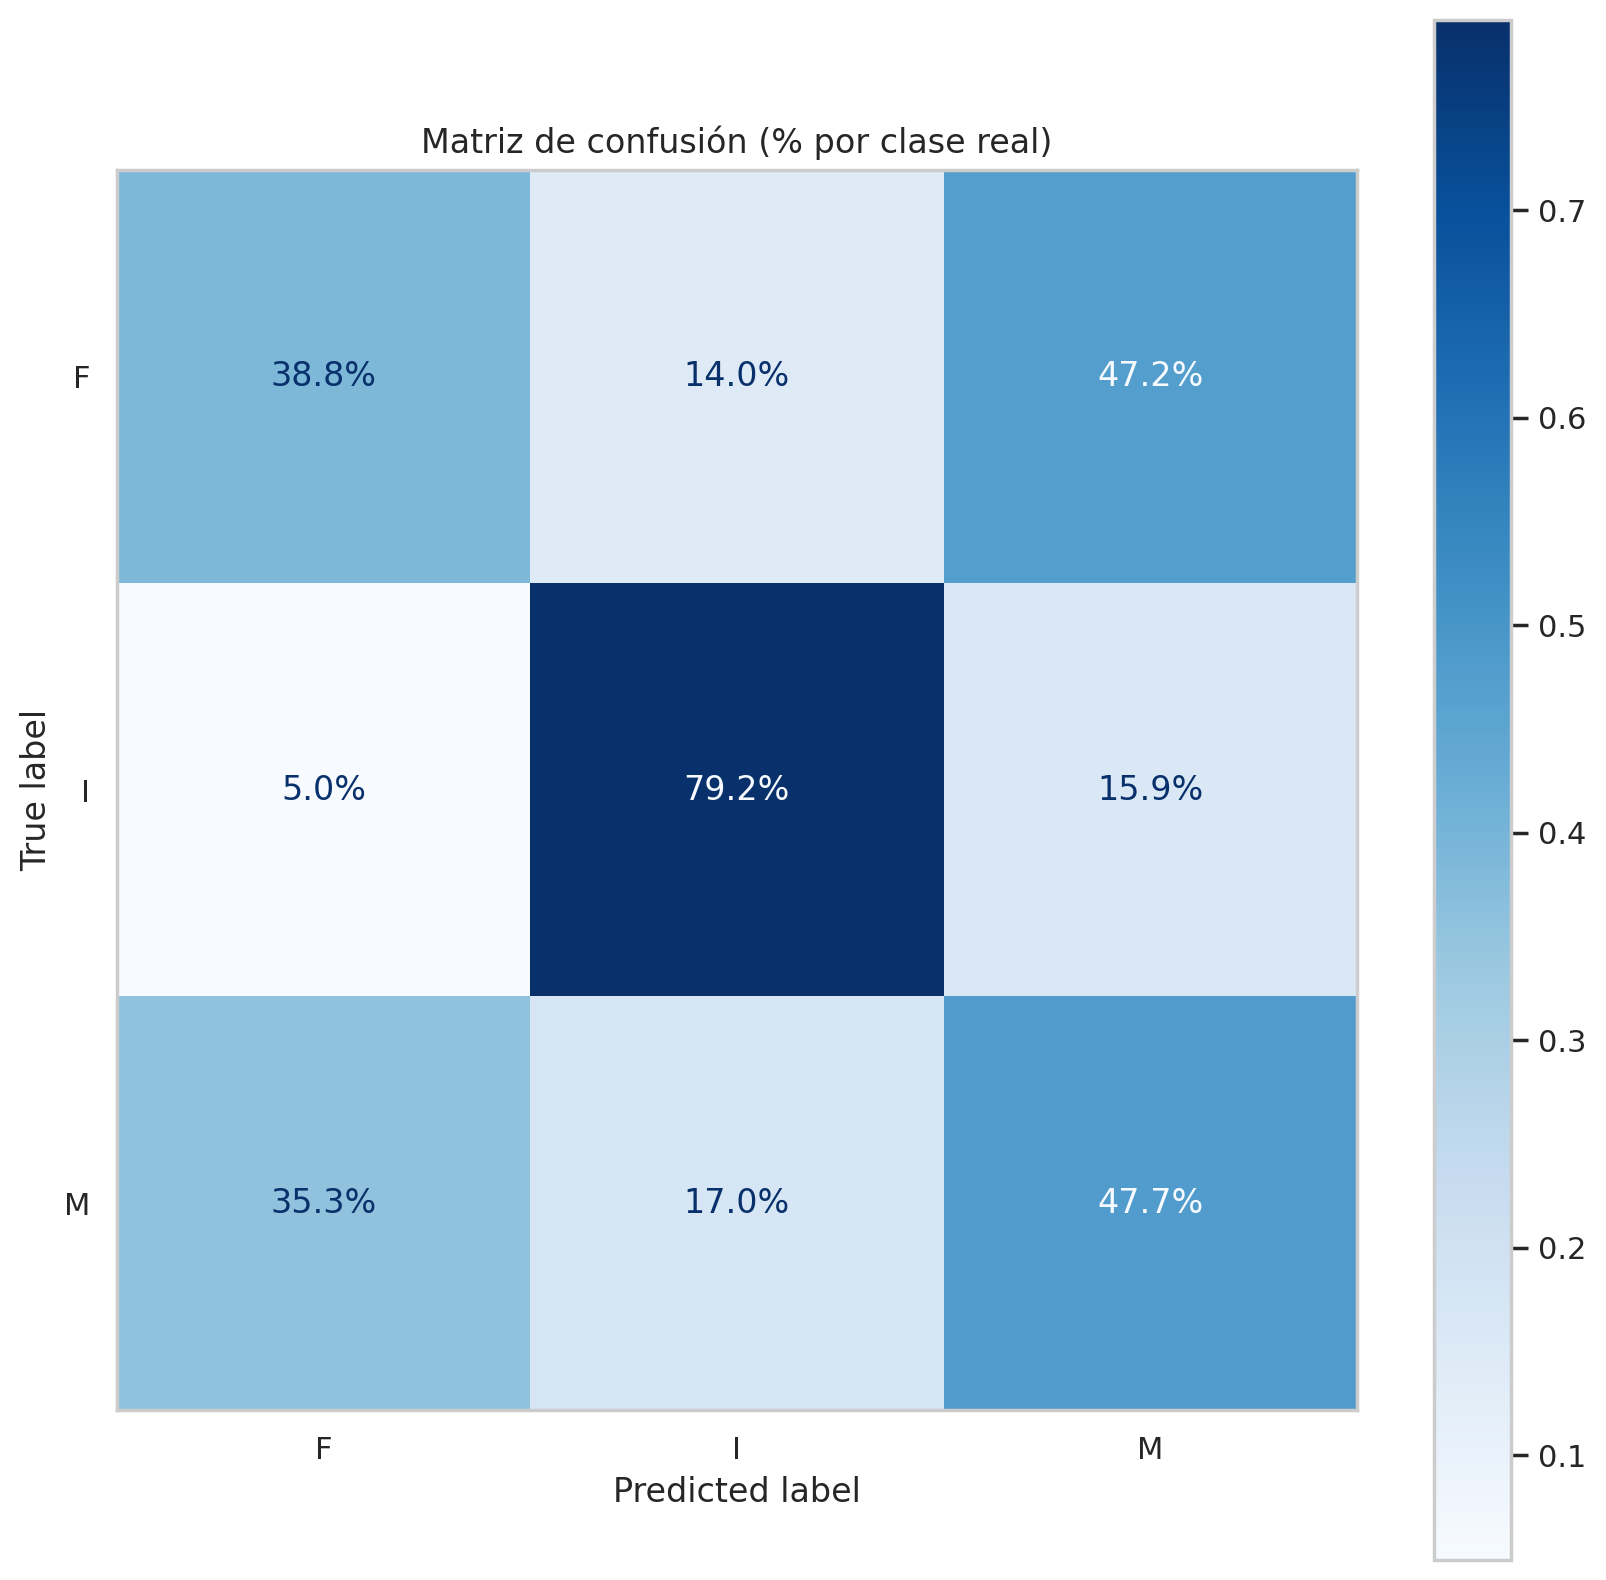

In [26]:
matriz_confusion(h_a, Xte_a, yte_a);

In [27]:
validar_modelo(h_a, Xtr_a, ytr_a, 'f1_weighted', 10);

Validacion cruzada (10 folds, score=f1_weighted): media = 0.553 +/- 0.014


La matriz confirma que **M y F se confunden** sistemáticamente y solo los **infantiles (I)** se distinguen bien. La validación es estable en torno a 0.54. Las tres clases están **equilibradas** (~1/3 cada una), así que **no procede** aplicar técnicas de equilibrado: la dificultad es de **separabilidad**, no de desequilibrio.

### Importancia de los predictores (permutación)

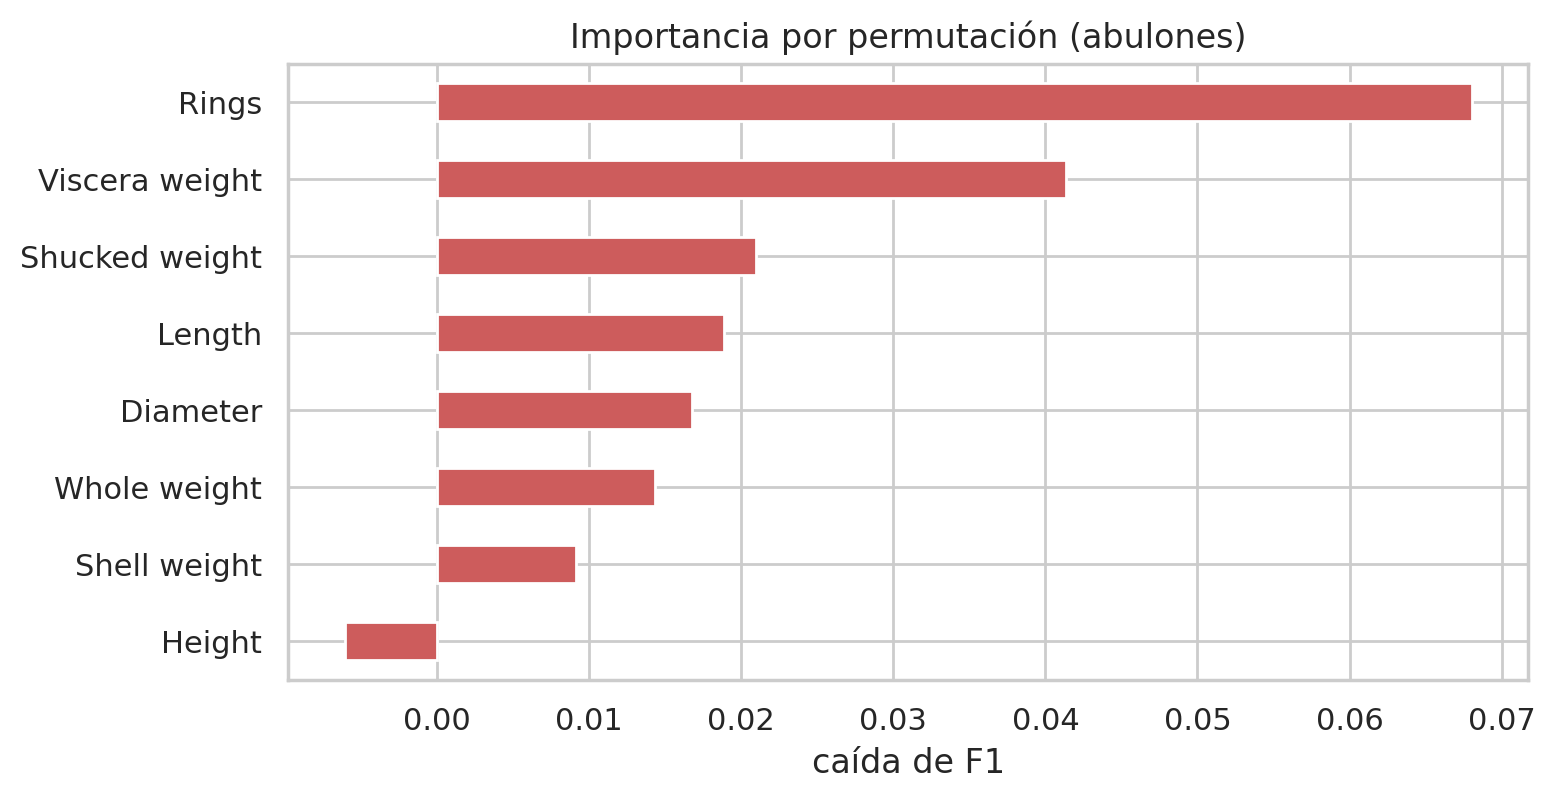

In [28]:
perm_a = permutation_importance(h_a, Xte_a, yte_a, n_repeats=10, random_state=0, scoring='f1_weighted')
imp_a = pd.Series(perm_a.importances_mean, index=Xte_a.columns).sort_values(ascending=False)
imp_a.plot.barh(figsize=(8, 4), color='indianred'); plt.gca().invert_yaxis()
plt.title('Importancia por permutación (abulones)'); plt.xlabel('caída de F1'); plt.show()

Las variables de **peso** (`Shell weight`, `Viscera weight`, `Whole weight`) son las más influyentes, coherente con que el desarrollo sexual se asocia al tamaño/peso del animal.

### Explicabilidad con SHAP (multiclase)

Al haber **3 clases**, los valores SHAP tienen forma `(n, variables, 3)`. Mostramos la importancia **global** (promediando $|\phi|$ sobre las tres clases) y, para ver la **dirección**, nos centramos en la clase **infantil (I)**, la mejor identificada.

Forma de los valores SHAP: (300, 8, 3) | clases: ['F', 'I', 'M']


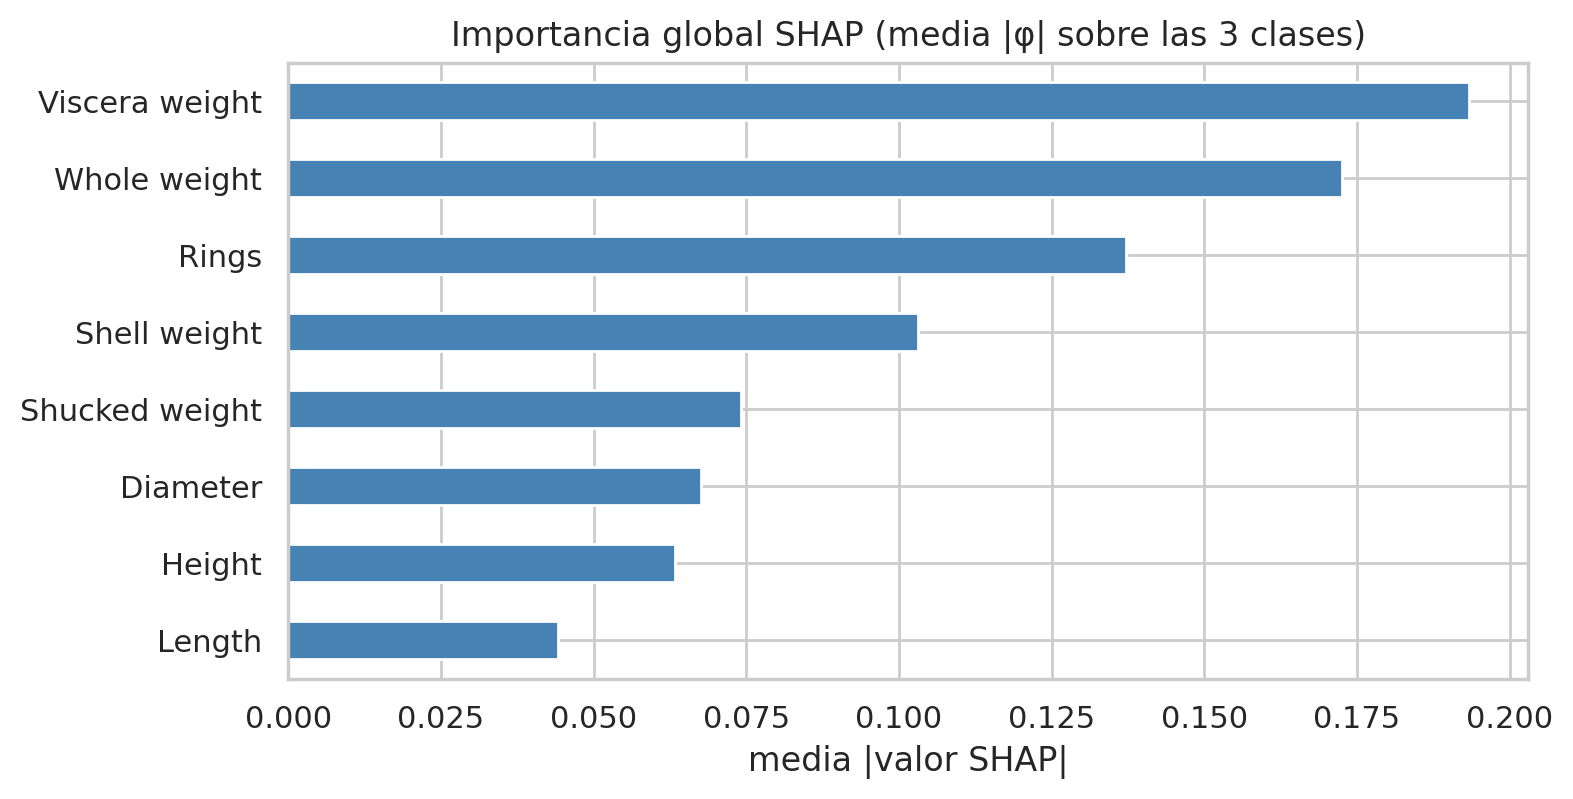

In [29]:
Xs_a = Xte_a.reset_index(drop=True).iloc[:300]
ys_a = yte_a.reset_index(drop=True).iloc[:300]
shap_a = shap.TreeExplainer(h_a)(Xs_a)
idx_I = list(h_a.classes_).index('I')
print('Forma de los valores SHAP:', np.array(shap_a.values).shape, '| clases:', list(h_a.classes_))
imp_glob = pd.Series(np.abs(shap_a.values).mean(axis=(0, 2)), index=Xs_a.columns).sort_values()
imp_glob.plot.barh(figsize=(8, 4), color='steelblue')
plt.title('Importancia global SHAP (media |φ| sobre las 3 clases)'); plt.xlabel('media |valor SHAP|'); plt.show()

Coincide con la permutación: las variables de **peso** dominan. SHAP permite además ver dirección y forma.

#### Dirección del efecto para la clase infantil (*beeswarm*)

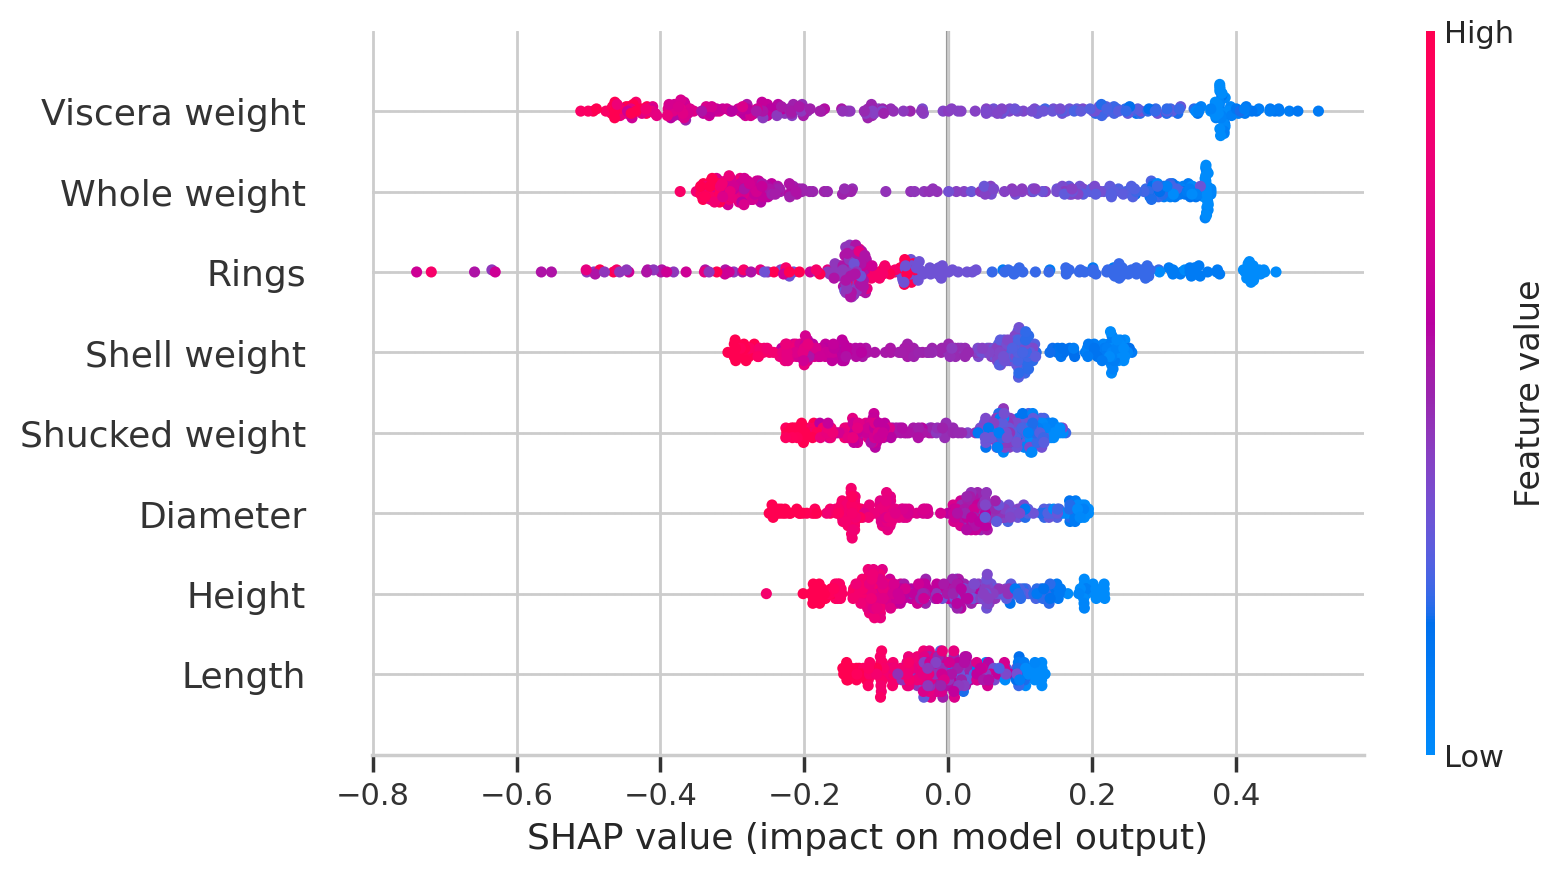

In [30]:
shap.plots.beeswarm(shap_a[:, :, idx_I], max_display=8)

A la derecha, empuje hacia **infantil**. Los **valores bajos (azul) de las variables de peso** empujan hacia infantil (los juveniles pesan menos) y los pesos altos (rojo) en contra: coherente con la biología.

#### Explicación local de 4 abulones (*waterfall*)

>>> Muestra 1: fila 23  |  clase real = M  |  probabilidad predicha de la clase analizada = 0.01


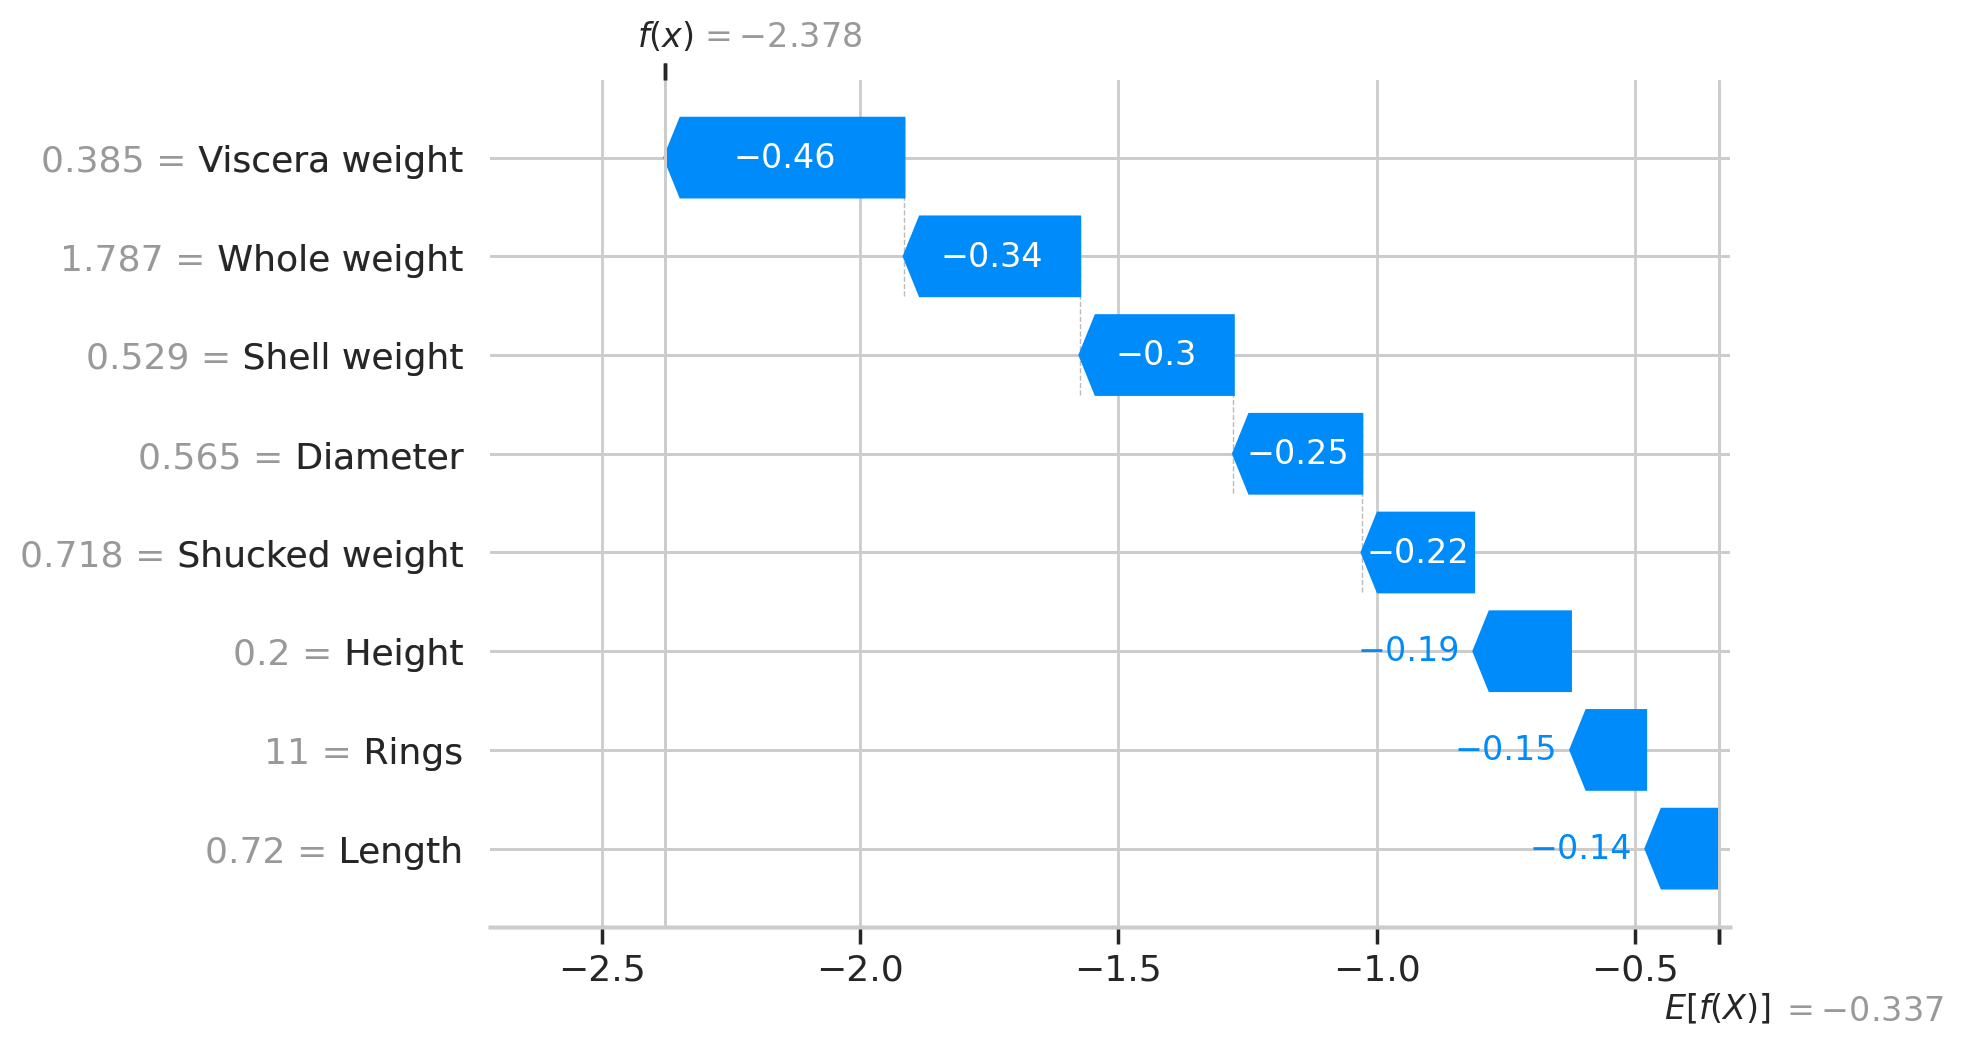

>>> Muestra 2: fila 70  |  clase real = I  |  probabilidad predicha de la clase analizada = 0.29


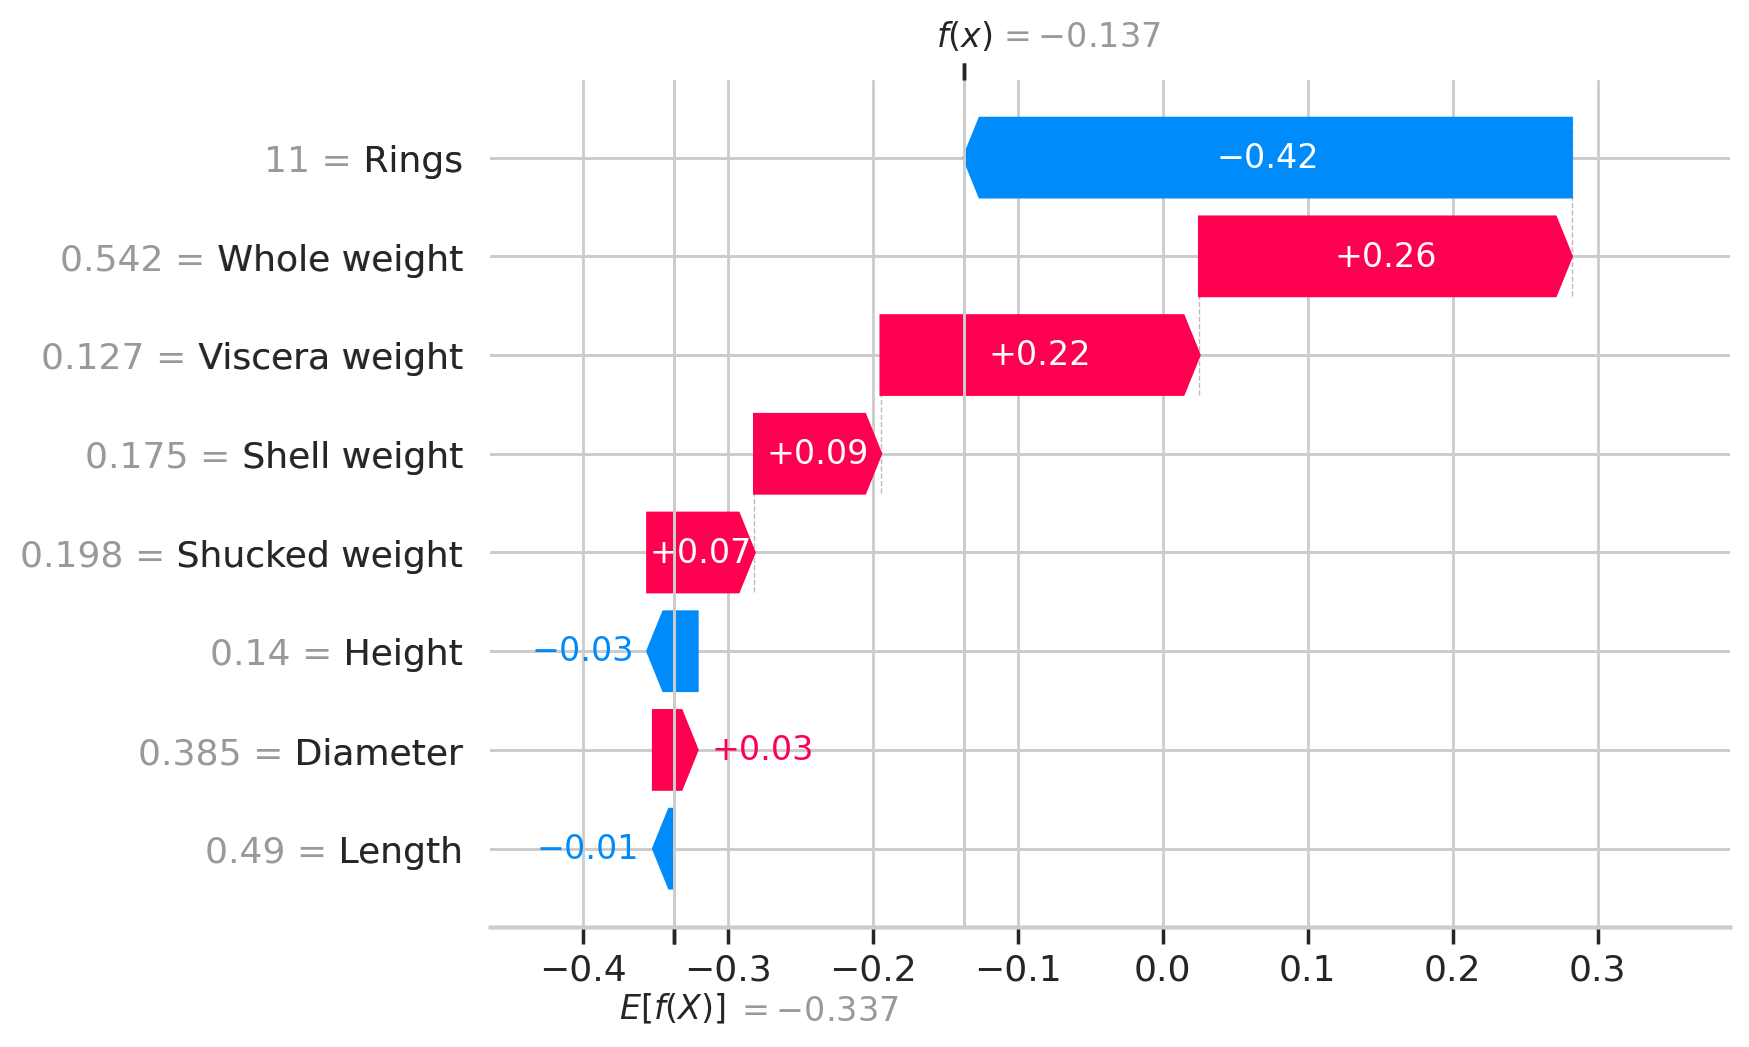

>>> Muestra 3: fila 121  |  clase real = I  |  probabilidad predicha de la clase analizada = 0.57


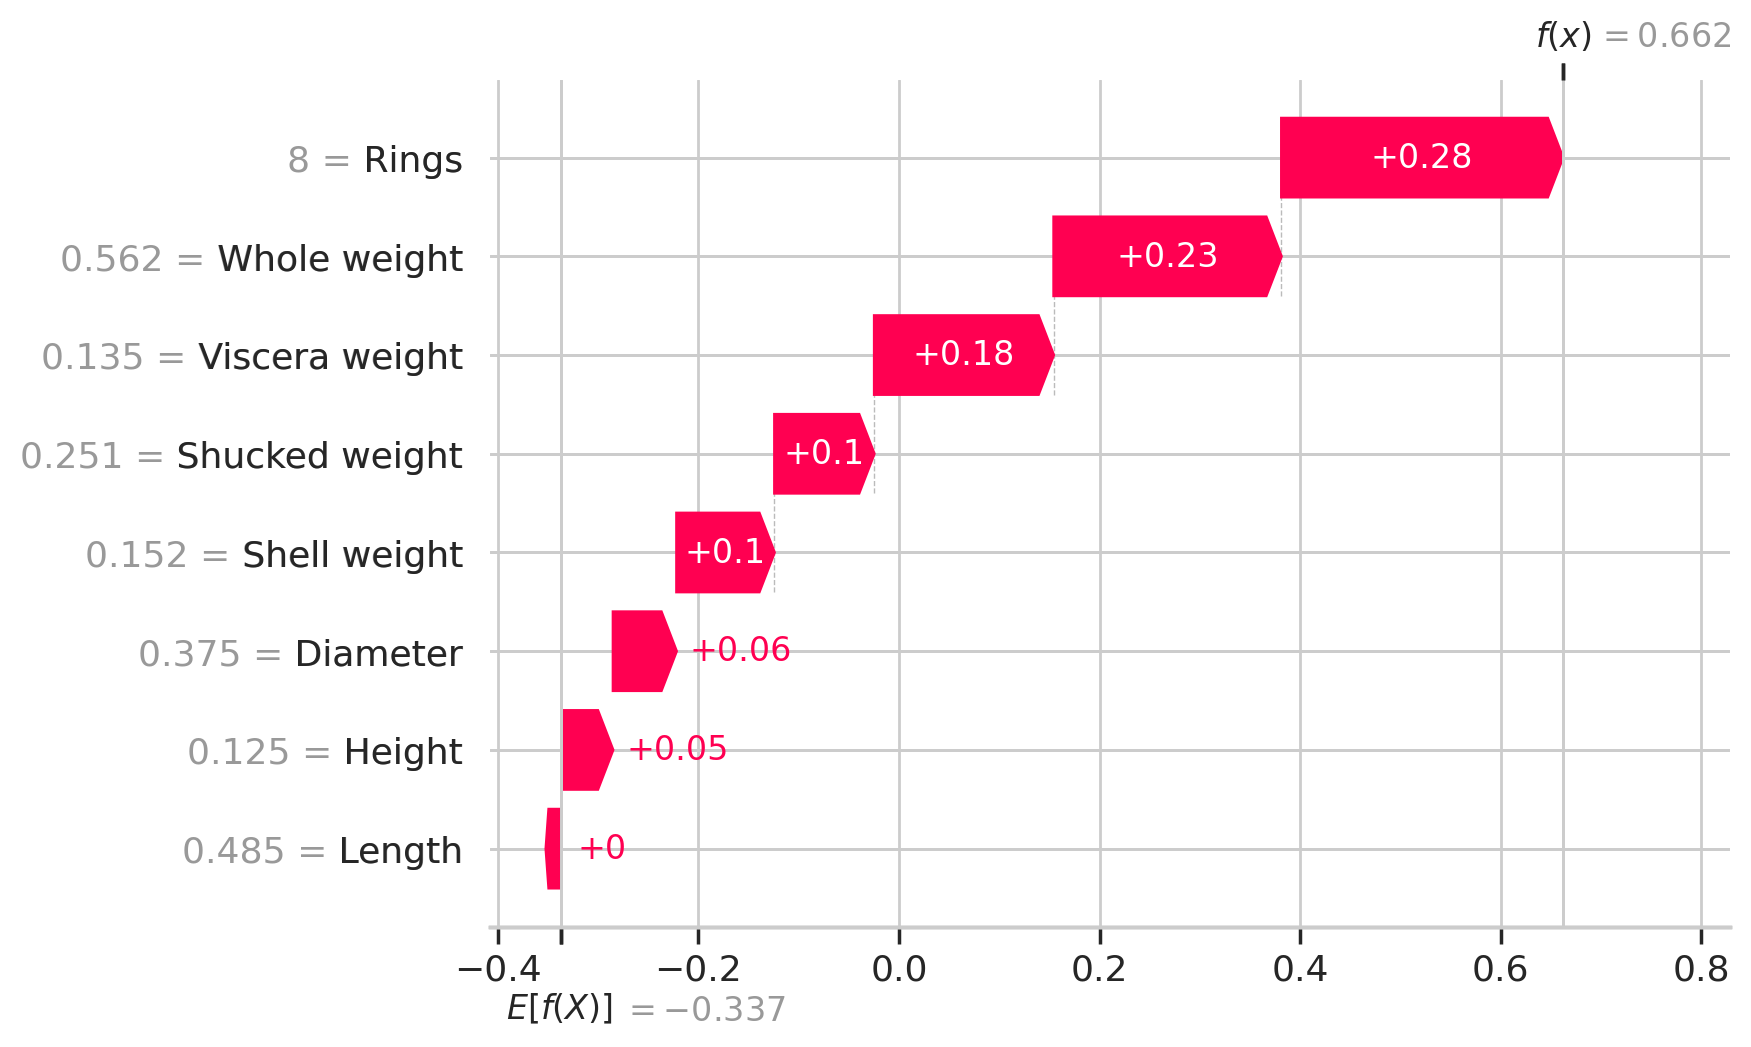

>>> Muestra 4: fila 179  |  clase real = M  |  probabilidad predicha de la clase analizada = 0.84


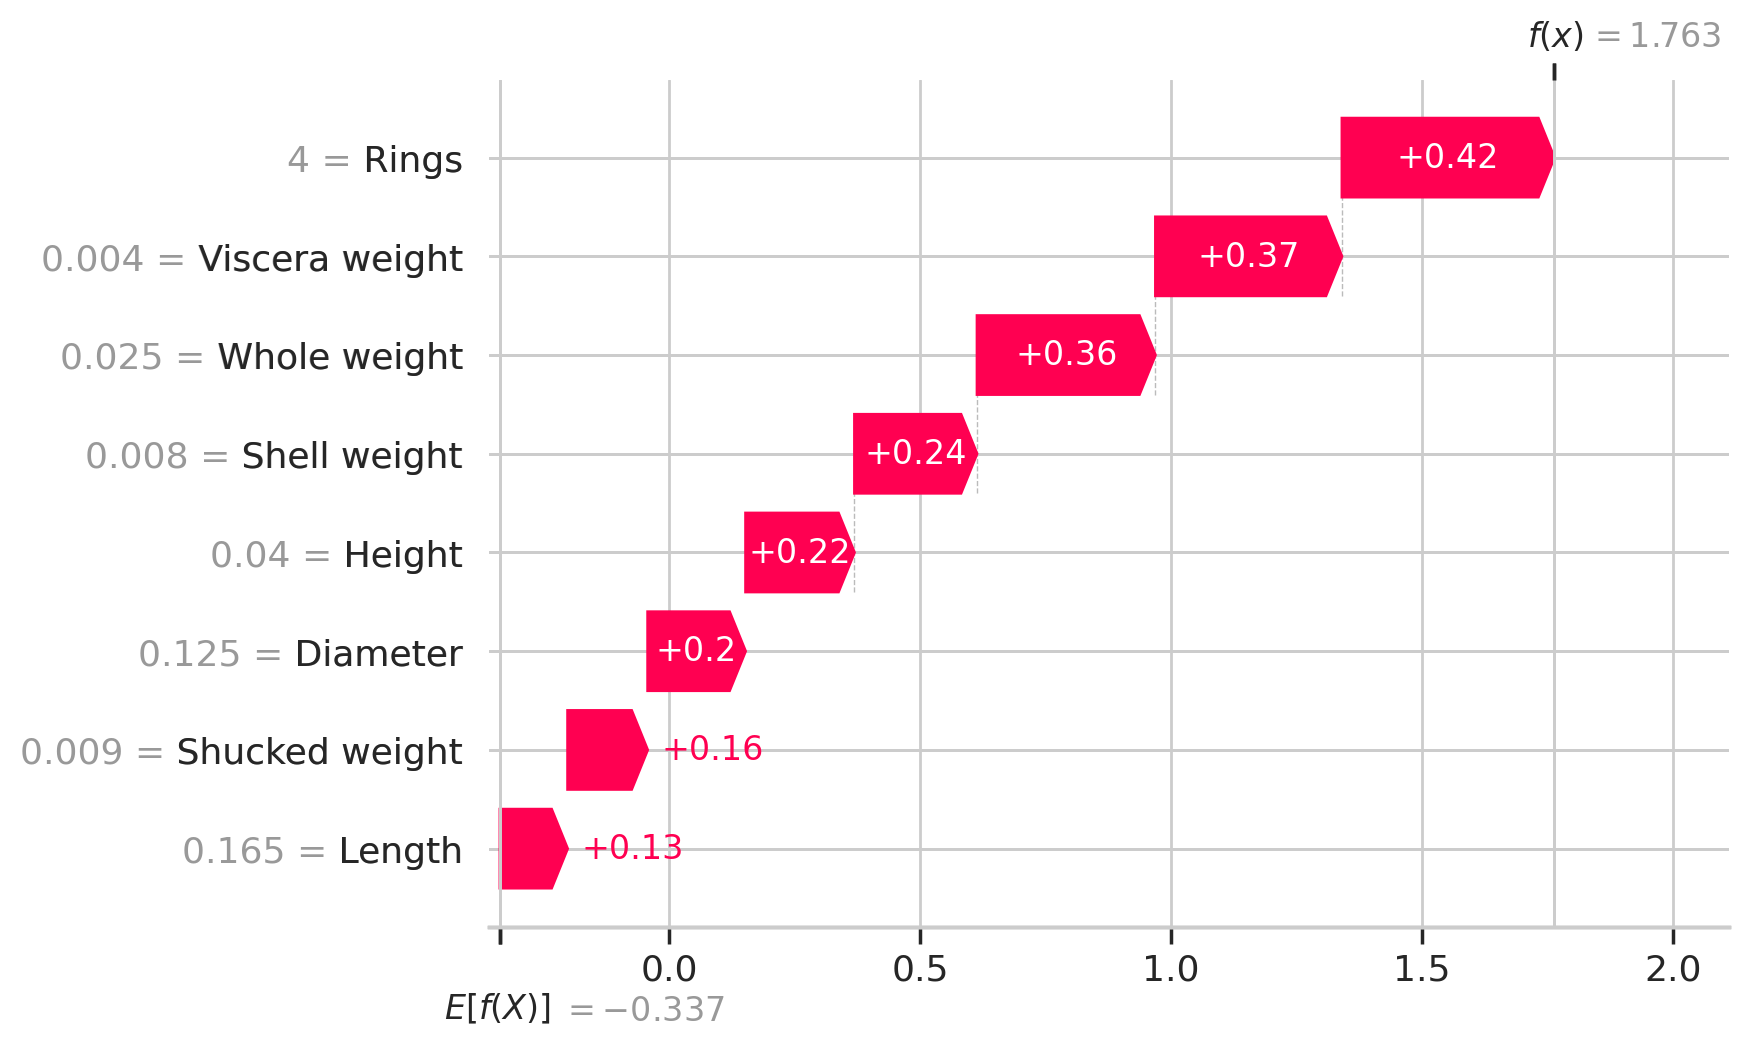

In [31]:
proba_I = h_a.predict_proba(Xs_a)[:, idx_I]
waterfalls_muestras(shap_a[:, :, idx_I], proba_I, ys_a, n=4)

Comparando los cuatro casos se ve que los ejemplares de pesos pequeños acumulan empujes hacia "infantil" (rojo) y los grandes en contra (azul); el modelo combina las variables de forma distinta en cada individuo.

#### Forma del efecto (*scatter*)

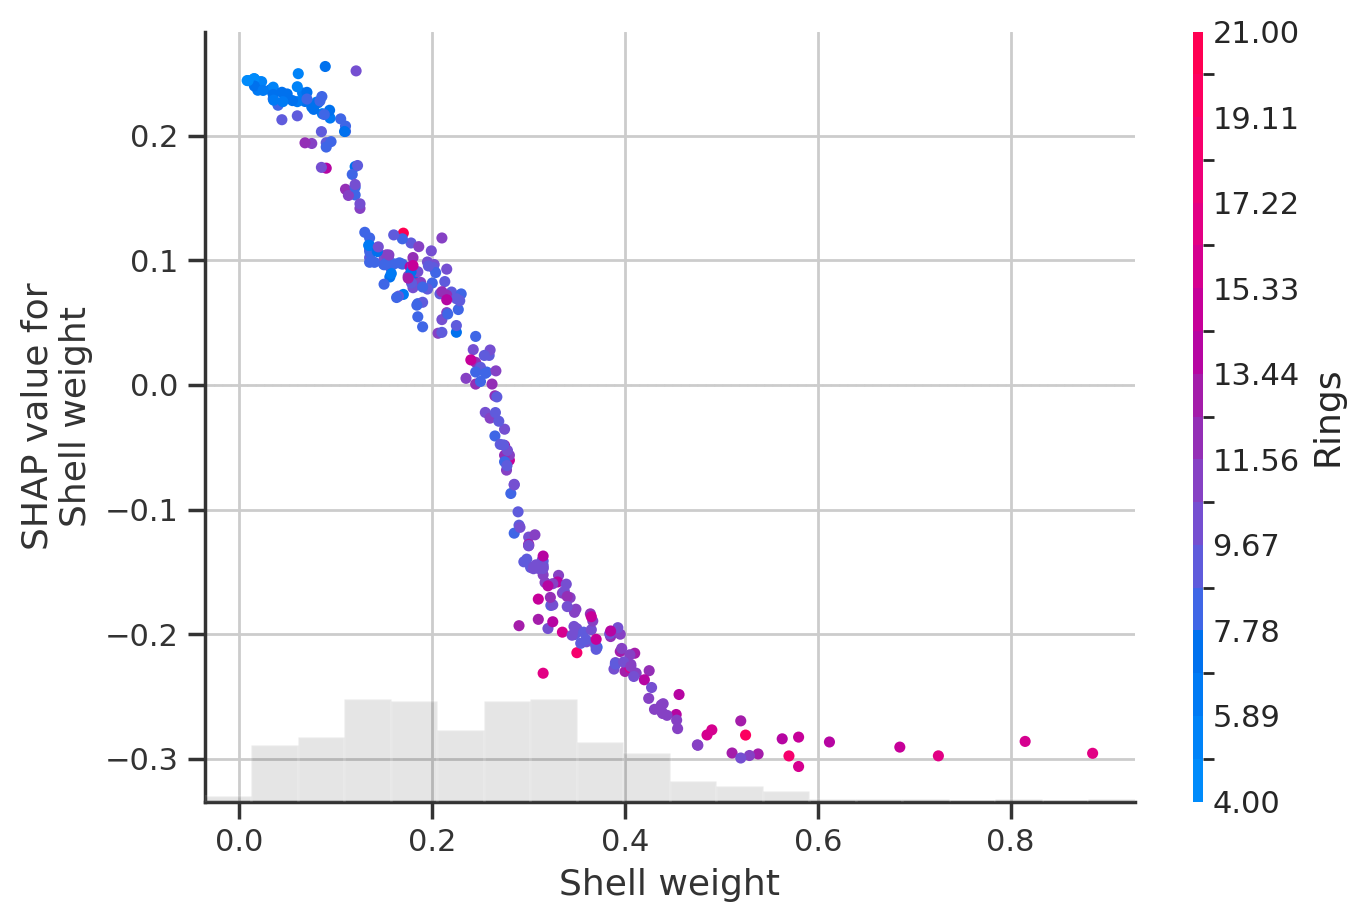

In [32]:
shap.plots.scatter(shap_a[:, :, idx_I][:, 'Shell weight'], color=shap_a[:, :, idx_I])

**Pesos pequeños** de `Shell weight` dan SHAP **positivo** (empujan a "infantil") y, al crecer el peso, el empuje **cae** y se vuelve negativo: efecto **decreciente**, coherente con que los adultos pesan más.

## <font color="steelblue">4.3. Potabilidad del agua (con análisis SHAP)</font>

Clasificamos el agua como **potable (1)** o **no potable (0)**. Cargamos `water_potability.csv` **sin limpiar**: contiene **valores ausentes**. Aunque HistGB/XGBoost/LightGBM podrían tratarlos de forma nativa, **imputamos la mediana** para que la comparación con AdaBoost y Gradient Boosting (que no admiten `NaN`) sea homogénea. Las clases están **desequilibradas** (≈61 % no potable): medimos con **F1 ponderada**.

In [33]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/water_potability.csv'
water = pd.read_csv(url)
print('Dimensiones:', water.shape, '| ausentes:', int(water.isna().sum().sum()))
water = water.fillna(water.median(numeric_only=True))      # imputación de la mediana
water['Potability'] = water['Potability'].astype('category')
tr, te = split_sample(water, 'Potability', 0.3, 0, True)
Xtr_w, ytr_w = tr.drop(columns='Potability'), tr['Potability']
Xte_w, yte_w = te.drop(columns='Potability'), te['Potability']

Dimensiones: (3276, 10) | ausentes: 1434
Estratificando por 'Potability'.
  Entrenamiento: 2293 muestras | Test: 983 muestras


### Comparación de los algoritmos de boosting

In [34]:
comparar_boosting(Xtr_w, ytr_w, Xte_w, yte_w)

,F1 train,F1 test,desfase (train-test)
AdaBoost,0.568,0.515,0.054
Gradient Boosting,0.716,0.599,0.117
HistGradientBoosting,0.975,0.616,0.359
XGBoost,0.999,0.619,0.380
LightGBM,0.975,0.619,0.356
CatBoost,0.899,0.633,0.266


De nuevo **F1 train** alto frente a **test ≈ 0.6**: **desfase grande** y **sobreajuste**. **CatBoost** y los basados en histogramas (HistGB, LightGBM) van por delante; elegimos **CatBoost** para el análisis detallado. Es un problema difícil.

### Optimización del modelo (`CatBoost`)

In [ ]:
h_w, params_w, cv_w = optimizar_catboost(Xtr_w, ytr_w)
print('Mejores hiperparámetros:', params_w)
print(f'F1 (validación cruzada) = {cv_w:.3f}')
print(f'F1 train = {f1_score(ytr_w, h_w.predict(Xtr_w), average="weighted"):.3f} | '
      f'F1 test = {f1_score(yte_w, h_w.predict(Xte_w), average="weighted"):.3f}')

Mejores hiperparámetros: {'depth': 6, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
F1 (validación cruzada) = 0.639
F1 train = 0.942 | F1 test = 0.628


La optimización **reduce el desfase** train-test, pero el test se queda en torno a **0.6**: como en abulones, el problema tiene una **dificultad intrínseca** (las propiedades químicas no separan bien la potabilidad).

### Evaluación del modelo óptimo

In [ ]:
reports_clas(h_w, Xtr_w, ytr_w, Xte_w, yte_w)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      1398
           1       0.99      0.86      0.92       895

    accuracy                           0.94      2293
   macro avg       0.95      0.93      0.94      2293
weighted avg       0.95      0.94      0.94      2293


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.67      0.81      0.74       600
           1       0.57      0.38      0.46       383

    accuracy                           0.64       983
   macro avg       0.62      0.60      0.60       983
weighted avg       0.63      0.64      0.63       983



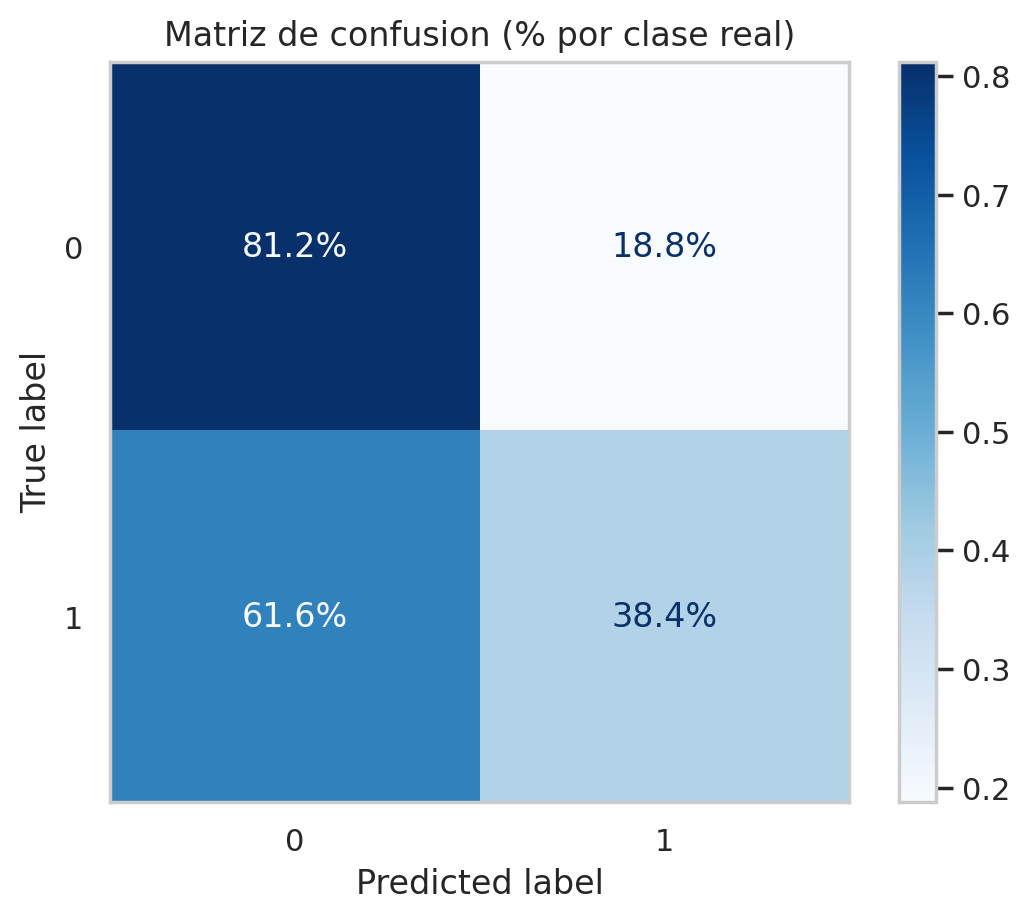

In [ ]:
matriz_confusion(h_w, Xte_w, yte_w);

In [ ]:
validar_modelo(h_w, Xtr_w, ytr_w, 'f1_weighted', 10);

Validacion cruzada (10 folds, score=f1_weighted): media = 0.6308 +/- 0.0247


El modelo acierta mejor la clase mayoritaria (no potable). La validación es estable en torno a 0.6.

### Equilibrado de clases

La clase **potable (1)** es **minoritaria** (~39 %) y el modelo base la **detecta poco** (su *recall* es bajo): se inclina hacia la clase mayoritaria. Comparamos las tres técnicas de equilibrado, aplicando el remuestreo **solo al entrenamiento** y midiendo con la **exactitud balanceada** y el **recall de la clase potable**.

In [ ]:
comparar_equilibrado(Xtr_w, ytr_w, Xte_w, yte_w, pos_label=1)

,exactitud,exactitud balanceada,F1 ponderada,recall clase 1
Sin equilibrar,0.631,0.587,0.616,0.389
class_weight=balanced,0.607,0.586,0.607,0.491
SMOTE (sobremuestreo),0.614,0.601,0.617,0.540
NearMiss (submuestreo),0.569,0.577,0.574,0.616


El modelo base apenas recupera ~39 % de las aguas potables (*recall* bajo). Las tres técnicas **aumentan el recall de la minoritaria**: la **ponderación** y **SMOTE** de forma moderada (SMOTE mejora además la exactitud balanceada manteniendo la F1), y **NearMiss** de forma más agresiva (el mayor *recall* de potable) a costa de **reducir la exactitud global y la F1**. Es el **compromiso** típico del equilibrado: se mejora la **detección de la clase minoritaria** sacrificando algo de acierto global. La elección depende de qué error sea más costoso (aquí, no detectar como potable un agua que sí lo es).

### Importancia de los predictores (permutación)

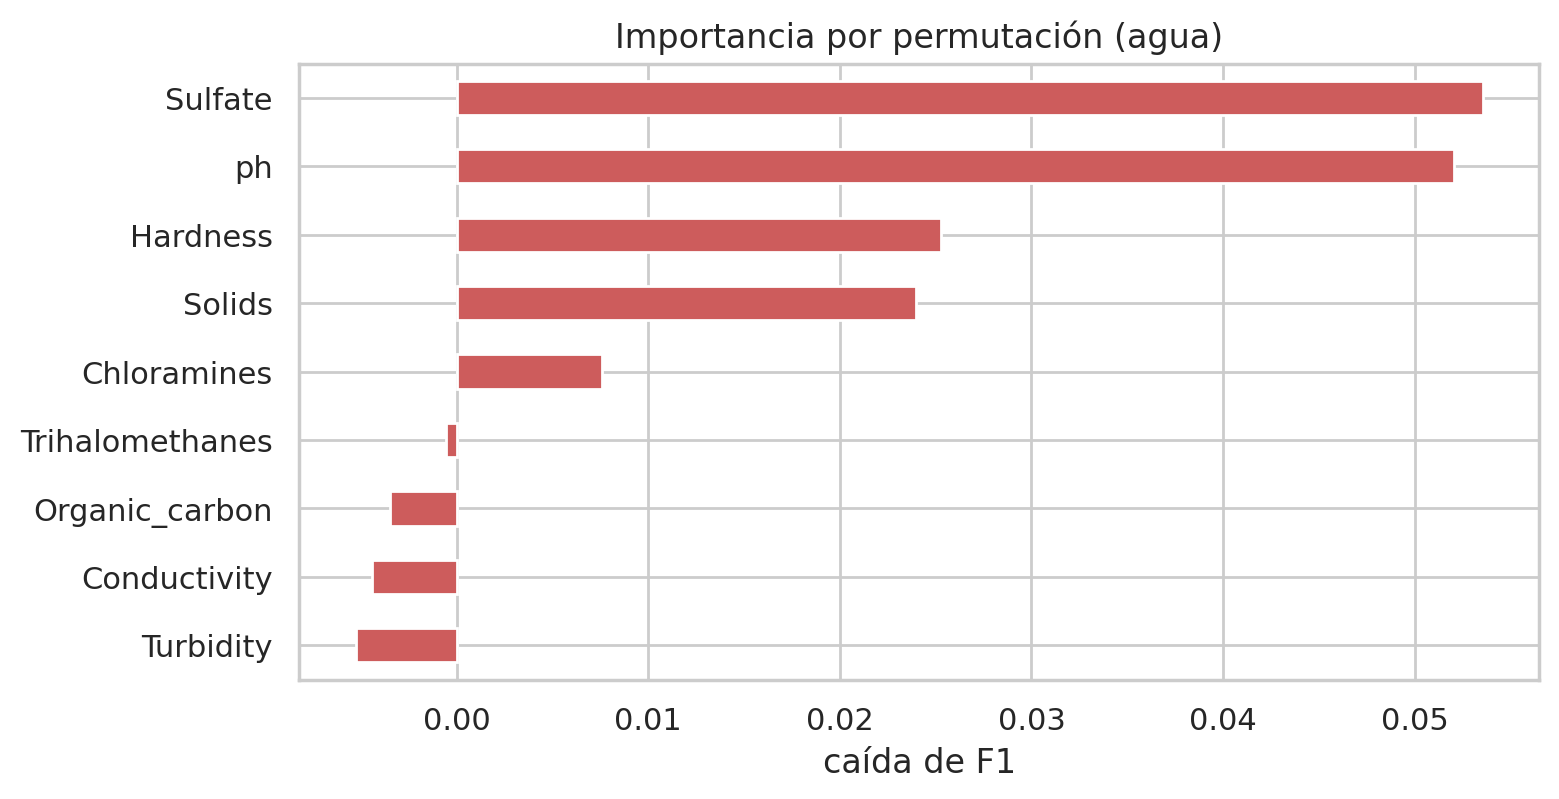

In [ ]:
perm_w = permutation_importance(h_w, Xte_w, yte_w, n_repeats=10, random_state=0, scoring='f1_weighted')
imp_w = pd.Series(perm_w.importances_mean, index=Xte_w.columns).sort_values(ascending=False)
imp_w.plot.barh(figsize=(8, 4), color='indianred'); plt.gca().invert_yaxis()
plt.title('Importancia por permutación (agua)'); plt.xlabel('caída de F1'); plt.show()

La importancia se reparte de forma **bastante homogénea** entre las variables químicas (con `Sulfate`, `ph` y `Hardness` algo por delante): **ninguna** propiedad determina por sí sola la potabilidad.

### Explicabilidad con SHAP

In [ ]:
Xs_w = Xte_w.reset_index(drop=True)
ys_w = yte_w.reset_index(drop=True)
shap_w = shap.TreeExplainer(h_w)(Xs_w)               # binario -> (n, variables), log-odds
print('Forma de los valores SHAP:', np.array(shap_w.values).shape,
      '| valor base (log-odds):', round(float(np.array(shap_w.base_values).ravel()[0]), 3))

Forma de los valores SHAP: (983, 9) | valor base (log-odds): -0.587


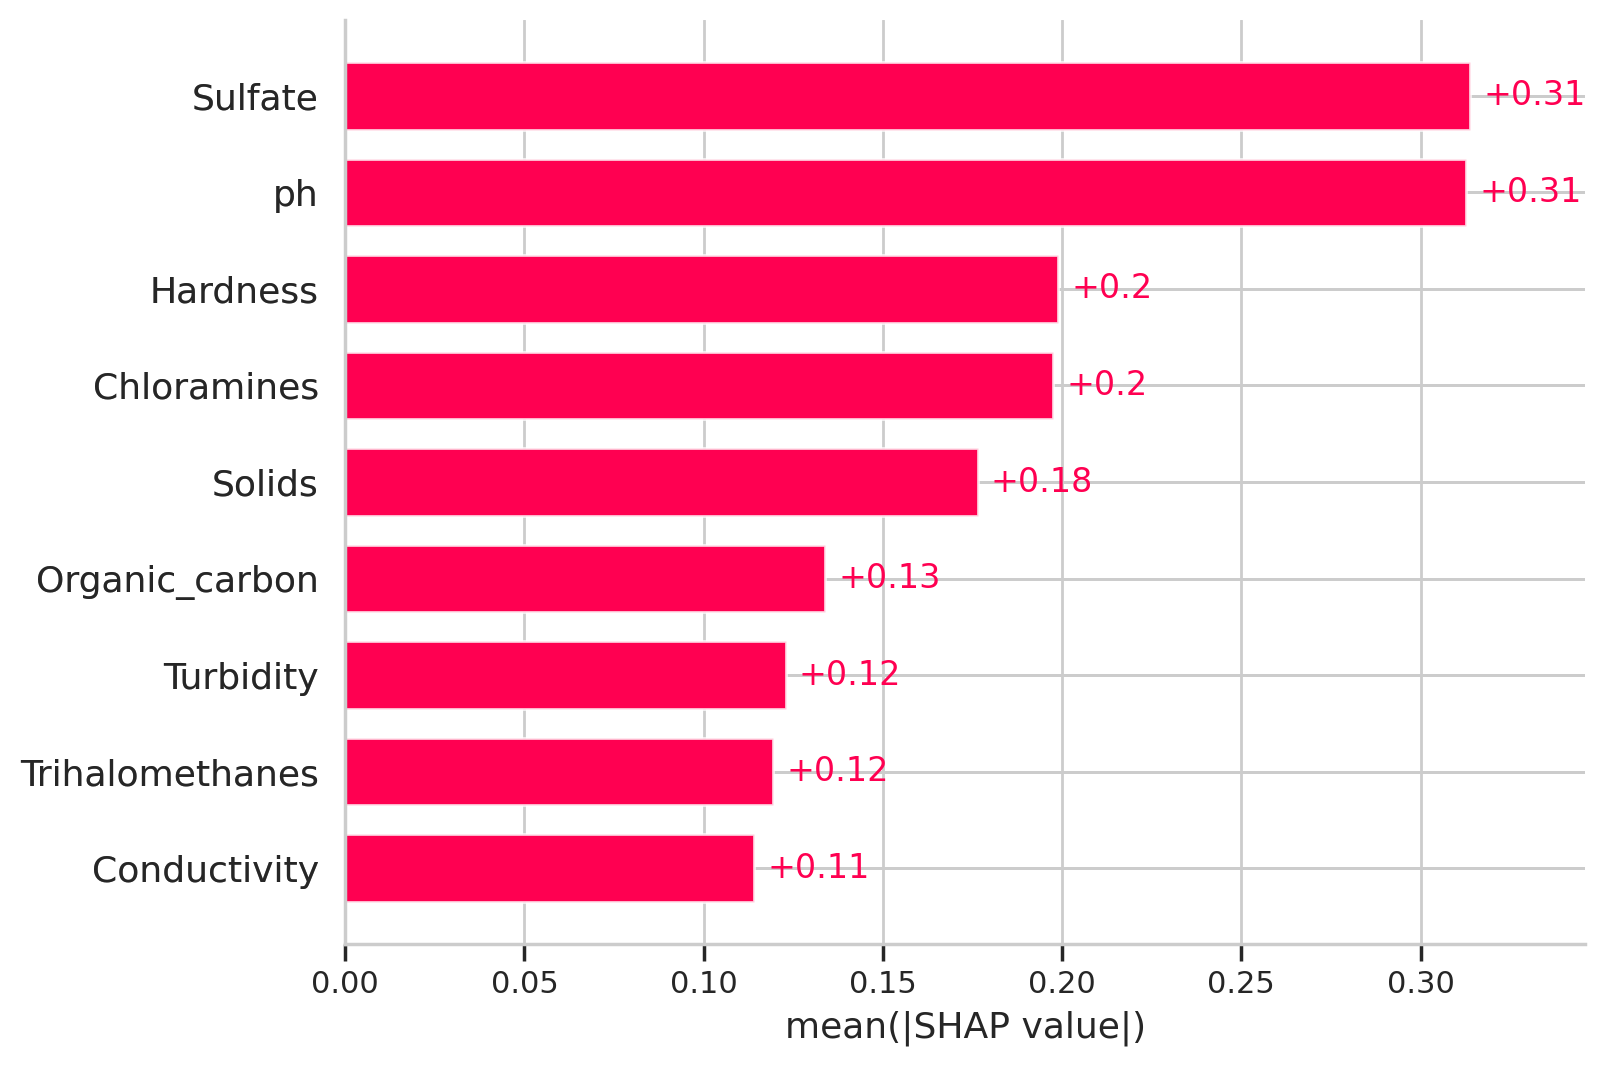

In [ ]:
shap.plots.bar(shap_w, max_display=9)

Confirma el reparto **homogéneo**: barras de longitudes parecidas, sin una variable claramente dominante.

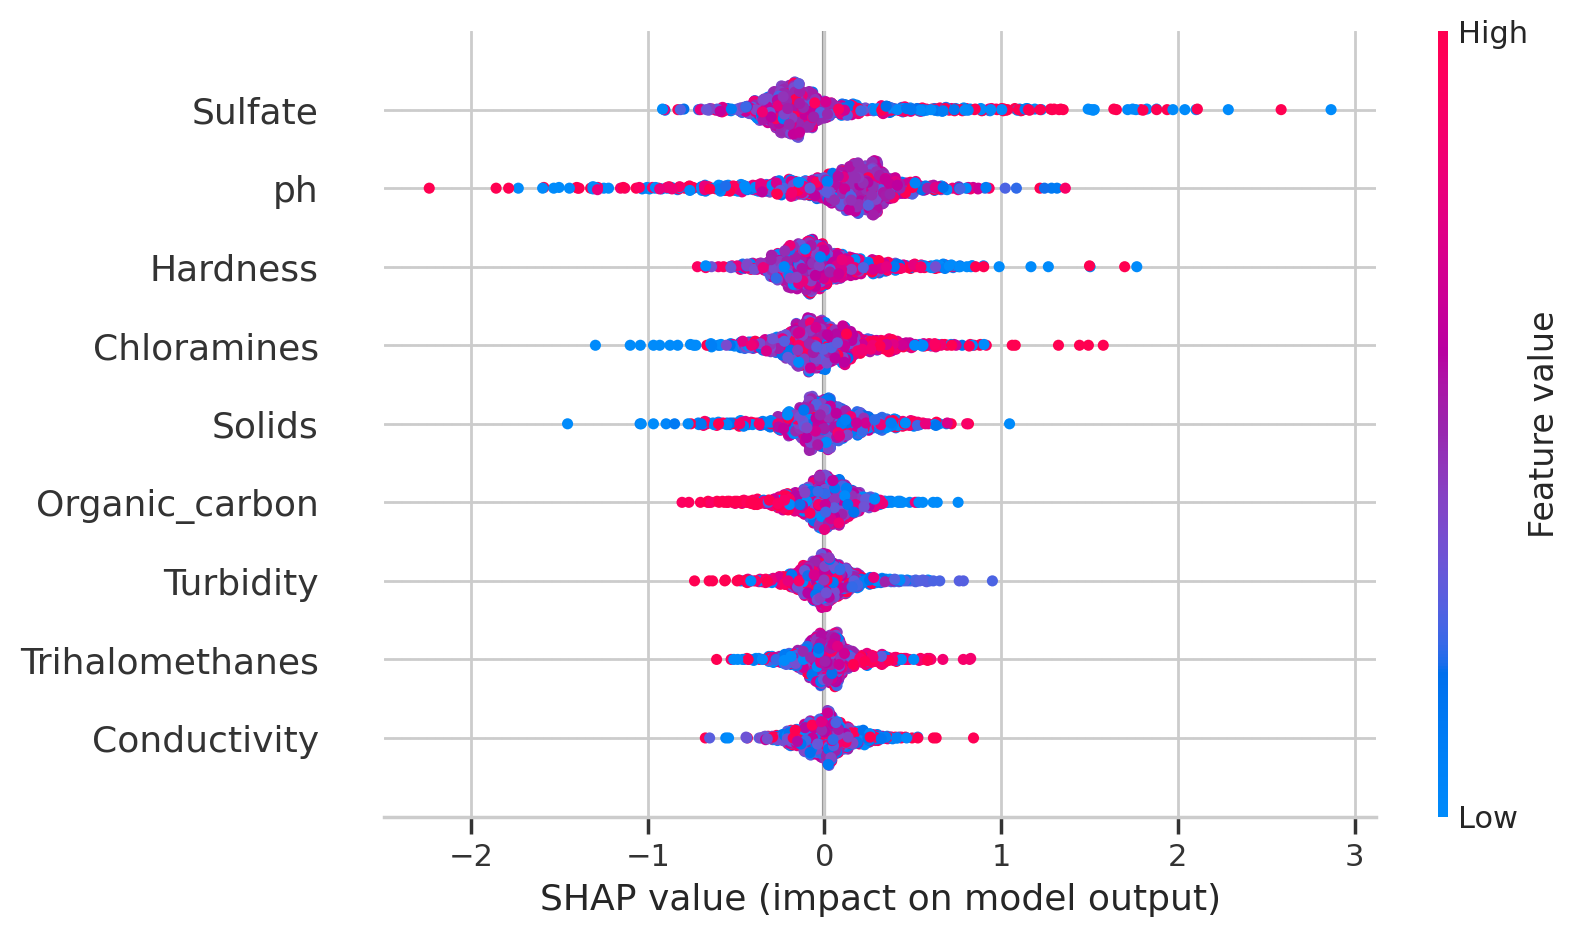

In [ ]:
shap.plots.beeswarm(shap_w, max_display=9)

Los empujes son **moderados** y los colores están **mezclados** (no se separan a un lado u otro): las variables **no discriminan** con claridad la potabilidad, lo que explica el bajo rendimiento.

#### Explicación local de 4 muestras (*waterfall*)

>>> Muestra 1: fila 815  |  clase real = 0  |  probabilidad predicha de la clase analizada = 0.01


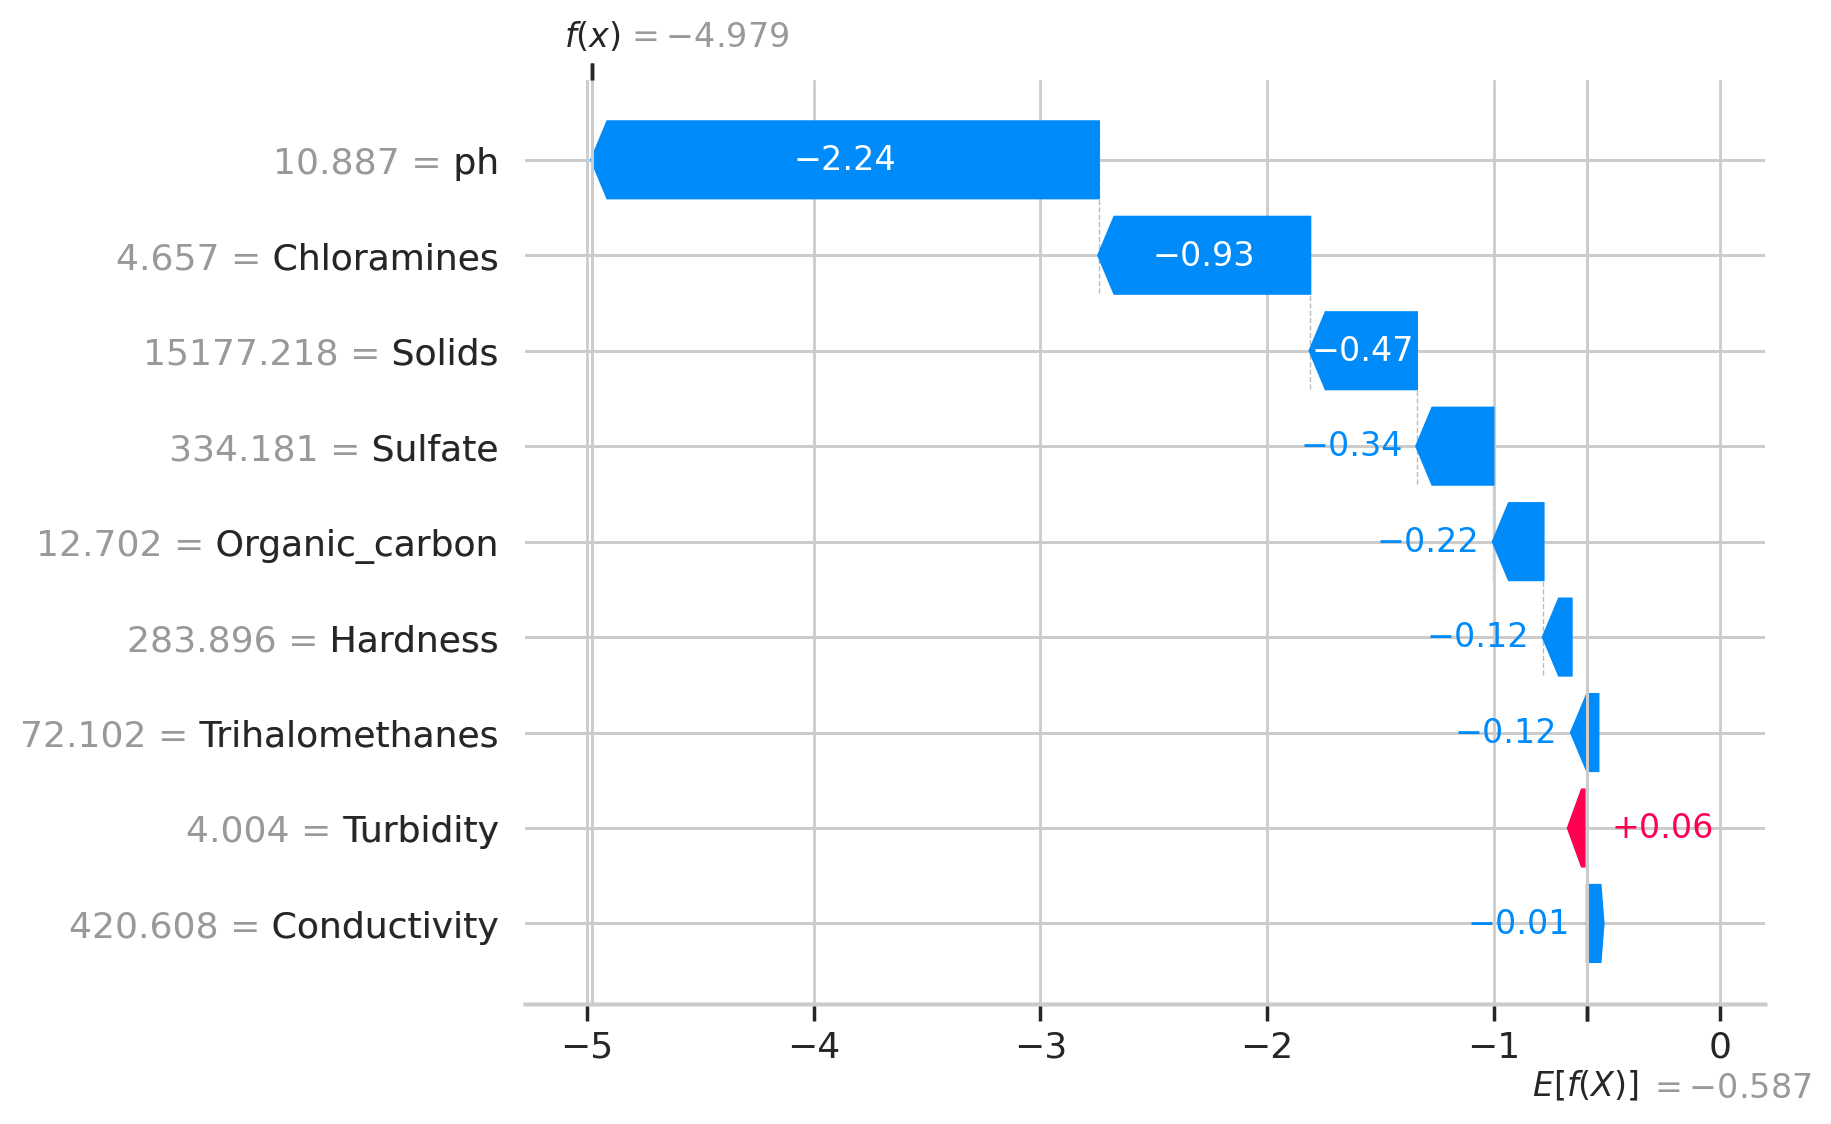

>>> Muestra 2: fila 506  |  clase real = 0  |  probabilidad predicha de la clase analizada = 0.34


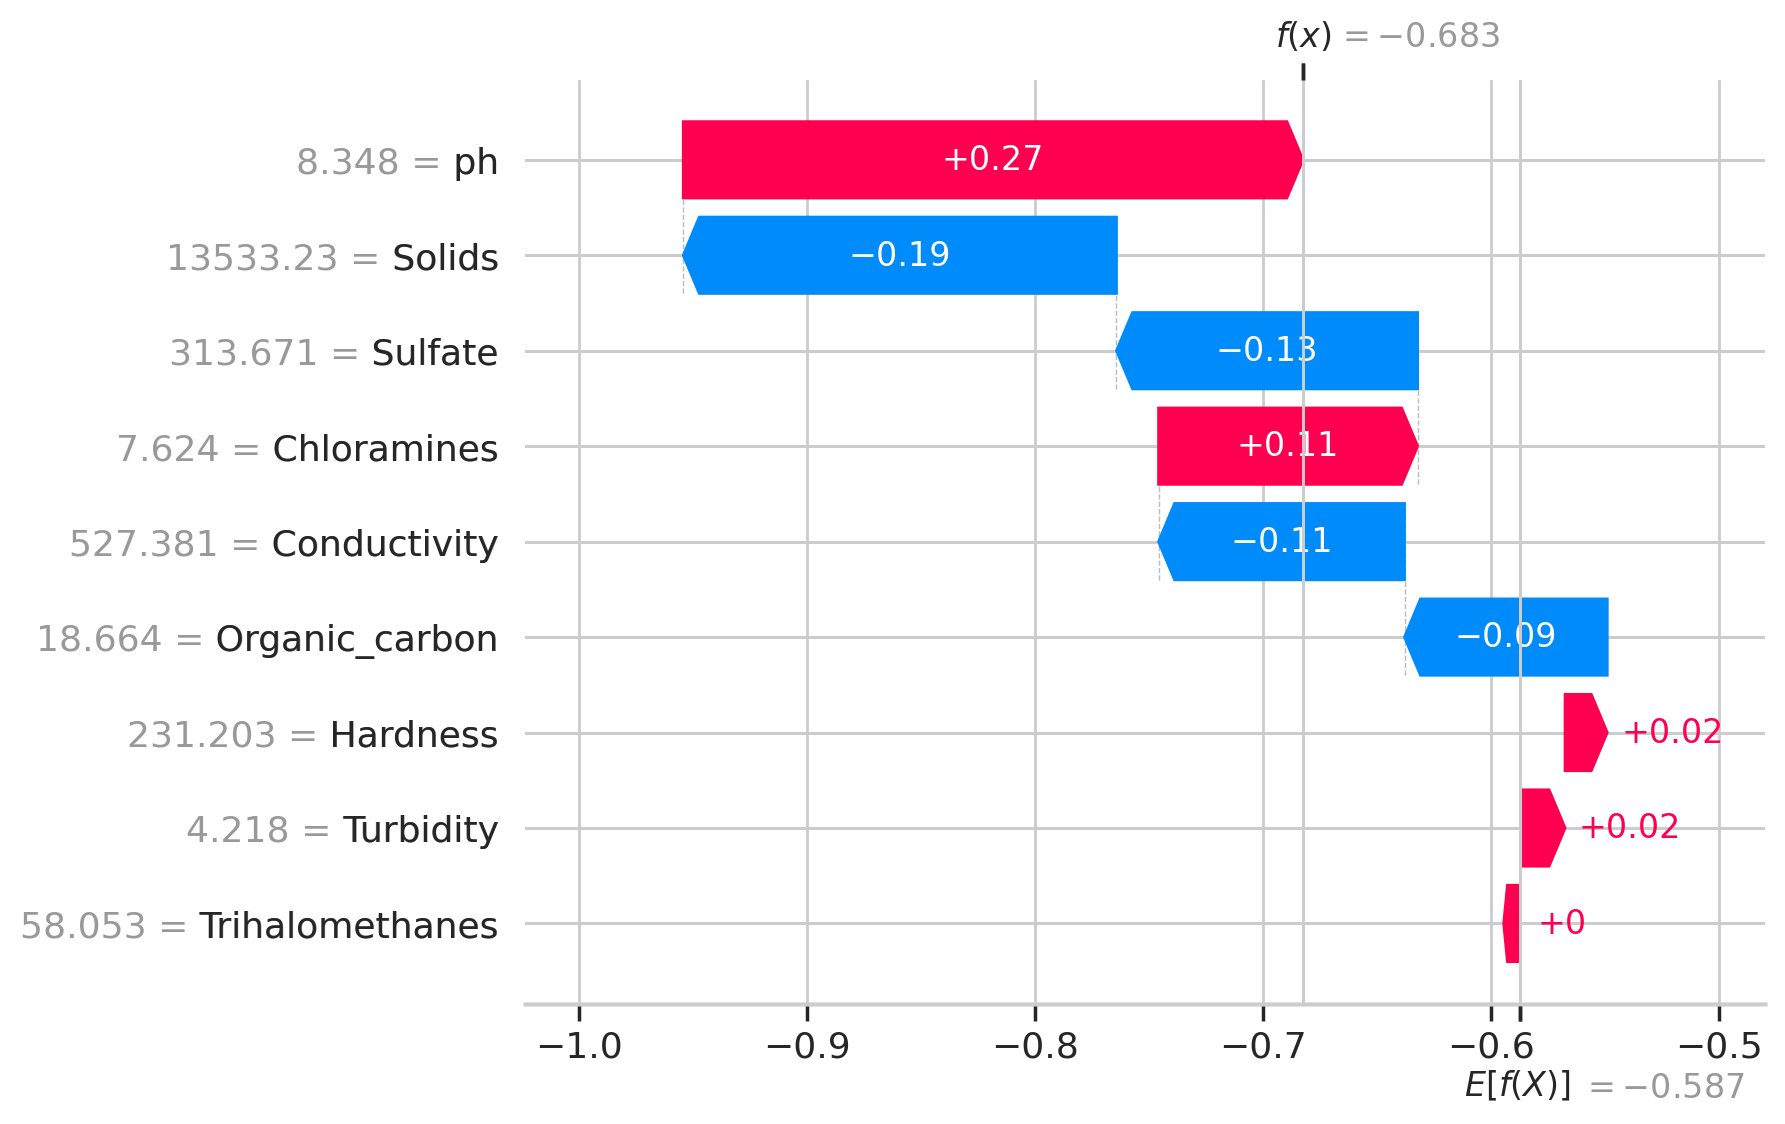

>>> Muestra 3: fila 413  |  clase real = 0  |  probabilidad predicha de la clase analizada = 0.66


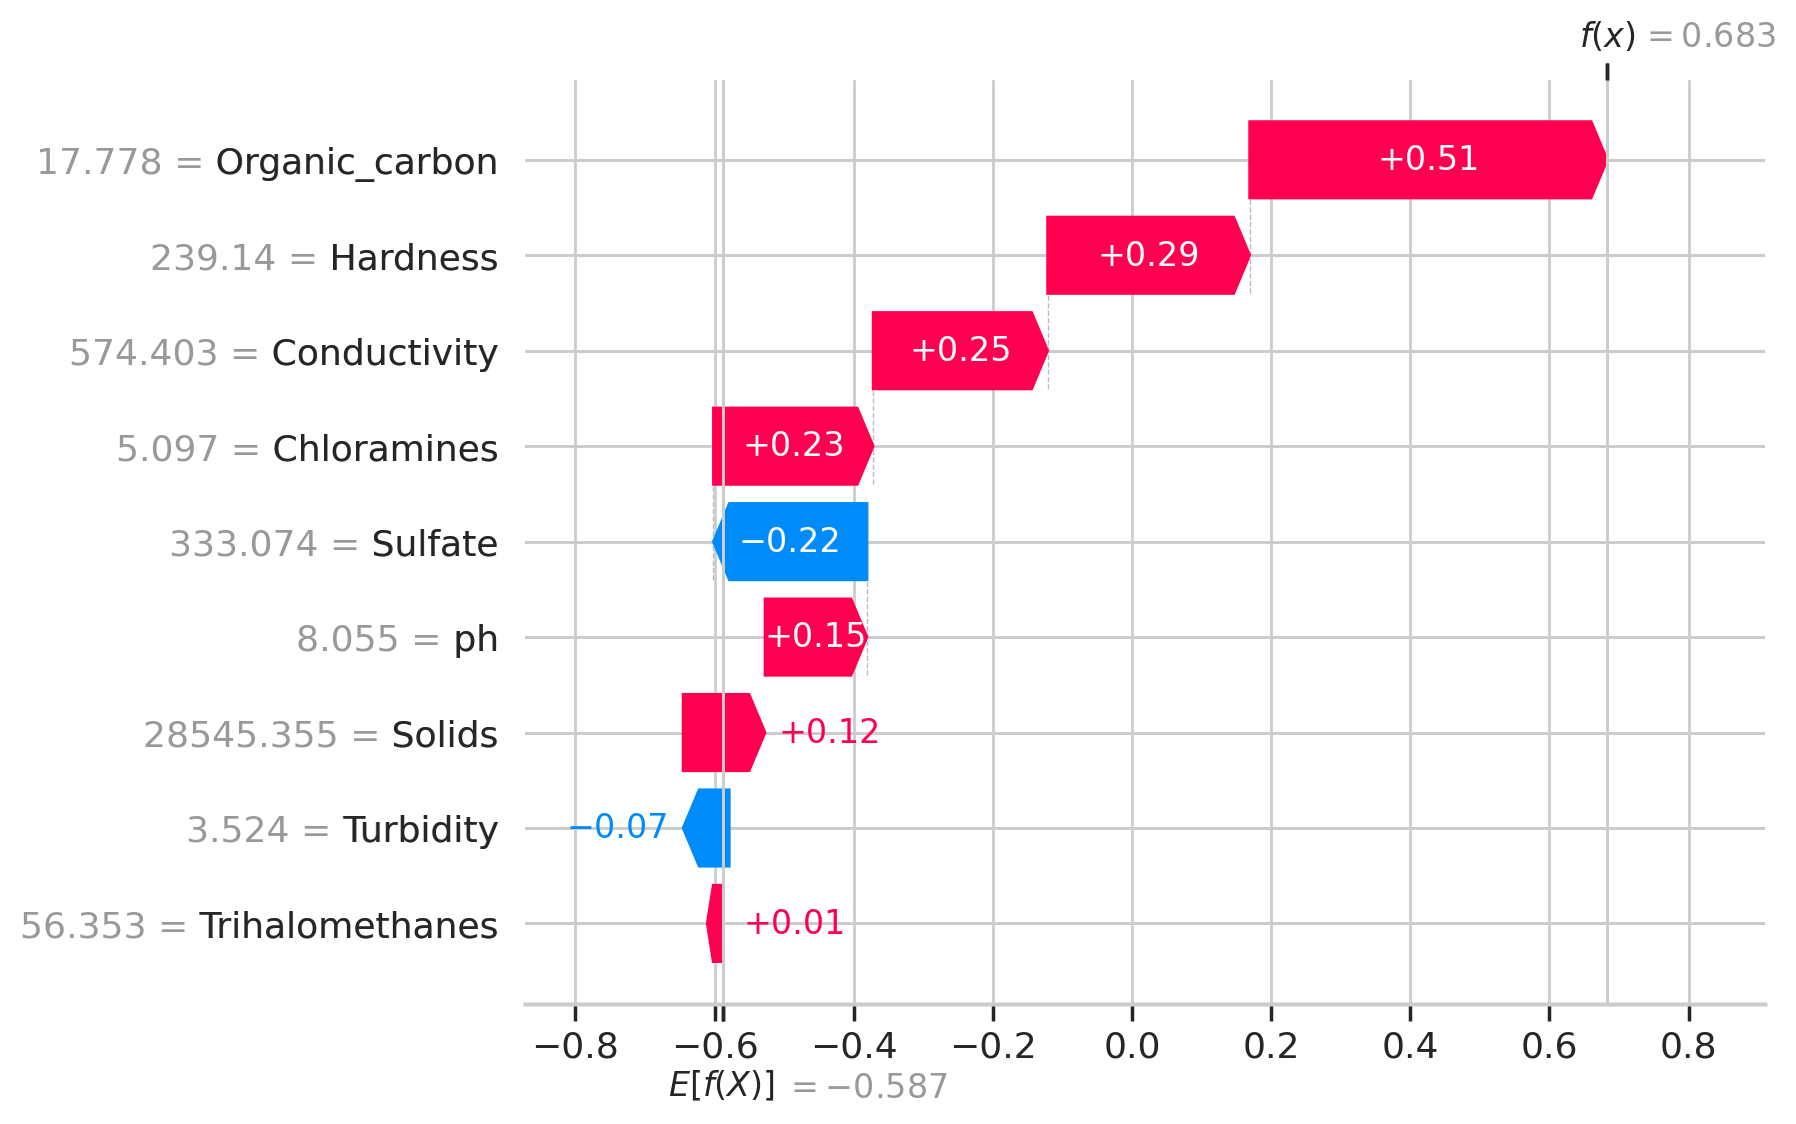

>>> Muestra 4: fila 257  |  clase real = 1  |  probabilidad predicha de la clase analizada = 0.99


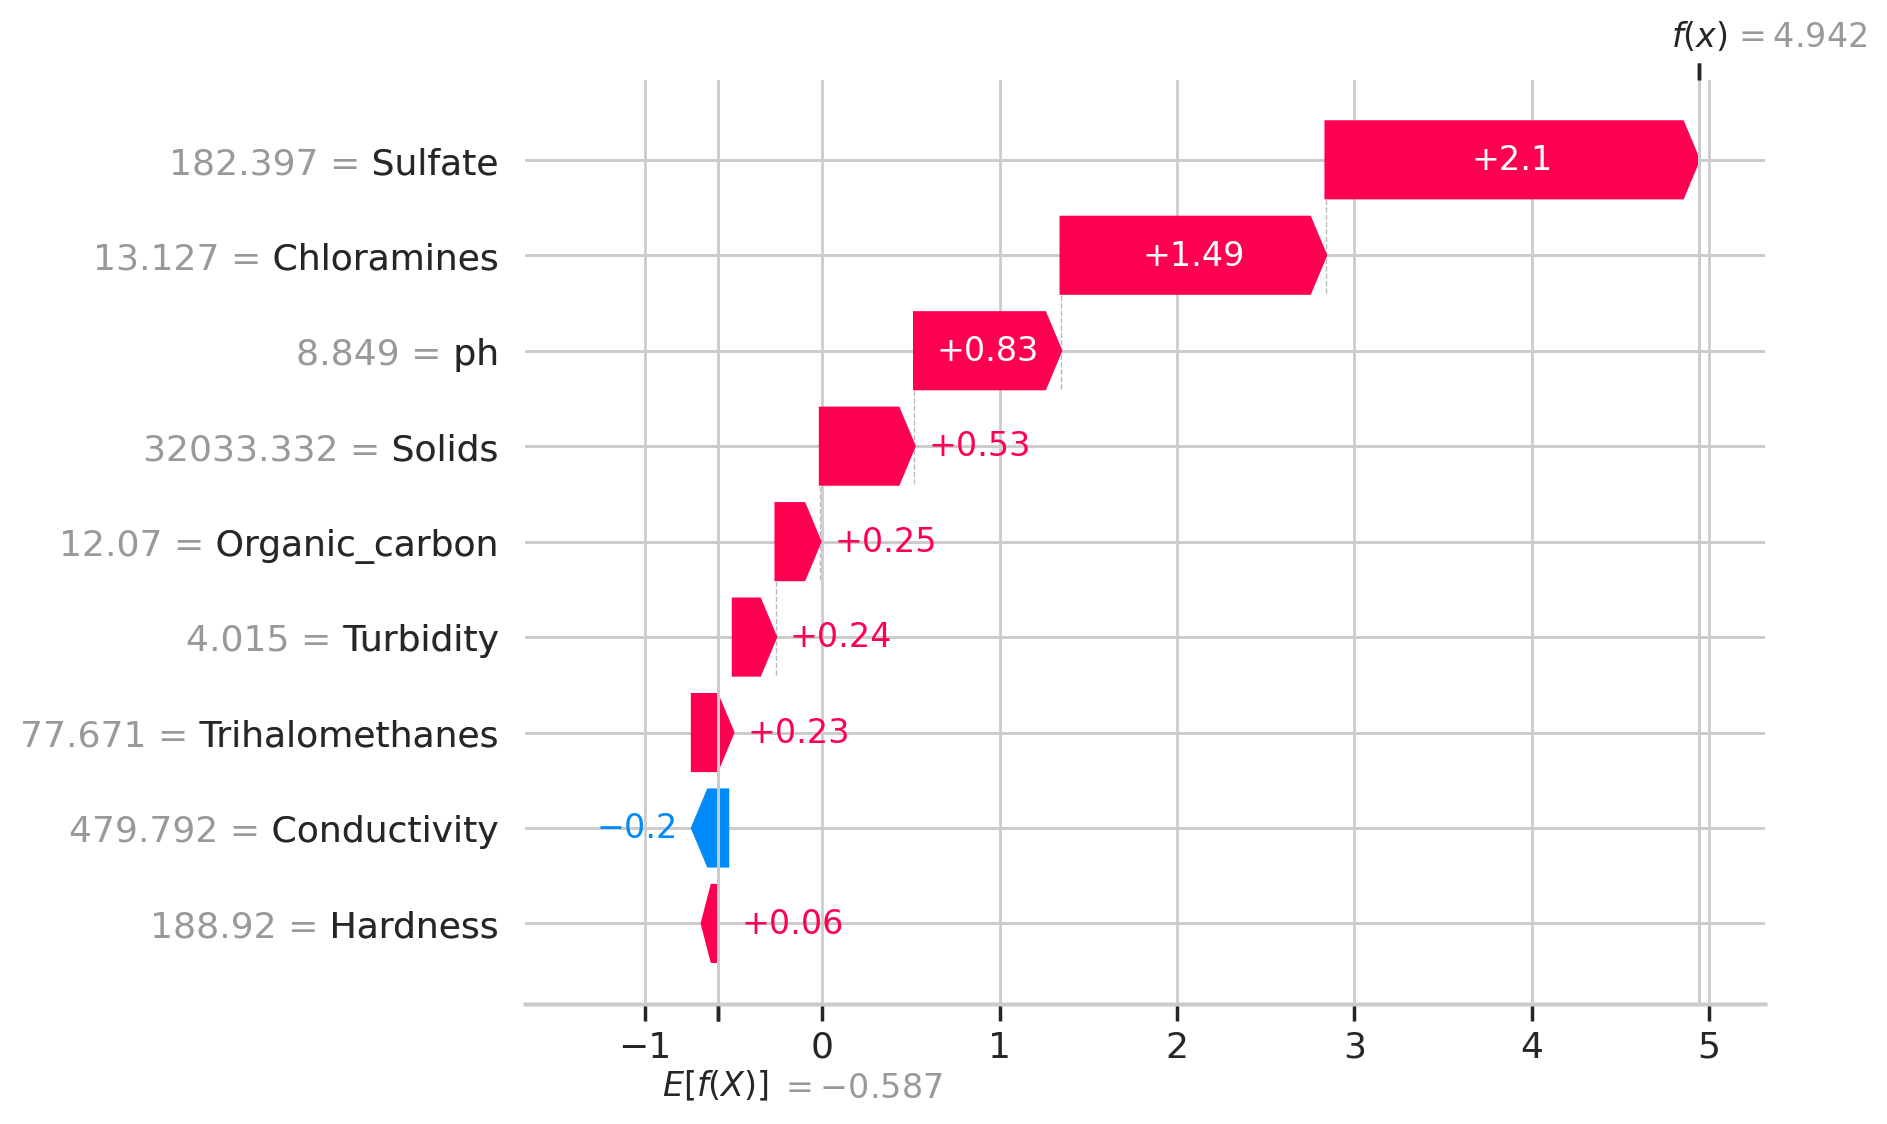

In [ ]:
proba_pot = h_w.predict_proba(Xs_w)[:, 1]
waterfalls_muestras(shap_w, proba_pot, ys_w, n=4)

Al ser un problema difícil, las explicaciones son **menos contundentes** que en cáncer: muchas variables aportan empujes pequeños en distintos sentidos, sin un factor decisivo.

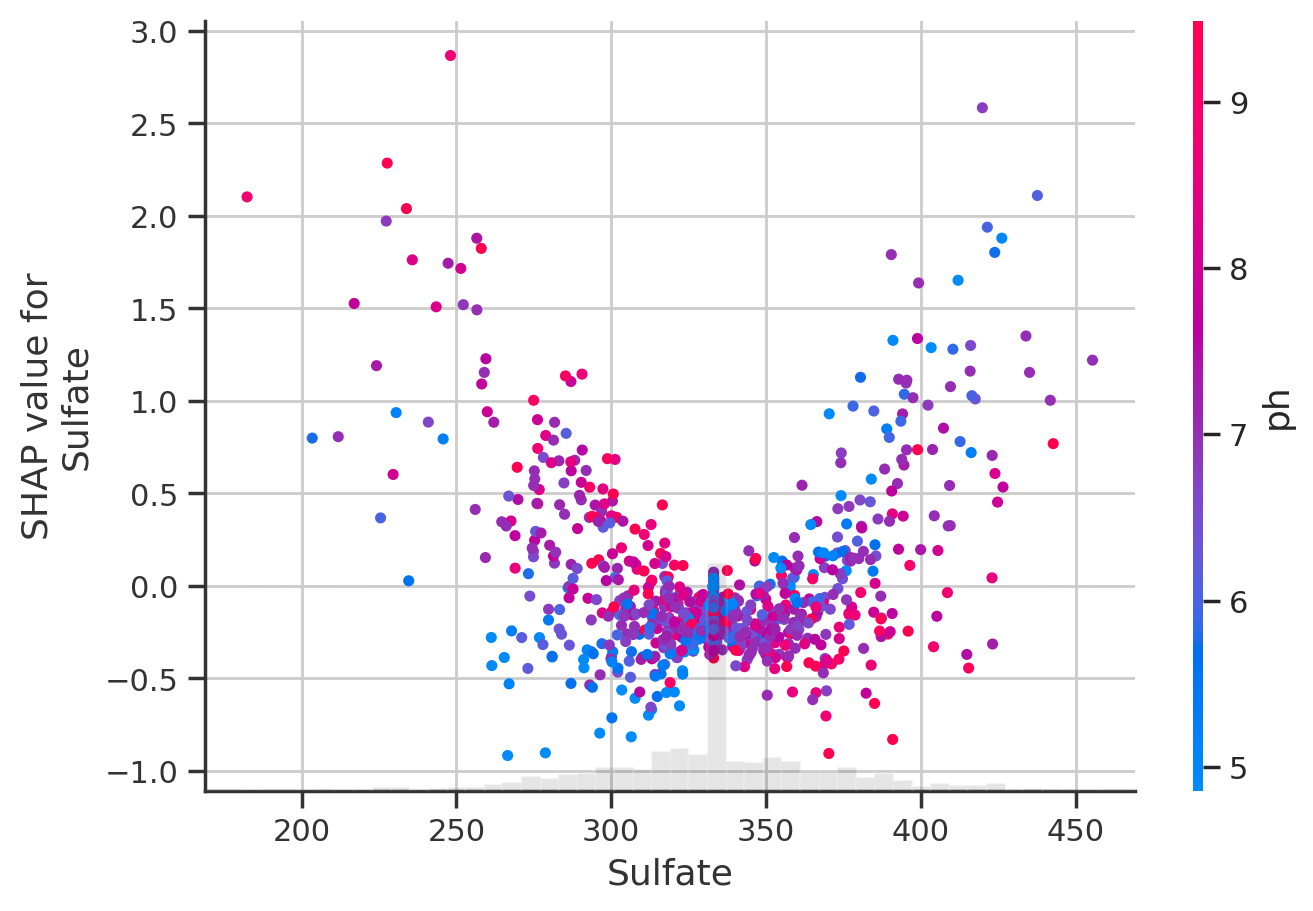

In [ ]:
shap.plots.scatter(shap_w[:, 'Sulfate'], color=shap_w)

La nube es **muy difusa** (gran dispersión vertical para cada valor de X): el efecto de `Sulfate` **depende fuertemente de otras variables** (interacciones) y no tiene una forma simple, otra señal de la complejidad del problema.



# <font color="steelblue">Referencias</font>

* Freund, Y. & Schapire, R. (1997). *A Decision-Theoretic Generalization of On-Line Learning* (AdaBoost). JCSS.
* Friedman, J. (2001). *Greedy Function Approximation: A Gradient Boosting Machine*. Annals of Statistics.
* Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD.
* Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. NeurIPS.
* Lundberg, S. & Lee, S. (2017). *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS.
* scikit-learn — *Ensembles*: https://scikit-learn.org/stable/modules/ensemble.html
* XGBoost: https://xgboost.readthedocs.io · LightGBM: https://lightgbm.readthedocs.io · SHAP: https://shap.readthedocs.io
